# Next-Year Financial Distress Early-Warning (Transition) & Surveillance (Compustat Annual Panel) — Reproducible ML Pipeline

**Goal.** Predict the probability that a firm is in *financial distress* in fiscal year **t+1** using accounting (and permitted market) information available at fiscal year **t**.

**Important scope note.** The outcome is an **engineered distress proxy** (high leverage / balance-sheet stress), not a realized legal default or bankruptcy. The notebook is therefore a **predictive measurement and decision-support pipeline**, not a causal identification design.

---

## Notebook structure (Data Science Lifecycle — 10 phases)

1. Problem Definition & Setup  
2. Data Collection & Panel Integrity  
3. Data Cleaning & Missingness Handling (leakage-aware)  
4. Exploratory Data Analysis (EDA)  
5. Feature Engineering & Target Construction  
6. Preprocessing for Modeling (train-only fitting)  
7. Model Selection & Training (7A Logit; 7B Trees)  
8. Model Evaluation & Diagnostic Monitoring  
9. Operational Risk Management Layer (Events + PDs)
10. Results Summary, Guardrails, and Replication Artifacts

> This organization mirrors the course lifecycle guidance and the project's technical review action items (see provided PDF and technical report).

## How to run (replication package convention)

1. Place `data.csv` in the project root (or update `CONFIG["DATA_PATH"]` in Section 1).
2. Keep `Variables.xlsx` (variable dictionary) alongside the notebook for automatic documentation.
3. Run **Kernel → Restart & Run All**.

The notebook creates an `outputs/` folder containing:
- a predictions export (`predictions.csv`),
- configuration and threshold tables,
- model summary tables suitable for an appendix,
- figures saved as PNG for paper workflow.

## 1. Problem Definition & Setup

### 1.1 Prediction target, success metrics, and decision objective

- **Target (supervised label):** `target_next_v1`, `target_next_v2`, or `target_next_v3` (separate distress proxies). Downstream modeling uses `target_next_v2` by default.  
- **Primary performance metrics (out-of-sample):**
  - ROC-AUC (ranking quality),
  - PR-AUC (class imbalance),
  - Brier score (probability accuracy / calibration).
- **Decision objective (screening):** convert predicted PDs into a review policy using:
  - **misclassification costs** (`COST_FN`, `COST_FP`) and
  - **capacity constraints** (screen top `CAPACITY_PCT` percent of firms).

This is a *risk scoring* workflow: calibrated probabilities and operational interpretability matter more than headline accuracy.

### 1.2 Configuration, determinism, and library versions

**Objective options:**
- **Transition (early-warning):** predict *healthy at t → distressed at t+1*.
- **State (surveillance):** predict *distress state at t+1* (includes persistence).

The notebook preserves proxy selection (V1/V2/V3); set `PROXY_VERSION` and `OBJECTIVE` in Section 4 (Targets).


In [1]:
# Core numerics
import os
import sys
import math
import json
import inspect
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd

# ML / metrics
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

# Stats / inference
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.sandwich_covariance import cov_cluster, cov_cluster_2groups
from scipy import stats

# Trees / explainability
import xgboost as xgb

from skopt import gp_minimize
from skopt.space import Integer, Real, Categorical

# XGBoost API compatibility (feval -> custom_metric in v2+)
XGB_TRAIN_METRIC_KW = (
    "custom_metric" if "custom_metric" in inspect.signature(xgb.train).parameters else "feval"
)

import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.impute import KNNImputer
# pyampute (audit missingness generation)
try:
    from pyampute.ampute import MultivariateAmputation
except Exception as e:
    raise ImportError(
        "pyampute is required for the KNN audit. Install via: pip install pyampute\n"
        f"Import error: {e}"
    )
warnings.filterwarnings("ignore")

# ----------------------------
# Determinism
# ----------------------------
SEED = 42
np.random.seed(SEED)
USING_SYNTHETIC_DATA = False # Global flag for data mode

# ----------------------------
# Configuration (edit here)
# ----------------------------
CONFIG = {
    # Data inputs
    "DATA_PATH": "data.csv",
    "VARIABLES_XLSX_PATH": "Variables.xlsx",

    # Temporal splitting via label_year = fyear + 1
    "TRAIN_CUTOFF_LABEL_YEAR": 2022,   # label_year <= cutoff -> train/val pool; later -> test
    "VAL_YEARS": 1,                    # number of last label years inside the train pool used as validation

    # Missingness / imputation
    "KNN_K": 5,
    "IMPUTE_LO_Q": 0.01,
    "IMPUTE_HI_Q": 0.99,

    # Preprocessing
    "WINSOR_LO_Q": 0.01,
    "WINSOR_HI_Q": 0.99,

    # Logit hyperparameter search
    "LOGIT_C_GRID": [0.001, 0.005, 0.0075, 0.015],

    # Tree model (XGBoost) parameters — base settings; tuned below via policy-aligned search
    "XGB_PARAMS": {
        "objective": "binary:logistic",
        "tree_method": "hist",
        "seed": SEED,
    },
    "XGB_N_TRIALS": 100,
    "XGB_NUM_BOOST_ROUND": 30000,
    "XGB_EARLY_STOPPING": 200,

    # Decision policy parameters (costs + capacity)
    "COST_FN": 3.0,
    "COST_FP": 1.0,
    "CAPACITY_PCT": 0.20,  # screen top 20% by PD as a capacity policy

    # Outputs
    "OUTPUT_DIR": "outputs",
    "FIG_DIR": "figures",
}

Path(CONFIG["OUTPUT_DIR"]).mkdir(parents=True, exist_ok=True)
Path(CONFIG["FIG_DIR"]).mkdir(parents=True, exist_ok=True)

print("CONFIG (key parameters):")
for k in ["DATA_PATH","TRAIN_CUTOFF_LABEL_YEAR","VAL_YEARS","KNN_K","WINSOR_LO_Q","WINSOR_HI_Q","COST_FN","COST_FP","CAPACITY_PCT"]:
    print(f"  {k}: {CONFIG[k]}")
print("\nPython:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

CONFIG (key parameters):
  DATA_PATH: data.csv
  TRAIN_CUTOFF_LABEL_YEAR: 2022
  VAL_YEARS: 1
  KNN_K: 5
  WINSOR_LO_Q: 0.01
  WINSOR_HI_Q: 0.99
  COST_FN: 3.0
  COST_FP: 1.0
  CAPACITY_PCT: 0.2

Python: 3.13.5
pandas: 2.3.1
numpy: 2.2.5


### 1.3 Helper utilities (robust ratios, transforms, and reporting)

In [2]:
def signed_log1p(x: pd.Series) -> pd.Series:
    """Signed log1p transform: sign(x) * log1p(|x|). Preserves zero and sign, stabilizes tails."""
    x = pd.to_numeric(x, errors="coerce")
    return np.sign(x) * np.log1p(np.abs(x))

def safe_divide(numer: pd.Series, denom: pd.Series, denom_floor: float = None) -> pd.Series:
    """Safe divide with optional denominator floor for stability. Returns float with NaN where undefined."""
    numer = pd.to_numeric(numer, errors="coerce")
    denom = pd.to_numeric(denom, errors="coerce")
    if denom_floor is not None:
        denom = denom.where(denom.abs() >= denom_floor, other=np.sign(denom).replace(0, 1) * denom_floor)
    out = numer / denom
    out = out.replace([np.inf, -np.inf], np.nan)
    return out

def ensure_nullable_float(s: pd.Series) -> pd.Series:
    """Convert to pandas nullable Float64 to enable NA-aware comparisons (returns <NA> instead of False)."""
    return pd.to_numeric(s, errors="coerce").astype("Float64")

def winsorize_train_bounds(x: pd.Series, lo: float, hi: float) -> tuple[float, float]:
    """Return winsorization bounds computed on *training* observed values."""
    x = pd.to_numeric(x, errors="coerce")
    x_obs = x.dropna()
    if len(x_obs) == 0:
        return (np.nan, np.nan)
    return (float(x_obs.quantile(lo)), float(x_obs.quantile(hi)))

def apply_bounds(x: pd.Series, lo: float, hi: float) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce")
    if np.isnan(lo) or np.isnan(hi):
        return x
    return x.clip(lower=lo, upper=hi)

def compute_smd(train: pd.Series, test: pd.Series) -> float:
    """Standardized mean difference (SMD): (mu_train - mu_test)/pooled_sd."""
    a = pd.to_numeric(train, errors="coerce").dropna()
    b = pd.to_numeric(test, errors="coerce").dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    mu_a, mu_b = a.mean(), b.mean()
    sd_a, sd_b = a.std(ddof=1), b.std(ddof=1)
    pooled = np.sqrt(0.5*(sd_a**2 + sd_b**2))
    return float((mu_a - mu_b) / pooled) if pooled > 0 else np.nan

def logit(p: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))

def sigmoid(z: np.ndarray) -> np.ndarray:
    return 1/(1+np.exp(-z))

def print_df(df: pd.DataFrame, n: int = 10, name: str = None):
    if name:
        print(f"\n{name} (top {n} rows):")
    display(df.head(n))

## 2. Data Collection & Panel Integrity

### 2.1 Load variable dictionary (for documentation)

We load the provided variable dictionary (`Variables.xlsx`) to:
- validate required Compustat mnemonics exist in the data file,
- generate appendix-ready variable tables.

This step **does not** transform the modeling data.

In [3]:
vars_path = Path(CONFIG["VARIABLES_XLSX_PATH"])
if vars_path.exists():
    var_dict = pd.read_excel(vars_path, sheet_name=0)
    var_dict.columns = [c.strip() for c in var_dict.columns]
    print(f"Loaded variable dictionary with {len(var_dict)} rows from: {vars_path}")
    display(var_dict.head(90))
else:
    var_dict = pd.DataFrame(columns=["Variable","Two-word Description","Category"])
    print(f"WARNING: variable dictionary not found at {vars_path}. Continuing without it.")

Loaded variable dictionary with 89 rows from: Variables.xlsx


,Variable,Two-word Description,Category
0,aco,Other Current,Balance Sheet
1,act,Current Assets,Balance Sheet
2,ao,Other Assets,Balance Sheet
3,aoloch,Asset/Liability Δ,Cash Flow
4,ap,Accounts Payable,Balance Sheet
...,...,...,...
84,txt,Total Income Taxes,Income Statement
85,xi,Extraordinary Items,Income Statement
86,xido,Extra + Discontinued,Income Statement
87,xidoc,Extraordinary Discontinued Operations,Income Statement


### 2.2 Load raw data (no imputation or transformations)

In [4]:
data_path = Path(CONFIG["DATA_PATH"])
df_raw = pd.read_csv(data_path, low_memory=False)
print(f"Loaded data from {data_path} with shape {df_raw.shape}")

display(df_raw.head())


Loaded data from data.csv with shape (75005, 89)


,gvkey,datadate,fyear,indfmt,datafmt,consol,ismod,conm,aco,act,...,txach,txbcof,txdc,txditc,txp,txt,xi,xido,xidoc,xint
0,1004,2015-05-31,2014,INDL,STD,C,1,AAR CORP,101.6,954.1,...,0.0,0.0,-79.8,104.60,0.00,-28.5,0.0,64.7,-133.7,26.5
1,1019,2014-12-31,2014,INDL,STD,C,1,AFA PROTECTIVE SYSTEMS INC,541.0,23369.0,...,NaN,0.0,-676.0,1635.00,132.00,1058.0,0.0,0.0,0.0,203.0
2,1045,2014-12-31,2014,INDL,STD,C,1,AMERICAN AIRLINES GROUP INC,1260.0,12112.0,...,0.0,0.0,346.0,NaN,0.00,330.0,0.0,0.0,0.0,915.0
3,1050,2014-12-31,2014,INDL,STD,C,1,CECO ENVIRONMENTAL CORP,17424.0,142967.0,...,-1164.0,923.0,-3183.0,26365.00,405.00,3137.0,0.0,0.0,0.0,3138.0
4,1072,2015-03-31,2014,INDL,STD,C,1,AVX CORP,108638.0,1744552.0,...,NaN,474.0,-58387.0,5.77,4.45,-7272.0,0.0,0.0,0.0,978.0


### 2.3 Enforce panel identifiers, types, sorting, and deduplication

In [5]:
df = df_raw.copy()

# Stable firm identifier
if "gvkey" not in df.columns:
    raise ValueError("Required identifier column `gvkey` not found in the dataset.")
df["firm_id"] = df["gvkey"].astype(str)

# Fiscal year
if "fyear" not in df.columns:
    raise ValueError("Required time column `fyear` not found in the dataset.")
df["fyear"] = pd.to_numeric(df["fyear"], errors="coerce").astype("Int64")

# Optional datadate parsing (kept as metadata; not used for splitting)
if "datadate" in df.columns:
    df["datadate"] = pd.to_datetime(df["datadate"], errors="coerce")

# Remove firm-year duplicates (keep-last rule, audit count)
pre_n = len(df)
dup_mask = df.duplicated(subset=["firm_id","fyear"], keep=False)
n_dups = int(dup_mask.sum())
if n_dups > 0:
    print(f"Found {n_dups} duplicated firm-year rows. Applying keep-last rule.")
    df = df.sort_values(["firm_id","fyear","datadate"] if "datadate" in df.columns else ["firm_id","fyear"])
    df = df.drop_duplicates(subset=["firm_id","fyear"], keep="last")
post_n = len(df)

# Enforce sort order for lag/lead safety
df = df.sort_values(["firm_id","fyear"]).reset_index(drop=True)

# Integrity checks
assert df[["firm_id","fyear"]].isna().sum().sum() == 0, "Missing firm_id or fyear after typing."
assert df.duplicated(subset=["firm_id","fyear"]).sum() == 0, "Duplicate firm-year keys remain after dedup."

print(f"Rows: {pre_n:,} -> {post_n:,} after deduplication.")
print("Unique firms:", df["firm_id"].nunique())
print("Year range:", int(df["fyear"].min()), "to", int(df["fyear"].max()))

Rows: 75,005 -> 75,005 after deduplication.
Unique firms: 11403
Year range: 2014 to 2024


### 2.4 Raw sample composition (no transformations)

In [6]:
# Minimal sample composition diagnostics (kept lightweight for large panels)

by_year = df.groupby("fyear").agg(
    n_obs=("firm_id","size"),
    n_firms=("firm_id","nunique"),
).reset_index()

display(by_year.tail(12))

# Optional: industry composition if SIC exists
if "sic" in df.columns:
    df["sic2"] = pd.to_numeric(df["sic"], errors="coerce").astype("Int64") // 100
    by_sic2 = df.groupby("sic2").size().sort_values(ascending=False).head(15).rename("n_obs").reset_index()
    display(by_sic2)
else:
    print("Note: `sic` not present; skipping industry composition.")

,fyear,n_obs,n_firms
0,2014,7455,7455
1,2015,7178,7178
2,2016,6970,6970
3,2017,6831,6831
4,2018,6672,6672
5,2019,6649,6649
6,2020,6703,6703
7,2021,6851,6851
8,2022,6848,6848
9,2023,6611,6611


Note: `sic` not present; skipping industry composition.


## 3. Data Cleaning & Missingness Handling (leakage-aware)

### 3.1 Non-imputable identifiers and label-year setup

We drop observations missing non-imputable identifiers (firm, year).  
We also define `label_year = fyear + 1` as the *outcome year* used for forecasting splits.

In [7]:
# Drop rows with missing key identifiers (already asserted, but keep explicit)
df = df.dropna(subset=["firm_id","fyear"]).copy()

# label_year defines the year of the t+1 distress label
df["label_year"] = (df["fyear"] + 1).astype("Int64")



# Split masks (defined early; used for leakage-safe preprocessing throughout)
train_pool_mask = df["label_year"] <= CONFIG["TRAIN_CUTOFF_LABEL_YEAR"]
train_pool_years = sorted(df.loc[train_pool_mask, "label_year"].dropna().unique().tolist())
if len(train_pool_years) < (CONFIG["VAL_YEARS"] + 1):
    raise ValueError("Not enough label years in train pool to allocate validation years. Adjust TRAIN_CUTOFF_LABEL_YEAR or VAL_YEARS.")

val_years = train_pool_years[-CONFIG["VAL_YEARS"]:]
val_mask = df["label_year"].isin(val_years)
train_mask = train_pool_mask & (~val_mask)
test_mask = df["label_year"] > CONFIG["TRAIN_CUTOFF_LABEL_YEAR"]

df["split"] = np.where(test_mask, "test", np.where(val_mask, "val", "train"))

print("Split counts:")
display(df["split"].value_counts(dropna=False).to_frame("n_obs"))
print("Validation label_year(s):", val_years)

Split counts:


,n_obs
split,
train,48458
test,19696
val,6851


Validation label_year(s): [2022]


### 3.2 Missingness audit before intervention

In [8]:
# Identify numeric columns eligible for imputation (exclude identifiers)
id_cols = {"gvkey","firm_id","fyear","label_year","datadate","split"}
numeric_cols = [c for c in df.columns if c not in id_cols and pd.api.types.is_numeric_dtype(df[c])]

missing_tbl = (df[numeric_cols].isna().mean().sort_values(ascending=False) * 100).rename("missing_%").to_frame()
missing_tbl["n_missing"] = df[numeric_cols].isna().sum().astype(int)
missing_tbl["dtype"] = [str(df[c].dtype) for c in missing_tbl.index]

display(missing_tbl.head(25))

,missing_%,n_missing,dtype
dlcch,44.187721,33143,float64
apalch,40.491967,30371,float64
txach,30.385974,22791,float64
ivstch,25.590294,19194,float64
recch,16.784214,12589,float64
mkvalt,16.465569,12350,float64
sppe,16.317579,12239,float64
act,14.293714,10721,float64
lct,14.259049,10695,float64
xint,14.047064,10536,float64


### 3.3 Create missingness indicators (informative signals)

In [9]:
# Choose a focused set of inputs used for core ratios/events.
REQUIRED_RAW = [
    "at","dlc","dltt","seq","mibt","niadj",
    "oibdp","oancf","xint",
    "act","lct","che","rect","invt",
    # dividend-related (we will auto-detect among these later)
    "dv","dvc","dvt","dvp",
]
available_required = [c for c in REQUIRED_RAW if c in df.columns]

# Hard requirement for the distress proxy; fail if absent (unless synthetic mode)
HARD_REQUIRED = ["at","dlc","dltt","seq","oibdp","niadj","oancf"]
missing_hard = [c for c in HARD_REQUIRED if c not in df.columns]
if missing_hard and not USING_SYNTHETIC_DATA:
    raise ValueError(f"Missing required columns for distress proxy construction: {missing_hard}")

for c in available_required:
    df[f"fmiss_{c}"] = df[c].isna().astype("Int8")

print("Created missingness flags for:", available_required)

Created missingness flags for: ['at', 'dlc', 'dltt', 'seq', 'mibt', 'niadj', 'oibdp', 'oancf', 'xint', 'act', 'lct', 'che', 'rect', 'invt', 'dv', 'dvc', 'dvt', 'dvp']


### 3.4 Training-derived size deciles (used for peer imputation groups)

In [10]:
# Size is based on log(assets) from TRAIN only, to avoid leakage.
at_train = pd.to_numeric(df.loc[train_mask, "at"], errors="coerce")
log_at_train = np.log(at_train.where(at_train > 0)).dropna()

if len(log_at_train) < 50:
    print("WARNING: too few non-missing training `at` values for stable size deciles. Using a single size bin.")
    df["size_decile"] = 5  # arbitrary mid-bin
    size_edges = None
else:
    # Use quantile cutpoints computed on training only
    qs = np.linspace(0, 1, 11)
    size_edges = log_at_train.quantile(qs).values
    size_edges[0] = -np.inf
    size_edges[-1] = np.inf

    log_at_all = np.log(pd.to_numeric(df["at"], errors="coerce").where(lambda s: s > 0))
    df["size_decile"] = pd.cut(log_at_all, bins=size_edges, labels=False, include_lowest=True).astype("Float64")

# Fill NA size_decile with training median decile for downstream stability
sd_med = float(pd.to_numeric(df.loc[train_mask, "size_decile"], errors="coerce").median())
df["size_decile"] = pd.to_numeric(df["size_decile"], errors="coerce").fillna(sd_med).astype(int)

print("Size decile distribution (train):")
display(df.loc[train_mask, "size_decile"].value_counts().sort_index().to_frame("n_obs"))

Size decile distribution (train):


,n_obs
size_decile,
0,4824
1,4823
2,4824
3,4823
4,5047
5,4823
6,4823
7,4824
8,4823


### 3.5 Imputation Pipeline

I build the imputation pipeline in two stages:
1. KNN on core structural statements (train-fit only).
2. Peer-median imputation for sparse or secondary items (train-fit only).

Targets are computed from the pre-imputation snapshot, so label construction never depends on imputed values.



In [11]:
# Snapshot before any imputation
df_pre_impute_snapshot = df.copy(deep=True)

### 3.5.1 KNN imputation on core structural items (train-fit; signed-log transform)

I use KNN on core balance sheet and income statement aggregates. These fields are tightly linked (e.g., assets vs. liabilities), so multivariate neighbors tend to preserve accounting structure.

### 3.5.2 KNN parameter selection audit

I audit reconstruction error across a grid of $K$ values using training-only complete rows with simulated missingness. The chosen KNN setting is the value configured in `CONFIG["KNN_K"]`.



In [12]:


# ---------------------------------------------------------------------
# Core structural variables for KNN (NO fyear / size_decile)
# ---------------------------------------------------------------------
knn_cols = [
    "at", "act", "lct", "che", "rect", "invt", "dlc", "dltt",
    "seq", "ceq", "lt", "ppent", "intan", "oibdp", "niadj",
    "oancf", "xint", "dp", "re", "capx"
]
knn_cols = [c for c in knn_cols if c in df.columns]

def signed_log1p(x):
    x = pd.to_numeric(x, errors="coerce")
    return np.sign(x) * np.log1p(np.abs(x))

def inverse_signed_log1p(z):
    z = pd.to_numeric(z, errors="coerce")
    return np.sign(z) * (np.expm1(np.abs(z)))

# ---------------------------------------------------------------------
# pyampute-based audit: NRMSE on forced-missing cells (TRAIN only)
# ---------------------------------------------------------------------
def knn_audit_pyampute_train_only(
    Z_train: pd.DataFrame,
    knn_cols: list,
    k_list=(5, 10, 25, 50, 100),
    prop_rows_incomplete=0.50,
    row_subsample=2000,
    seed=42
):
    # complete TRAIN rows only (pyampute requirement)
    Zc = Z_train.copy().apply(pd.to_numeric, errors="coerce").dropna()
    if len(Zc) < 200:
        print(f"[KNN audit] Not enough complete TRAIN rows: n={len(Zc)}")
        return None

    if len(Zc) > row_subsample:
        Zc = Zc.sample(n=row_subsample, random_state=seed)

    std = Zc[knn_cols].std(ddof=0).replace(0, np.nan)

    # KEY FIX: one-variable patterns (so rows are not fully missing)
    patterns = [
        {"incomplete_vars": [c], "mechanism": "MCAR", "freq": 1.0/len(knn_cols)}
        for c in knn_cols
    ]

    ma = MultivariateAmputation(
        prop=float(prop_rows_incomplete),
        patterns=patterns,
        std=False,
        seed=int(seed),
        verbose=False
    )

    Za = ma.fit_transform(Zc)
    Za = pd.DataFrame(Za, columns=Zc.columns, index=Zc.index)

    introduced = Za[knn_cols].isna() & Zc[knn_cols].notna()
    n_amputed = int(introduced.values.sum())
    if n_amputed == 0:
        print("[KNN audit] No cells amputated; increase prop_rows_incomplete.")
        return None

    rows = []
    for k in k_list:
        imp = KNNImputer(n_neighbors=int(k), weights="distance")
        imp.fit(Zc)
        Zimp = pd.DataFrame(imp.transform(Za), columns=Za.columns, index=Za.index)

        per = {}
        sqerrs = []
        var_w = []
        cnt = 0

        for c in knn_cols:
            m = introduced[c].values
            if m.sum() == 0 or pd.isna(std[c]) or std[c] <= 0:
                continue
            y_true = Zc[c].values[m]
            y_pred = Zimp[c].values[m]
            rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
            nrmse = float(rmse / std[c])
            per[f"NRMSE_{c}"] = nrmse

            sqerrs.append((y_true - y_pred) ** 2)
            var_w.append((std[c] ** 2) * m.sum())
            cnt += int(m.sum())

        pooled_nrmse = np.nan
        if cnt > 0 and sqerrs:
            pooled_mse = float(np.mean(np.concatenate(sqerrs)))
            pooled_rmse = float(np.sqrt(pooled_mse))
            pooled_std = float(np.sqrt(np.sum(var_w) / cnt))
            pooled_nrmse = float(pooled_rmse / pooled_std) if pooled_std > 0 else np.nan

        rows.append({
            "K": int(k),
            "amputated_cells": n_amputed,
            "pooled_NRMSE": pooled_nrmse,
            **per
        })

    return pd.DataFrame(rows).sort_values("K")


# ---------------------------------------------------------------------
# Main: build Z (ONLY knn_cols), run audit (TRAIN only), then impute df
# ---------------------------------------------------------------------
if len(knn_cols) >= 3:
    # Build Z (NO fyear / size_decile)
    Z = df[knn_cols].copy()

    # Transform magnitudes for distance stability
    for c in knn_cols:
        Z[c] = signed_log1p(Z[c])

    # ---- pyampute audit (TRAIN only) ----
    print("Auditing KNN imputation via pyampute (TRAIN only, forced-missing cells, NRMSE)...")
    k_options = [5, 10, 25, 50, 100]
    audit_tbl = knn_audit_pyampute_train_only(
        Z_train=Z.loc[train_mask, :],
        knn_cols=knn_cols,
        k_list=k_options,
        row_subsample=2000,
        seed=SEED if "SEED" in globals() else 42
    )
    if audit_tbl is not None:
        display(audit_tbl)

    # ---- Production imputation (train-fit) ----
    imputer = KNNImputer(n_neighbors=CONFIG["KNN_K"], weights="distance")
    imputer.fit(Z.loc[train_mask, :])

    Z_imp = pd.DataFrame(imputer.transform(Z), columns=Z.columns, index=Z.index)

    # Invert signed-log transform back for magnitudes and write into df
    for c in knn_cols:
        df[c] = inverse_signed_log1p(Z_imp[c])

else:
    print("Skipping KNN imputation: insufficient columns available.")

2026-01-26 21:24:27,699 [WARNING] Failed to load lookup table for a prespecified score to probability function. It is possible data/shift_lookup.csv is missing, in the wrong location, or corrupted. Try rerunning scripts/generate_shift_lookup_table.py to regenerate the lookup table.


Auditing KNN imputation via pyampute (TRAIN only, forced-missing cells, NRMSE)...


,K,amputated_cells,pooled_NRMSE,NRMSE_at,NRMSE_act,NRMSE_lct,NRMSE_che,NRMSE_rect,NRMSE_invt,NRMSE_dlc,...,NRMSE_lt,NRMSE_ppent,NRMSE_intan,NRMSE_oibdp,NRMSE_niadj,NRMSE_oancf,NRMSE_xint,NRMSE_dp,NRMSE_re,NRMSE_capx
0,5,944,1.207035e-07,7.007066e-08,1.480826e-07,1.406538e-07,4.542721e-07,1.457547e-07,1.706392e-07,9.026118e-08,...,9.245894e-08,1.015310e-07,1.335480e-07,7.273422e-08,9.102323e-08,1.239416e-07,1.280428e-07,7.742707e-08,1.177202e-07,8.412832e-08
1,10,944,2.250771e-07,1.334529e-07,2.457306e-07,2.643682e-07,7.221956e-07,2.486175e-07,3.260323e-07,1.942205e-07,...,1.883268e-07,2.048680e-07,2.495337e-07,1.360155e-07,1.950973e-07,2.577585e-07,2.501765e-07,1.576672e-07,2.247726e-07,1.404975e-07
2,25,944,5.160216e-07,3.084376e-07,5.200988e-07,6.225754e-07,1.435830e-06,5.326652e-07,7.195006e-07,4.451796e-07,...,4.596244e-07,4.325985e-07,5.990090e-07,3.421695e-07,4.645668e-07,6.580518e-07,5.455789e-07,3.802396e-07,5.273627e-07,2.409636e-07
3,50,944,9.425254e-07,5.569693e-07,9.483978e-07,1.144297e-06,2.315298e-06,9.369103e-07,1.289121e-06,8.539351e-07,...,8.660616e-07,7.685585e-07,1.111734e-06,6.317788e-07,9.337970e-07,1.242691e-06,9.001676e-07,6.987450e-07,9.533459e-07,4.891670e-07
4,100,944,1.714867e-06,1.066645e-06,1.781404e-06,2.112260e-06,3.603554e-06,1.656242e-06,2.330688e-06,1.617243e-06,...,1.687262e-06,1.477766e-06,2.052450e-06,1.136871e-06,1.708383e-06,2.250079e-06,1.653501e-06,1.378933e-06,1.803477e-06,9.294310e-07


### 3.6 Train-only peer-median imputation (fyear × size_decile)

I use year-by-size median imputation for sparse flows (dividends, buybacks) where KNN would overfit noise or fill in non-existent activity. The medians are computed on training data only, with size-decile and global fallbacks for unseen groups.



In [13]:
# Secondary/incidental variables for Peer Median
# Removed raw variables that create excluded ratios: aco, lco, recch, invch, txp, txditc, caps, mibt, aqc
peer_impute_candidates = [
    "prstkc",
    "dv", "dvc", "dvt", "dvp"
]
peer_impute_cols = [c for c in peer_impute_candidates if c in df.columns]

group_cols = ["fyear","size_decile"]

def peer_median_impute(df_in: pd.DataFrame, cols: list[str], train_mask: pd.Series, group_cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Impute NaNs using TRAIN-only medians by group_cols, with TRAIN (size_decile) then global median fallback."""
    df_out = df_in.copy()
    train = df_out.loc[train_mask, group_cols + cols].copy()
    group_meds = train.groupby(group_cols)[cols].median()
    global_meds = train[cols].median()

    # Intermediate fallback for unseen (fyear, size_decile): use TRAIN size_decile medians
    size_meds = train.groupby(["size_decile"])[cols].median()
    tmp_size = df_out[["size_decile"]].merge(size_meds.reset_index(), on="size_decile", how="left")

    # Join group medians (wide) to all rows
    tmp = df_out[group_cols].merge(group_meds.reset_index(), on=group_cols, how="left", suffixes=("", "_peer"))
    # tmp currently contains the group median columns with original names
    for c in cols:
        peer_med = tmp[c]
        df_out[c] = df_out[c].where(df_out[c].notna(), peer_med)
        size_med = tmp_size[c]
        df_out[c] = df_out[c].where(df_out[c].notna(), size_med)
        df_out[c] = df_out[c].where(df_out[c].notna(), global_meds[c])
    impact = pd.DataFrame({
        "col": cols,
        "n_imputed": [int(df_in[c].isna().sum() - df_out[c].isna().sum()) for c in cols],
        "train_global_median": [float(global_meds[c]) if pd.notna(global_meds[c]) else np.nan for c in cols],
    })
    return df_out, impact

df, peer_impact = peer_median_impute(df, peer_impute_cols, train_mask, group_cols)

display(peer_impact.sort_values("n_imputed", ascending=False).head(15))

,col,n_imputed,train_global_median
0,prstkc,3410,0.0
1,dv,1137,0.0
3,dvt,706,0.0
2,dvc,703,0.0
4,dvp,36,0.0


### 3.7 Guardrail capping of imputed magnitudes (train quantile bands)

After imputation, I clip imputed values to training-only quantile bands. This prevents imputation artifacts from injecting extreme tails into the modeling features.



In [14]:
# Apply capping to all columns that underwent imputation (KNN and Peer Median)
cap_cols = list(set(knn_cols + peer_impute_cols))
bounds = {}

for c in cap_cols:
    lo, hi = winsorize_train_bounds(df_pre_impute_snapshot.loc[train_mask, c], CONFIG["IMPUTE_LO_Q"], CONFIG["IMPUTE_HI_Q"])
    bounds[c] = {"lo": lo, "hi": hi}
    df[c] = apply_bounds(df[c], lo, hi)

bounds_df = pd.DataFrame({c: (v["lo"], v["hi"]) for c,v in bounds.items()}, index=["lo","hi"]).T
bounds_df.index.name = "col"
display(bounds_df.head(15))

,lo,hi
col,,
at,0.93,50746128.37
niadj,-467971.46,1808433.68
rect,0.00,16780556.04
lt,1.00,40276299.60
dp,0.00,1363783.00
oibdp,-157336.02,4359988.88
ceq,-286185.64,14146586.18
dvt,0.00,821313.32
oancf,-136407.56,3365799.80


### 3.8 Imputation impact audit (pre vs post)

I compare distributional summaries before and after imputation so I can see if imputation is shifting levels or compressing tails.



In [15]:
audit_cols = [c for c in ["at","dlc","dltt","seq","oibdp","oancf","act","lct"] if c in df.columns]

def dist_summary(x: pd.Series) -> dict:
    x = pd.to_numeric(x, errors="coerce")
    return {
        "n": int(x.notna().sum()),
        "mean": float(x.mean()) if x.notna().any() else np.nan,
        "p50": float(x.median()) if x.notna().any() else np.nan,
        "p10": float(x.quantile(0.10)) if x.notna().any() else np.nan,
        "p90": float(x.quantile(0.90)) if x.notna().any() else np.nan,
    }

rows = []
for c in audit_cols:
    pre = dist_summary(df_pre_impute_snapshot[c])
    post = dist_summary(df[c])
    rows.append({
        "col": c,
        "n_pre": pre["n"],
        "n_post": post["n"],
        "mean_pre": pre["mean"],
        "mean_post": post["mean"],
        "p50_pre": pre["p50"],
        "p50_post": post["p50"],
    })
impact_tbl = pd.DataFrame(rows).sort_values("col")
display(impact_tbl)

,col,n_pre,n_post,mean_pre,mean_post,p50_pre,p50_post
6,act,64284,75005,6.440956e+05,4.420335e+05,23074.0,31251.0
0,at,75005,75005,5.597314e+06,2.060420e+06,96379.0,96379.0
1,dlc,74974,75005,3.666371e+05,8.799089e+04,588.0,589.0
2,dltt,74817,75005,9.226323e+05,4.592763e+05,3416.0,3376.0
7,lct,64310,75005,4.755088e+05,3.068099e+05,11405.0,15899.0
5,oancf,74702,75005,1.976674e+05,1.198321e+05,644.0,643.0
4,oibdp,72863,75005,2.472644e+05,1.494199e+05,800.4,926.0
3,seq,75002,75005,9.623007e+05,6.320877e+05,34787.5,34784.0


## 4. Exploratory Data Analysis (EDA)

This section is a quick audit of signal and data quality. It uses the imputed feature set (post-cleaning) and reports results by split.

### 4.1 Summary statistics by split (key magnitudes)



In [16]:
eda_cols = [c for c in ["at","dlc","dltt","seq","oibdp","oancf","xint"] if c in df.columns]

def split_describe(df_in: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = []
    for sp in ["train","val","test"]:
        d = df_in.loc[df_in["split"]==sp, cols].describe(percentiles=[0.01,0.1,0.5,0.9,0.99]).T
        d.insert(0, "split", sp)
        d.insert(1, "col", d.index)
        out.append(d.reset_index(drop=True))
    return pd.concat(out, ignore_index=True)

desc_tbl = split_describe(df, eda_cols)
display(desc_tbl.head(20))

,split,col,count,mean,std,min,1%,10%,50%,90%,99%,max
0,train,at,48458.0,1.958101e+06,6.596407e+06,0.93,0.9300,534.985,90113.00000,3790678.7,5.067805e+07,50746128.37
1,train,dlc,48458.0,8.567488e+04,3.926012e+05,0.00,0.0000,0.000,304.35000,92567.9,3.229014e+06,3229014.45
2,train,dltt,48458.0,4.453883e+05,1.581452e+06,0.00,0.0000,0.000,2148.49500,920105.2,1.178757e+07,11798057.82
3,train,seq,48458.0,5.974387e+05,1.953980e+06,-155487.96,-155258.2728,-383.790,33092.50000,1252878.4,1.487620e+07,14903048.78
4,train,oibdp,48458.0,1.424549e+05,5.548613e+05,-157336.02,-152927.2400,-12212.600,1098.80000,276714.6,4.252946e+06,4359988.88
5,train,oancf,48458.0,1.157644e+05,4.347641e+05,-136407.56,-135978.6000,-10123.300,785.00000,240044.7,3.324934e+06,3365799.80
6,train,xint,48458.0,2.107898e+04,6.543742e+04,0.00,0.0000,0.000,441.53383,50914.9,4.573692e+05,464656.90
7,val,at,6851.0,2.165063e+06,6.845755e+06,0.93,1.0000,918.000,125582.00000,4515726.0,5.049778e+07,50746128.37
8,val,dlc,6851.0,8.566209e+04,3.912892e+05,0.00,0.0000,0.000,1032.00000,90986.0,3.164053e+06,3229014.45
9,val,dltt,6851.0,4.992522e+05,1.690073e+06,0.00,0.0000,0.000,6117.00000,1073364.0,1.179806e+07,11798057.82


### 4.2 Missingness rates after imputation (key inputs)


In [17]:
# Recompute missingness after imputation (exclude prior missingness flags)
id_cols = {"gvkey","firm_id","fyear","label_year","datadate","split"}
numeric_cols = [
    c for c in df.columns
    if c not in id_cols
    and not c.startswith("fmiss_")
    and pd.api.types.is_numeric_dtype(df[c])
]

missing_tbl = (
    df[numeric_cols].isna().mean().sort_values(ascending=False) * 100
).rename("missing_%").to_frame()
missing_tbl["n_missing"] = df[numeric_cols].isna().sum().astype(int)
missing_tbl["dtype"] = [str(df[c].dtype) for c in missing_tbl.index]

display(missing_tbl.head(25))


,missing_%,n_missing,dtype
dlcch,44.187721,33143,float64
apalch,40.491967,30371,float64
txach,30.385974,22791,float64
ivstch,25.590294,19194,float64
recch,16.784214,12589,float64
mkvalt,16.465569,12350,float64
sppe,16.317579,12239,float64
txditc,12.091194,9069,float64
txp,10.588627,7942,float64
esubc,9.063396,6798,float64


### 4.3 Visual sanity-check plots (train vs test distributions)

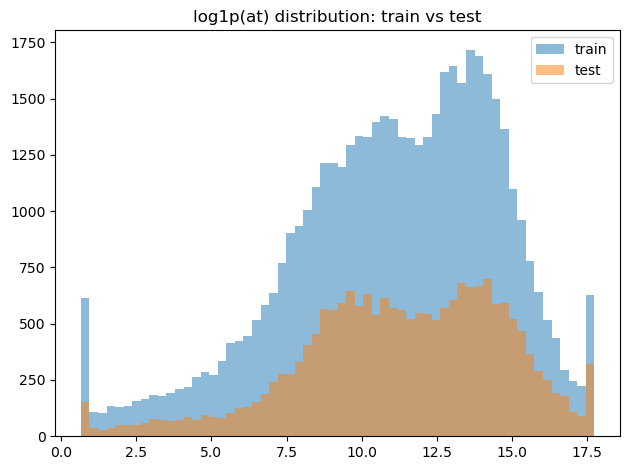

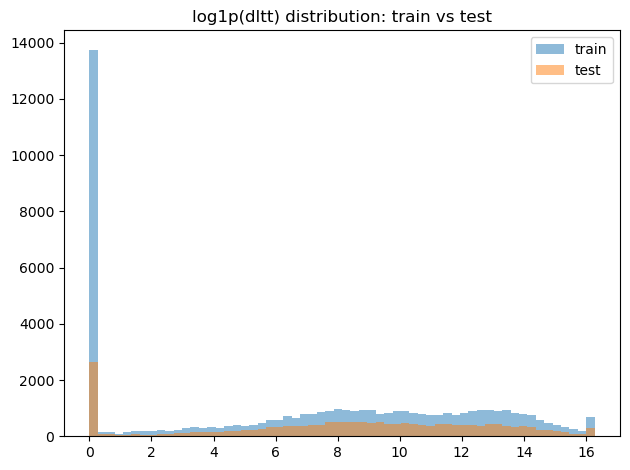

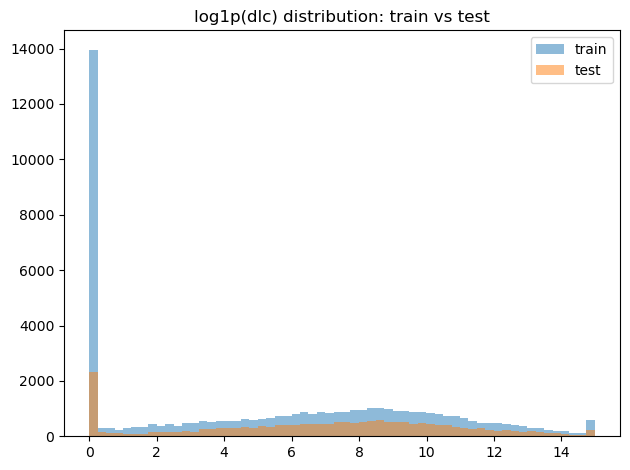

In [18]:
# Lightweight plots to spot gross drift / outliers.
plot_cols = [c for c in ["at","dltt","dlc","oibdp","oancf"] if c in df.columns]

for c in plot_cols[:3]:
    a = pd.to_numeric(df.loc[df["split"]=="train", c], errors="coerce")
    b = pd.to_numeric(df.loc[df["split"]=="test", c], errors="coerce")
    plt.figure()
    plt.hist(np.log1p(a.dropna()), bins=60, alpha=0.5, label="train")
    plt.hist(np.log1p(b.dropna()), bins=60, alpha=0.5, label="test")
    plt.title(f"log1p({c}) distribution: train vs test")
    plt.legend()
    plt.tight_layout()
    plt.savefig(Path(CONFIG["FIG_DIR"]) / f"eda_log1p_{c}_train_vs_test.png", dpi=140)
    plt.show()

## 5. Feature Engineering & Target Construction

I derive all ratio features and events from the cleaned inputs. The distress targets are still computed from the raw (pre-imputation) snapshot to avoid label leakage.



In [19]:
# Variables to exclude from modeling (removed per requirements)
EXCLUDED_VARS = [
    "aco_act", "aqc_at", "caps_at", "capx_at", "dp_at", 
    "invch_act", "lco_lct", "mibt_at", "recch_act", 
    "txditc_at", "txp_lct", "xint_lct"
]

FEATURES_V1 = [
    "ln_at", "cash_at", "current_ratio", "nwc_at", 
    "rect_act", "invt_act",  "ppent_at", "intan_at",
    "lt_at", "dlc_at", "dltt_at", 
    "debt_at", "st_debt_share", "ebitda_at", 
    "xint_at", "interest_coverage", "debt_to_ebitda", "ebit_to_capital",  "ceq_at", "re_at",
    "prstkc_at"
]

FEATURES_V2 = [
    "ln_at", "cash_at", "current_ratio", "nwc_at", 
    "rect_act", "invt_act", "ppent_at", "intan_at", 
    "lt_at", "debt_at", "st_debt_share", 
    "ebitda_at", "xint_at", "interest_coverage", "debt_to_ebitda", 
    "ebit_to_capital", "ocf_to_debt", "fcf_to_debt",
]

FEATURES_V3 = [
    "ln_at", "cash_at", "current_ratio", "nwc_at", 
    "rect_act", "invt_act", 
    "lt_at", "ceq_at", "re_at", 
    "niadj_at", "loss_indicator", 
    "xint_at", "prstkc_at","xint_at", "prstkc_at","ppent_at", "intan_at", "ebit_to_capital", "lt_at"
]
FEATURES_V1_L1 = [f"{c}_l1" for c in FEATURES_V1]
FEATURES_V2_L1 = [f"{c}_l1" for c in FEATURES_V2]
FEATURES_V3_L1 = [f"{c}_l1" for c in FEATURES_V3]


### 5.2 Debt, capital, and operating aggregates

In [20]:
# Ensure all required raw items are numeric for safe arithmetic
raw_items = [
    "at", "che", "act", "lct", "aco", "lco", "rect", "invt", "recch", "invch",
    "txp", "txditc", "lt", "dlc", "dltt", "oibdp", "dp", "xint", "ceq", "capx",
    "ppent", "intan", "oancf", "re", "caps", "mibt", "niadj", "aqc", "prstkc", "seq"
]
for c in raw_items:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Debt aggregate
df["total_debt"] = df[["dlc","dltt"]].sum(axis=1, min_count=1)

# Equity plus minority interest (if available)
if "mibt" in df.columns:
    df["equity_plus_mi"] = df[["seq","mibt"]].sum(axis=1, min_count=1)
else:
    df["equity_plus_mi"] = df["seq"]

# Total capital and a non-positive capital flag
df["total_capital"] = df[["total_debt","equity_plus_mi"]].sum(axis=1, min_count=1)
df["cap_nonpos_flag"] = (df["total_capital"] <= 0).astype("Int8")

# EBITDA proxy
df["ebitda_proxy"] = df["oibdp"]
df["ebitda_nonpos_flag"] = (df["ebitda_proxy"] <= 0).astype("Int8")

# Log transforms
df["ln_at"] = np.log(df["at"].where(lambda s: s > 0))
# Legacy name if needed elsewhere
df["log_at"] = df["ln_at"]


### 5.3 Leverage, coverage, and cash-flow ratios (V1, V2, V3 features)

In [21]:
# --- V1/V2/V3 Shared & Specific Features ---
# (Using safe_divide which handles division by zero and returns NaN for extreme states)

# Basic Ratios
df["cash_at"] = safe_divide(df["che"], df["at"])
df["current_ratio"] = safe_divide(df["act"], df["lct"])
df["nwc_at"] = safe_divide(df["act"] - df["lct"], df["at"])
# Removed: aco_act, lco_lct (excluded variables)
df["rect_act"] = safe_divide(df["rect"], df["act"])
df["invt_act"] = safe_divide(df["invt"], df["act"])
# Removed: recch_act, invch_act, txp_lct, txditc_at (excluded variables)
df["lt_at"] = safe_divide(df["lt"], df["at"])
df["dlc_at"] = safe_divide(df["dlc"], df["at"])
df["dltt_at"] = safe_divide(df["dltt"], df["at"])
df["debt_at"] = safe_divide(df["total_debt"], df["at"])
df["st_debt_share"] = safe_divide(df["dlc"], df["total_debt"])
df["ebitda_at"] = safe_divide(df["oibdp"], df["at"])
# Removed: dp_at (excluded variable)
df["xint_at"] = safe_divide(df["xint"], df["at"])
df["interest_coverage"] = safe_divide(df["oibdp"], df["xint"])
df["debt_to_ebitda"] = safe_divide(df["total_debt"], df["oibdp"])
df["ebit_to_capital"] = safe_divide(df["oibdp"] - df["dp"], df["total_debt"] + df["ceq"])
# Removed: capx_at (excluded variable)

# V2 extras
df["ppent_at"] = safe_divide(df["ppent"], df["at"])
df["intan_at"] = safe_divide(df["intan"], df["at"])
df["ocf_to_debt"] = safe_divide(df["oancf"], df["total_debt"])
df["fcf_to_debt"] = safe_divide(df["oancf"] - df["capx"], df["total_debt"])

# V3 extras
df["re_at"] = safe_divide(df["re"], df["at"])
df["ceq_at"] = safe_divide(df["ceq"], df["at"])
# Removed: caps_at, mibt_at (excluded variables)
df["niadj_at"] = safe_divide(df["niadj"], df["at"])
df["loss_indicator"] = (df["niadj"] < 0).astype(float)
# Removed: xint_lct, aqc_at (excluded variables)
df["prstkc_at"] = safe_divide(df["prstkc"], df["at"])

# --- Legacy mappings for distress proxy definitions (Section 5.4) ---
# (Keeping sp_ prefix for variables used in distress proxy definition rules)
ffo_proxy = df["oancf"] + df["xint"]
if "txp" in df.columns:
    ffo_proxy = ffo_proxy - df["txp"]
df["sp_ffo_to_debt"] = safe_divide(ffo_proxy, df["total_debt"])
df["sp_debt_to_capital"] = safe_divide(df["total_debt"], df["total_capital"])
df["sp_debt_to_ebitda"] = df["debt_to_ebitda"]
df["sp_interest_coverage"] = df["interest_coverage"].clip(lower=-50, upper=50)

# Identify remaining +/-inf (though safe_divide already handles most)
ratio_cols = ["sp_debt_to_capital","sp_debt_to_ebitda","sp_ffo_to_debt","sp_interest_coverage"]
for c in ratio_cols:
    if c in df.columns:
        df[c] = df[c].replace([np.inf, -np.inf], np.nan)

### 5.4 Multiple Distress Proxies (fiscal year t) and next-year supervised labels (t+1)
choose the state/transition for OBJECTIVE and choose the version 1,2,3 as a proxy of distress

In [22]:
# Distress proxy thresholds (frozen and documented)
DISTRESS_RULE = {
    "FFO_TO_DEBT_LT": 0.12,
    "DEBT_TO_CAPITAL_GT": 0.6,
    "DEBT_TO_EBITDA_GT": 5,
    "NEG_EQUITY_SEQ_LE": 0.0,
}

# --- Target construction from raw (non-imputed) data ---
# We compute distress proxies from the raw snapshot (df_pre_impute_snapshot) 
# to ensure that target labels are not contaminated by the imputation process.
# Imputation is strictly reserved for predictive features.

raw_niadj = ensure_nullable_float(df_pre_impute_snapshot["niadj"])
raw_oancf = ensure_nullable_float(df_pre_impute_snapshot["oancf"])
raw_seq = ensure_nullable_float(df_pre_impute_snapshot["seq"])

# S&P components from raw items (propagate missingness - Issue 3)
raw_dlc = ensure_nullable_float(df_pre_impute_snapshot["dlc"])
raw_dltt = ensure_nullable_float(df_pre_impute_snapshot["dltt"])
raw_total_debt = raw_dlc + raw_dltt

raw_oibdp = ensure_nullable_float(df_pre_impute_snapshot["oibdp"])
raw_xint = ensure_nullable_float(df_pre_impute_snapshot["xint"])
raw_txp = ensure_nullable_float(df_pre_impute_snapshot["txp"]) if "txp" in df_pre_impute_snapshot.columns else 0
raw_txp = raw_txp.fillna(0)
raw_ffo = raw_oancf + raw_xint - raw_txp
raw_ffo_to_debt = safe_divide(raw_ffo, raw_total_debt)

raw_mibt = ensure_nullable_float(df_pre_impute_snapshot["mibt"]) if "mibt" in df_pre_impute_snapshot.columns else pd.Series(np.nan, index=df_pre_impute_snapshot.index)
raw_equity = ensure_nullable_float(df_pre_impute_snapshot[["seq","mibt"]].sum(axis=1, min_count=1)) if "mibt" in df_pre_impute_snapshot.columns else raw_seq
raw_total_capital = raw_total_debt + raw_equity

raw_debt_to_cap = safe_divide(raw_total_debt, raw_total_capital)
raw_debt_to_ebitda = safe_divide(raw_total_debt, raw_oibdp)

# V1: Loss + NegCFO (Accounting-based)
# Beaver (1966), Ohlson (1980) logic: niadj < 0 and oancf < 0
df["distress_v1_t"] = (raw_niadj < 0) & (raw_oancf < 0)
# Fix: explicitly set to missing if inputs are missing
df.loc[raw_niadj.isna() | raw_oancf.isna(), "distress_v1_t"] = pd.NA

# V2: Negative Equity
df["distress_v2_t"] = raw_seq <= DISTRESS_RULE["NEG_EQUITY_SEQ_LE"]
# Fix: explicitly set to missing if inputs are missing
df.loc[raw_seq.isna(), "distress_v2_t"] = pd.NA

# V3: S&P High Leverage Solely (without conditioning on negative equity)
cond_ffo = raw_ffo_to_debt < DISTRESS_RULE["FFO_TO_DEBT_LT"]
cond_cap = raw_debt_to_cap > DISTRESS_RULE["DEBT_TO_CAPITAL_GT"]
cond_ebitda = raw_debt_to_ebitda > DISTRESS_RULE["DEBT_TO_EBITDA_GT"]
df["distress_v3_t"] = cond_ffo & cond_cap & cond_ebitda
# Fix: explicitly set to missing if inputs are missing
df.loc[raw_ffo_to_debt.isna() | raw_debt_to_cap.isna() | raw_debt_to_ebitda.isna(), "distress_v3_t"] = pd.NA

# Next-year targets: lead of proxies within firm
# Fix: Robust adjacency check (exactly fyear + 1) to avoid mislabeling gaps (Issue 1)
next_fyear = df.groupby("firm_id")["fyear"].shift(-1)
is_adjacent = (next_fyear == (df["fyear"] + 1))

df["target_next_v1"] = df.groupby("firm_id")["distress_v1_t"].shift(-1)
df.loc[~is_adjacent, "target_next_v1"] = pd.NA
df["target_next_v1"] = df["target_next_v1"].astype("Int8")

df["target_next_v2"] = df.groupby("firm_id")["distress_v2_t"].shift(-1)
df.loc[~is_adjacent, "target_next_v2"] = pd.NA
df["target_next_v2"] = df["target_next_v2"].astype("Int8")

df["target_next_v3"] = df.groupby("firm_id")["distress_v3_t"].shift(-1)
df.loc[~is_adjacent, "target_next_v3"] = pd.NA
df["target_next_v3"] = df["target_next_v3"].astype("Int8")

# Transition targets (early-warning): 1[distress_t==0 AND distress_{t+1}==1]
# - Defined only for observations that are *healthy at t* (distress_t==0) and have an adjacent t+1.
# - Rows with distress_t==1 are set to NA (they are not part of the early-warning risk set).
for _v in ["v1", "v2", "v3"]:
    _dcol = f"distress_{_v}_t"
    _ncol = f"target_next_{_v}"
    _tcol = f"target_transition_{_v}"

    _dcur = pd.to_numeric(df[_dcol], errors="coerce")  # {0,1} with NaNs
    _ncur = pd.to_numeric(df[_ncol], errors="coerce")

    df[_tcol] = pd.NA
    _ok = is_adjacent & _dcur.notna() & _ncur.notna()

    _healthy = _ok & (_dcur == 0)
    df.loc[_healthy, _tcol] = (_ncur.loc[_healthy] == 1).astype("Int8")

    df[_tcol] = df[_tcol].astype("Int8")

# -------------------------
# Modeling objective + proxy selection
# -------------------------
# PROXY_VERSION: choose among {"v1","v2","v3"}.
# OBJECTIVE:
#   - "transition": early-warning (healthy at t -> distressed at t+1)   [recommended for claims of "early warning"]
#   - "state":       surveillance of the t+1 distress state (includes persistence)
PROXY_VERSION = "v1"
OBJECTIVE = "transition"

PROXY_NAME = f"distress_{PROXY_VERSION}_t"
STATE_TARGET_NAME = f"target_next_{PROXY_VERSION}"
TRANS_TARGET_NAME = f"target_transition_{PROXY_VERSION}"
TARGET_NAME = TRANS_TARGET_NAME if OBJECTIVE.lower().startswith("trans") else STATE_TARGET_NAME

# Label availability / attrition (fixed to check adjacency)
df["has_next_year_obs"] = is_adjacent.fillna(False).astype("Int8")

target_cols = ["target_next_v1", "target_next_v2", "target_next_v3"]
print("Distress prevalence (by split) — multiple targets:")
display(df.groupby("split")[target_cols].mean())

print("Share of observations with next-year observation (attrition diagnostic):")
display(df.groupby("split")["has_next_year_obs"].mean().rename("has_next_rate").to_frame())

Distress prevalence (by split) — multiple targets:


,target_next_v1,target_next_v2,target_next_v3
split,,,
test,0.333848,0.121023,0.041427
train,0.314055,0.12144,0.04666
val,0.372697,0.113658,0.047931


Share of observations with next-year observation (attrition diagnostic):


,has_next_rate
split,
test,0.627183
train,0.915308
val,0.929791


### 5.5 Target prevalence and attrition diagnostics (by year and size)

In [23]:
# Target prevalence by label year
import numpy as np
import pandas as pd

if "label_year" not in df.columns and "fyear" in df.columns:
    df["label_year"] = (df["fyear"] + 1).astype("Int64")

if "split" not in df.columns:
    df["split"] = "train"

if "size_decile" not in df.columns:
    if "train_mask" not in globals():
        train_mask = df["split"].eq("train") if "split" in df.columns else pd.Series(True, index=df.index)
    if "at" in df.columns:
        at_train = pd.to_numeric(df.loc[train_mask, "at"], errors="coerce")
        log_at_train = np.log(at_train.where(at_train > 0)).dropna()
        if len(log_at_train) < 50:
            df["size_decile"] = 5
        else:
            qs = np.linspace(0, 1, 11)
            size_edges = log_at_train.quantile(qs).values
            size_edges[0] = -np.inf
            size_edges[-1] = np.inf
            log_at_all = np.log(pd.to_numeric(df["at"], errors="coerce").where(lambda s: s > 0))
            df["size_decile"] = pd.cut(log_at_all, bins=size_edges, labels=False, include_lowest=True).astype("Float64")
        sd_med = float(pd.to_numeric(df.loc[train_mask, "size_decile"], errors="coerce").median())
        df["size_decile"] = pd.to_numeric(df["size_decile"], errors="coerce").fillna(sd_med).astype(int)
    else:
        df["size_decile"] = 5

# Target prevalence by label year
if "has_next_year_obs" not in df.columns:
    df["has_next_year_obs"] = pd.NA

target_cols = ["target_next_v1", "target_next_v2", "target_next_v3"]
agg_dict = {
    "n_obs": ("firm_id", "size"),
    "has_next_rate": ("has_next_year_obs", "mean"),
}
for c in target_cols:
    agg_dict[f"{c}_rate"] = (c, "mean")

by_label_year = df.groupby(["label_year", "split"]).agg(**agg_dict).reset_index()

display(by_label_year.tail(15))

# By size decile (train pool), to assess composition effects
agg_dict_size = {"n_obs": ("firm_id", "size")}
for c in target_cols:
    agg_dict_size[f"{c}_rate"] = (c, "mean")

by_size = df.groupby(["size_decile", "split"]).agg(**agg_dict_size).reset_index()

display(by_size.sort_values(["split", "size_decile"]).head(30))


,label_year,split,n_obs,has_next_rate,target_next_v1_rate,target_next_v2_rate,target_next_v3_rate
0,2015,train,7455,0.900738,0.305734,0.135071,0.043657
1,2016,train,7178,0.905405,0.301609,0.130635,0.04435
2,2017,train,6970,0.915208,0.303875,0.118984,0.04703
3,2018,train,6831,0.915825,0.308717,0.12426,0.047362
4,2019,train,6672,0.916667,0.310809,0.126226,0.051482
5,2020,train,6649,0.927658,0.330677,0.116245,0.048917
6,2021,train,6703,0.928092,0.338496,0.097251,0.043782
7,2022,val,6851,0.929791,0.372697,0.113658,0.047931
8,2023,test,6848,0.916472,0.339779,0.119822,0.038213
9,2024,test,6611,0.919226,0.327723,0.122264,0.044773


,size_decile,split,n_obs,target_next_v1_rate,target_next_v2_rate,target_next_v3_rate
0,0,test,1500,0.658455,0.397765,0.027607
3,1,test,1671,0.368522,0.222645,0.039752
6,2,test,2182,0.423503,0.140866,0.043112
9,3,test,2232,0.478545,0.126812,0.023194
12,4,test,2045,0.506998,0.141414,0.013397
15,5,test,1928,0.471854,0.087676,0.030542
18,6,test,1823,0.300441,0.070423,0.038674
21,7,test,1925,0.185913,0.052245,0.062232
24,8,test,2072,0.059542,0.047256,0.073434
27,9,test,2318,0.027443,0.029431,0.066161


### 5.6 Event indicators (evt_*) for decision support

Events are discrete, interpretable signals designed for operational triage in Section 9
They are calibrated **using training data only** (when thresholds are estimated), and we explicitly **exclude** events mechanically tied to the distress-definition ratios (leverage/coverage) from the predictive feature set.

Events implemented here (subject to data availability):
- Dividend cut / suspension / initiation
- Liquidity squeeze (current ratio < 1.0) and quick-ratio squeeze (< 0.8)
- EBITDA drop (vs. t-1) and CFO drop (vs. t-1)

In [24]:
# Ensure sorting already enforced
assert df.index.is_monotonic_increasing

# Lag helpers
def lag(df_in: pd.DataFrame, col: str, n: int = 1) -> pd.Series:
    """Robust firm-level lag that enforces year adjacency (Issue 1)."""
    val = df_in.groupby("firm_id")[col].shift(n)
    year_lag = df_in.groupby("firm_id")["fyear"].shift(n)
    is_adjacent = (year_lag == (df_in["fyear"] - n))
    return val.where(is_adjacent.fillna(False), np.nan)


# Create 1-year lagged predictors for all feature sets
LAG_BASE_FEATURES = FEATURES_V1 + FEATURES_V2 + FEATURES_V3
for _c in LAG_BASE_FEATURES:
    if _c in df.columns:
        df[f"{_c}_l1"] = lag(df, _c, 1)
# Identify dividend column (prefer dvc if present; else dv / dvt / dvp)
dividend_candidates = ["dvc","dv","dvt","dvp"]
div_col = next((c for c in dividend_candidates if c in df.columns), None)

if div_col is None:
    print("Dividend column not found (looked for dvc/dv/dvt/dvp). Dividend events will be NaN.")
    df["evt_divcut"] = np.nan
    df["evt_divsusp"] = np.nan
    df["evt_divinit"] = np.nan
else:
    # Use absolute value (guard against sign conventions)
    df["dv_obs"] = pd.to_numeric(df[div_col], errors="coerce").abs()
    df["dv_obs_l1"] = lag(df, "dv_obs", 1)

# Liquidity ratios
if "act" in df.columns and "lct" in df.columns:
    df["current_ratio"] = safe_divide(df["act"], df["lct"], denom_floor=1e-6)
else:
    df["current_ratio"] = np.nan

if "act" in df.columns and "lct" in df.columns:
    if "invt" in df.columns:
        df["quick_ratio"] = safe_divide(pd.to_numeric(df["act"], errors="coerce") - pd.to_numeric(df["invt"], errors="coerce"),
                                        df["lct"], denom_floor=1e-6)
    elif "che" in df.columns and "rect" in df.columns:
        df["quick_ratio"] = safe_divide(pd.to_numeric(df["che"], errors="coerce") + pd.to_numeric(df["rect"], errors="coerce"),
                                        df["lct"], denom_floor=1e-6)
    else:
        df["quick_ratio"] = df["current_ratio"]
else:
    df["quick_ratio"] = np.nan

# EBITDA and CFO lags for deterioration events
if "ebitda_proxy" in df.columns:
    df["ebitda_l1"] = lag(df, "ebitda_proxy", 1)
if "oancf" in df.columns:
    df["cfo_l1"] = lag(df, "oancf", 1)

#### 5.5.1 Dividend policy events (training-calibrated cut threshold)

In [25]:
event_params = {}

if div_col is None:
    pass
else:
    # YoY % change among observed payers with meaningful baseline
    dv_l1 = pd.to_numeric(df["dv_obs_l1"], errors="coerce")
    dv = pd.to_numeric(df["dv_obs"], errors="coerce")
    df["div_pct_change"] = np.where(dv_l1 > 1e-2, (dv - dv_l1) / dv_l1, np.nan)

    payer_train = train_mask & (dv_l1 > 0) & pd.notna(df["div_pct_change"])
    if payer_train.sum() >= 50:
        cut_thr = float(np.nanpercentile(df.loc[payer_train, "div_pct_change"], 10))
    else:
        cut_thr = -0.25

    # Bound cut threshold to avoid pathological values
    cut_thr = float(np.clip(cut_thr, -0.50, -0.10))
    event_params["DIV_CUT_THR_P10_BOUNDED"] = cut_thr

    # Dividend cut: large negative YoY change among payers
    df["evt_divcut"] = (df["div_pct_change"] <= cut_thr).astype("Int8")
    df.loc[df["div_pct_change"].isna(), "evt_divcut"] = pd.NA

    # Suspension: payer last year, ~zero dividend now
    df["evt_divsusp"] = ((dv_l1 > 0) & (dv.fillna(0) <= 1e-4)).astype("Int8")
    df.loc[dv_l1.isna() | dv.isna(), "evt_divsusp"] = pd.NA

    # Initiation: ~zero last year, dividend now positive
    df["evt_divinit"] = ((dv_l1.fillna(0) <= 1e-4) & (dv > 1e-4)).astype("Int8")
    df.loc[dv_l1.isna() | dv.isna(), "evt_divinit"] = pd.NA

    print(f"Dividend cut threshold (train P10 bounded): {cut_thr:.3f}")
    display(df[["dv_obs","dv_obs_l1","div_pct_change","evt_divcut","evt_divsusp","evt_divinit"]].head(8))

Dividend cut threshold (train P10 bounded): -0.500


,dv_obs,dv_obs_l1,div_pct_change,evt_divcut,evt_divsusp,evt_divinit
0,11905.0,NaN,NaN,<NA>,<NA>,<NA>
1,13697.0,11905.0,0.150525,0,0,0
2,15447.0,13697.0,0.127765,0,0,0
3,17287.0,15447.0,0.119117,0,0,0
4,18854.0,17287.0,0.090646,0,0,0
5,20593.0,18854.0,0.092235,0,0,0
6,11218.0,20593.0,-0.455252,0,0,0
7,22179.0,11218.0,0.977090,0,0,0


#### 5.5.2 Liquidity squeeze events

In [26]:
cr = pd.to_numeric(df["current_ratio"], errors="coerce")
df["evt_liq_squeeze"] = (cr < 1.0).astype("Int8")
df.loc[cr.isna(), "evt_liq_squeeze"] = pd.NA

qr = pd.to_numeric(df["quick_ratio"], errors="coerce")
df["evt_quick_squeeze"] = (qr < 0.8).astype("Int8")
df.loc[qr.isna(), "evt_quick_squeeze"] = pd.NA

display(df[["current_ratio","quick_ratio","evt_liq_squeeze","evt_quick_squeeze"]].head(8))

,current_ratio,quick_ratio,evt_liq_squeeze,evt_quick_squeeze
0,1.857971,0.749443,0,1
1,0.001967,-1.169719,1,1
2,1.813861,0.712973,0,1
3,1.735209,0.593500,0,1
4,1.747436,0.628349,0,1
5,1.775434,0.585567,0,1
6,1.977964,0.836194,0,0
7,1.492971,0.508954,0,1


#### 5.5.3 Operating deterioration events (vs. t-1)

In [27]:
# EBITDA drop: requires lagged EBITDA observed and positive
if "ebitda_proxy" in df.columns:
    e = pd.to_numeric(df["ebitda_proxy"], errors="coerce")
    e_l1 = pd.to_numeric(df["ebitda_l1"], errors="coerce")
    ratio = e / e_l1
    evt = ((e_l1 > 0) & ((ratio < 0.5) | (e <= 0))).astype("Int8")
    evt = evt.where(pd.notna(e_l1) & pd.notna(e), other=pd.NA).astype("Int8")
    df["evt_ebitdadrop"] = evt
else:
    df["evt_ebitdadrop"] = pd.NA

# CFO drop: requires lagged CFO observed and positive
if "oancf" in df.columns:
    c = pd.to_numeric(df["oancf"], errors="coerce")
    c_l1 = pd.to_numeric(df["cfo_l1"], errors="coerce")
    ratio = c / c_l1
    evt = ((c_l1 > 0) & ((ratio < 0.5) | (c <= 0))).astype("Int8")
    evt = evt.where(pd.notna(c_l1) & pd.notna(c), other=pd.NA).astype("Int8")
    df["evt_cfdrop"] = evt
else:
    df["evt_cfdrop"] = pd.NA

display(df[["ebitda_proxy","ebitda_l1","evt_ebitdadrop","oancf","cfo_l1","evt_cfdrop"]].head(10))

,ebitda_proxy,ebitda_l1,evt_ebitdadrop,oancf,cfo_l1,evt_cfdrop
0,113.4,NaN,<NA>,46987.00,NaN,<NA>
1,97361.0,113.4,0,65171.00,46987.0,0
2,121286.0,97361.0,0,97805.00,65171.0,0
3,126988.0,121286.0,0,64617.00,97805.0,0
4,105555.0,126988.0,0,70258.00,64617.0,0
5,122894.0,105555.0,0,76928.00,70258.0,0
6,138308.0,122894.0,0,97896.00,76928.0,0
7,158338.0,138308.0,0,85564.00,97896.0,0
8,141213.0,158338.0,0,-27533.00,85564.0,1
9,124265.0,141213.0,0,144.26,-27533.0,0


#### 5.5.4 Event dictionary (appendix-ready)

In [28]:
event_dict_rows = [
    {"event":"evt_divcut", "definition":"Dividend YoY % change <= training P10 threshold (bounded [-0.50,-0.10])", "inputs":div_col or "N/A", "calibration":"train-only"},
    {"event":"evt_divsusp", "definition":"Dividend >0 at t-1 and ~0 at t", "inputs":div_col or "N/A", "calibration":"none"},
    {"event":"evt_divinit", "definition":"Dividend ~0 at t-1 and >0 at t", "inputs":div_col or "N/A", "calibration":"none"},
    {"event":"evt_liq_squeeze", "definition":"Current ratio < 1.0", "inputs":"act,lct", "calibration":"fixed threshold"},
    {"event":"evt_quick_squeeze", "definition":"Quick ratio < 0.8", "inputs":"act,lct,invt (or che+rect)", "calibration":"fixed threshold"},
    {"event":"evt_ebitdadrop", "definition":"EBITDA <=0 OR EBITDA/EBITDA_{t-1}<0.5 (requires EBITDA_{t-1}>0)", "inputs":"oibdp", "calibration":"fixed threshold"},
    {"event":"evt_cfdrop", "definition":"CFO <=0 OR CFO/CFO_{t-1}<0.5 (requires CFO_{t-1}>0)", "inputs":"oancf", "calibration":"fixed threshold"},
]
event_dict = pd.DataFrame(event_dict_rows)
event_dict["parameter"] = event_dict["event"].map(lambda e: json.dumps({k:v for k,v in event_params.items()}) if e=="evt_divcut" else "")
display(event_dict)

,event,definition,inputs,calibration,parameter
0,evt_divcut,Dividend YoY % change <= training P10 threshol...,dvc,train-only,"{""DIV_CUT_THR_P10_BOUNDED"": -0.5}"
1,evt_divsusp,Dividend >0 at t-1 and ~0 at t,dvc,none,
2,evt_divinit,Dividend ~0 at t-1 and >0 at t,dvc,none,
3,evt_liq_squeeze,Current ratio < 1.0,"act,lct",fixed threshold,
4,evt_quick_squeeze,Quick ratio < 0.8,"act,lct,invt (or che+rect)",fixed threshold,
5,evt_ebitdadrop,EBITDA <=0 OR EBITDA/EBITDA_{t-1}<0.5 (require...,oibdp,fixed threshold,
6,evt_cfdrop,CFO <=0 OR CFO/CFO_{t-1}<0.5 (requires CFO_{t-...,oancf,fixed threshold,


## 6. Preprocessing for Modeling (train-only fitting)

I keep preprocessing leakage-safe:
- fit medians, winsor bounds, and scalers on **train** only,
- apply those transforms to all splits,
- preserve an unprocessed snapshot for walk-forward validation.



In [29]:
# Features that participate in the distress proxy definition (must be excluded from predictors)
# We key off PROXY_VERSION (not TARGET_NAME) so the same leakage rules apply to both objectives:
#   - OBJECTIVE="state"       -> TARGET_NAME = target_next_vX
#   - OBJECTIVE="transition"  -> TARGET_NAME = target_transition_vX

try:
    _pv = PROXY_VERSION
except NameError:
    # Backward compatibility if PROXY_VERSION is not defined in the targets cell
    if TARGET_NAME.endswith("_v1"):
        _pv = "v1"
    elif TARGET_NAME.endswith("_v2"):
        _pv = "v2"
    elif TARGET_NAME.endswith("_v3"):
        _pv = "v3"
    else:
        _pv = "v2"


def _dedupe(seq):
    seen = set()
    out = []
    for item in seq:
        if item not in seen:
            out.append(item)
            seen.add(item)
    return out


if _pv == "v1":
    # v1 uses niadj and oancf
    DISTRESS_DEFINITION_VARS = {"niadj", "oancf", "niadj_at", "loss_indicator", "ocf_to_debt", "fcf_to_debt"}
    continuous_feats_raw = _dedupe(FEATURES_V1 + FEATURES_V1_L1)
    event_feats = []
elif _pv == "v2":
    # v2 uses seq
    DISTRESS_DEFINITION_VARS = {"seq"}
    continuous_feats_raw = _dedupe(FEATURES_V2 + FEATURES_V2_L1)
    event_feats = []
elif _pv == "v3":
    # v3 uses ffo (oancf, xint, txp), debt (dlc, dltt), and equity (seq, mibt)
    DISTRESS_DEFINITION_VARS = {
        "sp_ffo_to_debt", "sp_debt_to_capital", "sp_debt_to_ebitda",
        "oancf", "xint", "txp", "dlc", "dltt", "seq", "mibt", "oibdp",
        "ocf_to_debt", "fcf_to_debt", "debt_to_ebitda", "interest_coverage"
    }
    # loss_indicator is binary, treat as event feature to avoid z-scoring
    continuous_feats_raw = _dedupe([c for c in (FEATURES_V3 + FEATURES_V3_L1) if c not in {"loss_indicator", "loss_indicator_l1"}])
    event_feats = _dedupe(["loss_indicator", "loss_indicator_l1"])
else:
    DISTRESS_DEFINITION_VARS = set()
    continuous_feats_raw = _dedupe(FEATURES_V2 + FEATURES_V2_L1)
    event_feats = []
continuous_feats_raw = [c for c in continuous_feats_raw if c in df.columns]
event_feats = [c for c in event_feats if c in df.columns]

# Final model feature list (events in levels; continuous will be z-scored with z_ prefix)
MODEL_FEATS = [f"z_{c}" for c in continuous_feats_raw] + event_feats

# Leakage audit: ensure no distress-definition variables are included (raw or scaled variants)
leakage_hits = []
for v in DISTRESS_DEFINITION_VARS:
    if v in continuous_feats_raw or v in event_feats or f"z_{v}" in MODEL_FEATS:
        leakage_hits.append(v)

if leakage_hits:
    raise ValueError(f"Leakage audit failed: distress-definition variables present in feature set: {leakage_hits}")

print("Continuous (to be scaled):", continuous_feats_raw)
print("Events (kept in levels):", event_feats)
print("MODEL_FEATS (post-scaling names):", MODEL_FEATS)


Continuous (to be scaled): ['ln_at', 'cash_at', 'current_ratio', 'nwc_at', 'rect_act', 'invt_act', 'ppent_at', 'intan_at', 'lt_at', 'dlc_at', 'dltt_at', 'debt_at', 'st_debt_share', 'ebitda_at', 'xint_at', 'interest_coverage', 'debt_to_ebitda', 'ebit_to_capital', 'ceq_at', 're_at', 'prstkc_at', 'ln_at_l1', 'cash_at_l1', 'current_ratio_l1', 'nwc_at_l1', 'rect_act_l1', 'invt_act_l1', 'ppent_at_l1', 'intan_at_l1', 'lt_at_l1', 'dlc_at_l1', 'dltt_at_l1', 'debt_at_l1', 'st_debt_share_l1', 'ebitda_at_l1', 'xint_at_l1', 'interest_coverage_l1', 'debt_to_ebitda_l1', 'ebit_to_capital_l1', 'ceq_at_l1', 're_at_l1', 'prstkc_at_l1']
Events (kept in levels): []
MODEL_FEATS (post-scaling names): ['z_ln_at', 'z_cash_at', 'z_current_ratio', 'z_nwc_at', 'z_rect_act', 'z_invt_act', 'z_ppent_at', 'z_intan_at', 'z_lt_at', 'z_dlc_at', 'z_dltt_at', 'z_debt_at', 'z_st_debt_share', 'z_ebitda_at', 'z_xint_at', 'z_interest_coverage', 'z_debt_to_ebitda', 'z_ebit_to_capital', 'z_ceq_at', 'z_re_at', 'z_prstkc_at', 'z_

### 6.2 Modeling sample and target availability

In [30]:
# Modeling requires a defined next-year label
model_mask = df[TARGET_NAME].notna()
df_model = df.loc[model_mask].copy()

print("Modeling sample size:", df_model.shape[0])
display(df_model["split"].value_counts().to_frame("n_obs"))
# Snapshot for leakage-free walk-forward validation
df_model_raw = df_model.copy(deep=True)


Modeling sample size: 42348


,n_obs
split,
train,30211
test,8035
val,4102


### 6.3 Replace infinities and set up train-only median imputation for remaining NaNs

In [31]:
# Replace inf with NaN for preprocessing
for c in continuous_feats_raw:
    df_model[c] = pd.to_numeric(df_model[c], errors="coerce").replace([np.inf, -np.inf], np.nan)

# Train-only medians for remaining NaNs (after earlier imputation steps)
train_medians = df_model.loc[df_model["split"]=="train", continuous_feats_raw].median()

for c in continuous_feats_raw:
    df_model[c] = df_model[c].fillna(train_medians[c])

# Event features: coerce to Int8 with missing -> 0 (conservative) but preserve missingness flags separately if desired
for c in event_feats:
    df_model[c] = pd.to_numeric(df_model[c], errors="coerce").fillna(0).astype("Int8")

assert df_model[continuous_feats_raw].isna().sum().sum() == 0, "NaNs remain in continuous features after train-median fill."

### 6.4 Winsorize continuous features (train quantile bounds)

In [32]:
winsor_bounds = {}
for c in continuous_feats_raw:
    lo, hi = winsorize_train_bounds(df_model.loc[df_model["split"]=="train", c], CONFIG["WINSOR_LO_Q"], CONFIG["WINSOR_HI_Q"])
    winsor_bounds[c] = (lo, hi)
    df_model[c] = apply_bounds(df_model[c], lo, hi)

winsor_tbl = pd.DataFrame(
    [{"feature": c, "lo": winsor_bounds[c][0], "hi": winsor_bounds[c][1]} for c in continuous_feats_raw]
)
display(winsor_tbl)

,feature,lo,hi
0,ln_at,2.999355,17.742346
1,cash_at,0.000000,339.438869
2,current_ratio,0.000813,3789.054582
3,nwc_at,-115.956333,458.238228
4,rect_act,0.000000,555.220324
5,invt_act,0.000000,402.583028
6,ppent_at,0.000000,657.296320
7,intan_at,0.000000,377.879934
8,lt_at,0.000235,905.862073
9,dlc_at,0.000000,101.188215


### 6.5 Standardize continuous features (train-fit scaler; z_ prefix)

In [33]:
from sklearn.preprocessing import StandardScaler

# Standardize continuous features (fit on TRAIN only)
scaler = StandardScaler()
df_model[continuous_feats_raw] = df_model[continuous_feats_raw].apply(lambda s: pd.to_numeric(s, errors="coerce"))

train_cont = df_model.loc[df_model["split"] == "train", continuous_feats_raw].astype(float)
scaler.fit(train_cont)

Z_all = scaler.transform(df_model[continuous_feats_raw].astype(float))
for j, c in enumerate(continuous_feats_raw):
    df_model[f"z_{c}"] = Z_all[:, j].astype(float)

# Final modeling matrix (events forced to clean 0/1 ints)
z_cols = [f"z_{c}" for c in continuous_feats_raw]
X = df_model[z_cols + event_feats].copy()

# Guardrail check: verify excluded variables are not present in final feature matrix
EXCLUDED_VARS = [
    "aco_act", "aqc_at", "caps_at", "capx_at", "dp_at",
    "invch_act", "lco_lct", "mibt_at", "recch_act",
    "txditc_at", "txp_lct", "xint_lct"
]
EXCLUDED_Z_VARS = [f"z_{v}" for v in EXCLUDED_VARS]
offending_cols = [c for c in X.columns if c in EXCLUDED_VARS or c in EXCLUDED_Z_VARS]
if offending_cols:
    raise ValueError(f"Guardrail check failed: Excluded variables found in final feature matrix X: {offending_cols}")

for c in event_feats:
    X[c] = pd.to_numeric(X[c], errors="coerce")
    X[c] = X[c].fillna(0).astype("int8")
    assert set(X[c].unique()).issubset({0, 1}), f"{c} not binary after coercion: {sorted(X[c].unique())}"

y = df_model[TARGET_NAME].astype(int)

# Split views
splits = {}
for sp in ["train", "val", "test"]:
    mask = df_model["split"] == sp
    splits[sp] = {"X": X.loc[mask, :], "y": y.loc[mask], "df": df_model.loc[mask, :]}

print({sp: (v["X"].shape[0], v["X"].shape[1]) for sp, v in splits.items()})

# Numeric-safe finiteness check
assert np.isfinite(X.astype("float64").to_numpy()).all(), "Non-finite values in modeling matrix."


{'train': (30211, 42), 'val': (4102, 42), 'test': (8035, 42)}


## 7. Model Selection & Training

### 7A. Logit model (primary baseline: calibrated PD with interpretable coefficients)

#### 7A.1 Hyperparameter tuning on out-of-time validation year

In [34]:
train_X, train_y = splits["train"]["X"], splits["train"]["y"]
val_X, val_y = splits["val"]["X"], splits["val"]["y"]

results = []
for C in CONFIG["LOGIT_C_GRID"]:
    mdl = LogisticRegression(C=C, solver="lbfgs", max_iter=2000, random_state=SEED)
    mdl.fit(train_X, train_y)
    val_proba = mdl.predict_proba(val_X)[:, 1]
    results.append({
        "C": C,
        "val_roc_auc": roc_auc_score(val_y, val_proba),
        "val_pr_auc": average_precision_score(val_y, val_proba),
        "val_brier": brier_score_loss(val_y, val_proba),
    })

tune_tbl = pd.DataFrame(results).sort_values("val_roc_auc", ascending=False)
display(tune_tbl)

best_C = float(tune_tbl.iloc[0]["C"])
print("Selected C:", best_C)

,C,val_roc_auc,val_pr_auc,val_brier
0,0.0010,0.723950,0.303110,0.088151
1,0.0050,0.723757,0.307399,0.087304
2,0.0075,0.723538,0.308293,0.087242
3,0.0150,0.723224,0.308636,0.087177


Selected C: 0.001


#### 7A.2 Fit Logit models and generate PDs

In [35]:
trainval_mask = df_model["split"].isin(["train","val"])
X_trainval = X.loc[trainval_mask, :]
y_trainval = y.loc[trainval_mask]

# To ensure 'val' metrics are honest out-of-sample estimates, we use the model 
# trained on 'train' only for the validation split. 
# For the final 'test' performance, we use the model trained on 'train+val'.

# Model trained on 'train' ONLY (for honest 'val' evaluation)
logit_train_only = LogisticRegression(C=best_C, solver="lbfgs", max_iter=3000, random_state=SEED)
logit_train_only.fit(train_X, train_y)

# Model trained on 'train+val' (for final 'test' evaluation)
logit_trainval = LogisticRegression(C=best_C, solver="lbfgs", max_iter=3000, random_state=SEED)
logit_trainval.fit(X_trainval, y_trainval)

# Assign predictions
df_model["pd_logit"] = np.nan
# val gets predictions from train-only model (honest out-of-sample)
df_model.loc[df_model["split"]=="val", "pd_logit"] = logit_train_only.predict_proba(val_X)[:, 1]
# test gets predictions from train+val model
df_model.loc[df_model["split"]=="test", "pd_logit"] = logit_trainval.predict_proba(splits["test"]["X"])[:, 1]
# train gets predictions from train+val model (in-sample)
df_model.loc[df_model["split"]=="train", "pd_logit"] = logit_trainval.predict_proba(train_X)[:, 1]

# For legacy compatibility in reporting
df_model["pd_logit_val"] = np.where(df_model["split"]=="val", df_model["pd_logit"], np.nan)
df_model["pd_logit_test"] = np.where(df_model["split"]=="test", df_model["pd_logit"], np.nan)

# Keep logit_clf as the final model for downstream use
logit_clf = logit_trainval

print("Example PDs (Logit):")
display(df_model[["firm_id","fyear","label_year","split",TARGET_NAME,"pd_logit"]].head(10))

Example PDs (Logit):


,firm_id,fyear,label_year,split,target_transition_v1,pd_logit
0,10000,2014,2015,train,0,0.086721
1,10000,2015,2016,train,0,0.124222
2,10000,2016,2017,train,0,0.117455
3,10000,2017,2018,train,0,0.106812
4,10000,2018,2019,train,0,0.105924
5,10000,2019,2020,train,0,0.043950
6,10000,2020,2021,train,0,0.012316
7,10000,2021,2022,val,0,0.034440
8,10000,2022,2023,test,0,0.065112
9,10000,2023,2024,test,0,0.050613


#### 7A.3 Inference audit (statsmodels Logit; clustered standard errors)

In [36]:

import statsmodels.api as sm
from scipy import stats

# Statsmodels requires numpy arrays; keep column names for tables.
X_sm = sm.add_constant(X_trainval, has_constant="add")
y_sm = y_trainval.astype(float)

# --- Firm cluster (numeric codes to avoid dtype issues) ---
firm_raw = df_model.loc[trainval_mask, "firm_id"]
firm_codes = pd.factorize(firm_raw, sort=True)[0].astype(np.int64)

logit_sm = sm.Logit(y_sm, X_sm)

# IMPORTANT: use statsmodels' built-in clustered covariance during estimation (more stable than post-hoc cov_cluster_2groups)
res_sm = logit_sm.fit(
    disp=False,
    maxiter=200,
    cov_type="cluster",
    cov_kwds={"groups": firm_codes},
)

coef = res_sm.params
se = res_sm.bse
pvals = res_sm.pvalues

infer_tbl = pd.DataFrame({
    "coef_logodds": coef,
    "se_firm_cluster": se,
    "p_firm_cluster": pvals,
    "odds_ratio": np.exp(coef),
})
infer_tbl.index.name = "feature"
display(infer_tbl)

print(f"Number of firm clusters: {int(np.unique(firm_codes).size)}")


,coef_logodds,se_firm_cluster,p_firm_cluster,odds_ratio
feature,,,,
const,-2.718123,0.028257,0.000000e+00,0.065999
z_ln_at,-0.613761,0.040741,2.755026e-51,0.541311
z_cash_at,0.057415,0.030503,5.979760e-02,1.059095
z_current_ratio,0.101060,0.017558,8.619895e-09,1.106343
z_nwc_at,-0.003682,0.029663,9.012104e-01,0.996325
z_rect_act,-0.051305,0.027504,6.213052e-02,0.949989
z_invt_act,0.065638,0.023737,5.688612e-03,1.067841
z_ppent_at,-0.053490,0.028595,6.139857e-02,0.947916
z_intan_at,-0.030151,0.029332,3.039881e-01,0.970299


Number of firm clusters: 7053


#### 7A.4 Economic magnitude: MEM marginal effects and IQR-scaled effects

In [37]:
# MEM marginal effects using statsmodels (on train+val)
try:
    me = res_sm.get_margeff(at="mean")
    me_tbl = me.summary_frame()
    # Align to inference table index (margeff typically excludes const)
    me_tbl = me_tbl.reindex(infer_tbl.index)
    display(me_tbl)
except Exception as e:
    print("Marginal effects computation failed:", e)
    me_tbl = None

# IQR-scaled effects for continuous features (using TRAIN distribution, mapped into z-space)
train_df = df_model.loc[df_model["split"]=="train", :].copy()

iqr_rows = []
for j, raw_c in enumerate(continuous_feats_raw):
    q25 = float(train_df[raw_c].quantile(0.25))
    q75 = float(train_df[raw_c].quantile(0.75))
    iqr = q75 - q25
    sd = float(scaler.scale_[j]) if scaler.scale_[j] > 0 else np.nan
    delta_z = iqr / sd if sd and not np.isnan(sd) else np.nan
    beta = float(infer_tbl.loc[f"z_{raw_c}", "coef_logodds"]) if f"z_{raw_c}" in infer_tbl.index else np.nan
    logodds_delta = beta * delta_z if not np.isnan(beta) and not np.isnan(delta_z) else np.nan
    iqr_rows.append({
        "raw_feature": raw_c,
        "IQR_raw": iqr,
        "delta_z_equiv": delta_z,
        "logodds_change_IQR": logodds_delta,
        "odds_ratio_IQR": float(np.exp(logodds_delta)) if not np.isnan(logodds_delta) else np.nan,
    })

iqr_tbl = pd.DataFrame(iqr_rows)
display(iqr_tbl)

,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
feature,,,,,,
const,NaN,NaN,NaN,NaN,NaN,NaN
z_ln_at,-0.035583,0.002344,-15.178382,4.917595e-52,-0.040178,-0.030988
z_cash_at,0.003329,0.001770,1.881102,5.995799e-02,-0.000140,0.006797
z_current_ratio,0.005859,0.001013,5.781012,7.425256e-09,0.003873,0.007845
z_nwc_at,-0.000213,0.001720,-0.124131,9.012116e-01,-0.003584,0.003157
z_rect_act,-0.002974,0.001596,-1.863200,6.243410e-02,-0.006103,0.000154
z_invt_act,0.003805,0.001378,2.761483,5.753947e-03,0.001105,0.006506
z_ppent_at,-0.003101,0.001658,-1.870053,6.147639e-02,-0.006351,0.000149
z_intan_at,-0.001748,0.001699,-1.028630,3.036536e-01,-0.005079,0.001583


,raw_feature,IQR_raw,delta_z_equiv,logodds_change_IQR,odds_ratio_IQR
0,ln_at,4.462498,1.423378,-0.873614,0.417440
1,cash_at,0.196777,0.004347,0.000250,1.000250
2,current_ratio,2.072237,0.003826,0.000387,1.000387
3,nwc_at,0.301330,0.004632,-0.000017,0.999983
4,rect_act,0.613826,0.007237,-0.000371,0.999629
5,invt_act,0.324615,0.005902,0.000387,1.000387
6,ppent_at,0.430502,0.004944,-0.000264,0.999736
7,intan_at,0.308468,0.006371,-0.000192,0.999808
8,lt_at,0.504306,0.002954,-0.000610,0.999391
9,dlc_at,0.051303,0.004017,-0.000050,0.999950


#### 7A.5 Average Partial Effects (APEs) in probability units with cluster-robust uncertainty


In [38]:

if "X_sm" not in globals() or "res_sm" not in globals():
    raise ValueError("Run the statsmodels Logit inference cell (Section 7A.3) first to define X_sm and res_sm.")

def _coerce_cov(V, names):
    # Return numeric (k x k) covariance aligned to names. Fallback logic handles common statsmodels outputs.
    k = len(names)

    if isinstance(V, pd.DataFrame):
        V = V.reindex(index=names, columns=names).to_numpy(dtype=float)
        return V

    V = np.asarray(V)
    V = np.squeeze(V)

    if V.ndim == 1:
        if V.size != k:
            raise ValueError(f"Unexpected 1D covariance length: {V.size} (expected {k})")
        V = np.diag(V.astype(float))

    if V.ndim != 2 or V.shape != (k, k):
        raise ValueError(f"Unexpected covariance shape: {V.shape} (expected {(k, k)})")

    V = V.astype(float)
    V[~np.isfinite(V)] = 0.0
    return V

# ---- Align design matrix to params order ----
X_df = X_sm if isinstance(X_sm, pd.DataFrame) else pd.DataFrame(X_sm)
b_ser = res_sm.params

names = list(b_ser.index)
X_df = X_df.loc[:, names]                 # enforce same column order
X_audit_np = X_df.to_numpy(dtype=float)

b = b_ser.to_numpy(dtype=float)
k = len(names)

# Predicted probabilities on estimation sample
eta = X_audit_np @ b
p = 1.0 / (1.0 + np.exp(-eta))
w = p * (1.0 - p)
mw = float(np.mean(w))

# APE_j = beta_j * mean(w)
ape = b * mw
if "const" in names:
    ape[names.index("const")] = np.nan

# Delta-method gradient
t = (w * (1.0 - 2.0 * p))[:, None] * X_audit_np
dmw_db = np.mean(t, axis=0)

G = np.full((k, k), np.nan, dtype=float)
for j in range(k):
    if names[j] == "const":
        continue
    g = dmw_db * b[j]
    g[j] += mw
    G[j, :] = g

# Cluster-robust covariance from the fitted model
V = _coerce_cov(res_sm.cov_params(), names)

se_ape = np.full(k, np.nan, dtype=float)
for j in range(k):
    if not np.all(np.isfinite(G[j, :])):
        continue
    g = G[j, :].astype(float)
    v = float(g @ V @ g)  # scalar quadratic form
    se_ape[j] = np.sqrt(v) if v >= 0 else np.nan

# p-values (normal approximation)
z = ape / se_ape
p_ape = 2 * (1 - stats.norm.cdf(np.abs(z)))

ape_tbl = pd.DataFrame({
    "APE": ape,
    "se_APE_firm_cluster": se_ape,
    "p_APE_firm_cluster": p_ape,
}, index=pd.Index(names, name="feature"))

display(ape_tbl)

infer_tbl_with_ape = infer_tbl.join(ape_tbl, how="left") if "infer_tbl" in globals() else ape_tbl
display(infer_tbl_with_ape)


,APE,se_APE_firm_cluster,p_APE_firm_cluster
feature,,,
const,NaN,NaN,NaN
z_ln_at,-0.042460,0.002885,0.000000e+00
z_cash_at,0.003972,0.002111,5.985050e-02
z_current_ratio,0.006991,0.001213,8.291365e-09
z_nwc_at,-0.000255,0.002052,9.012103e-01
z_rect_act,-0.003549,0.001905,6.251108e-02
z_invt_act,0.004541,0.001645,5.767723e-03
z_ppent_at,-0.003700,0.001979,6.145584e-02
z_intan_at,-0.002086,0.002029,3.039981e-01


,coef_logodds,se_firm_cluster,p_firm_cluster,odds_ratio,APE,se_APE_firm_cluster,p_APE_firm_cluster
feature,,,,,,,
const,-2.718123,0.028257,0.000000e+00,0.065999,NaN,NaN,NaN
z_ln_at,-0.613761,0.040741,2.755026e-51,0.541311,-0.042460,0.002885,0.000000e+00
z_cash_at,0.057415,0.030503,5.979760e-02,1.059095,0.003972,0.002111,5.985050e-02
z_current_ratio,0.101060,0.017558,8.619895e-09,1.106343,0.006991,0.001213,8.291365e-09
z_nwc_at,-0.003682,0.029663,9.012104e-01,0.996325,-0.000255,0.002052,9.012103e-01
z_rect_act,-0.051305,0.027504,6.213052e-02,0.949989,-0.003549,0.001905,6.251108e-02
z_invt_act,0.065638,0.023737,5.688612e-03,1.067841,0.004541,0.001645,5.767723e-03
z_ppent_at,-0.053490,0.028595,6.139857e-02,0.947916,-0.003700,0.001979,6.145584e-02
z_intan_at,-0.030151,0.029332,3.039881e-01,0.970299,-0.002086,0.002029,3.039981e-01


#### 7A.6 Fixed effects logit + Firth bias correction (rare-event safeguard)
To address unobserved heterogeneity and rare-event bias, I fit (i) time fixed-effects logit, (ii) firm+time FE logit when feasible, and (iii) a Firth-penalized logit (Jeffreys prior).


In [39]:
from scipy.special import expit

import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

def _safe_metric(y, p, metric):
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    if metric == "roc_auc":
        return np.nan if np.unique(y).size < 2 else float(roc_auc_score(y, p))
    if metric == "pr_auc":
        return np.nan if np.unique(y).size < 2 else float(average_precision_score(y, p))
    if metric == "brier":
        return float(brier_score_loss(y, p))
    raise ValueError(metric)

def _build_fe_design(base_X: pd.DataFrame, df_meta: pd.DataFrame, add_firm_fe: bool):
    year_fe = pd.get_dummies(df_meta["fyear"].astype(int), prefix="fyear", drop_first=True)
    X_fe = pd.concat([base_X, year_fe], axis=1)

    if add_firm_fe:
        firm_fe = pd.get_dummies(df_meta["firm_id"].astype(str), prefix="firm", drop_first=True)
        X_fe = pd.concat([X_fe, firm_fe], axis=1)

    return X_fe

def _as_float_np(df: pd.DataFrame) -> np.ndarray:
    """
    Crucial for Firth + expit: avoid object arrays from pandas nullable dtypes.
    """
    arr = df.to_numpy(dtype=np.float64, copy=False)
    # If any inf slipped in, clip to finite (optional but robust)
    arr = np.nan_to_num(arr, nan=np.nan, posinf=np.nan, neginf=np.nan)
    return arr

def firth_logit(X: np.ndarray, y: np.ndarray, max_iter: int = 100, tol: float = 1e-6):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    n, p = X.shape
    beta = np.zeros(p, dtype=np.float64)

    for _ in range(max_iter):
        eta = X @ beta
        mu = expit(eta)

        W = np.clip(mu * (1.0 - mu), 1e-8, None)  # avoid zeros
        sqrtW = np.sqrt(W)

        WX = X * sqrtW[:, None]
        XtWX = WX.T @ WX
        try:
            XtWX_inv = np.linalg.inv(XtWX)
        except np.linalg.LinAlgError:
            XtWX_inv = np.linalg.pinv(XtWX)

        h = np.sum((WX @ XtWX_inv) * WX, axis=1)
        a = (0.5 - mu) * h
        z = eta + (y - mu + a) / W

        beta_new = XtWX_inv @ (WX.T @ (sqrtW * z))

        if np.max(np.abs(beta_new - beta)) < tol:
            beta = beta_new
            break
        beta = beta_new

    return beta

if "X" not in globals():
    raise ValueError("Base design matrix X not found; run preprocessing first.")

df_meta = df_model.loc[X.index, ["firm_id", "fyear", "label_year", "split", TARGET_NAME]].copy()
base_X = X.copy()

FE_MAX_FIRMS = 50000
use_firm_fe = df_meta["firm_id"].nunique() <= FE_MAX_FIRMS

X_fe_year = _build_fe_design(base_X, df_meta, add_firm_fe=False)
X_fe_firm_year = _build_fe_design(base_X, df_meta, add_firm_fe=True) if use_firm_fe else None

trainval_mask = df_meta["split"].isin(["train", "val"])
test_mask     = df_meta["split"].eq("test")

idx_trainval = df_meta.index[trainval_mask]
idx_test     = df_meta.index[test_mask]

# --- Time FE logit ---
log_fe = LogisticRegression(
    penalty="l2",
    C=float(globals().get("best_C", 1.0)),
    solver="lbfgs",
    max_iter=3000
)
log_fe.fit(X_fe_year.loc[idx_trainval], df_meta.loc[idx_trainval, TARGET_NAME].astype(int))
p_te_fe_year = log_fe.predict_proba(X_fe_year.loc[idx_test])[:, 1]
df_model.loc[idx_test, "pd_logit_fe_year"] = p_te_fe_year

print("Time FE logit test metrics:", {
    "roc_auc": _safe_metric(df_meta.loc[idx_test, TARGET_NAME], p_te_fe_year, "roc_auc"),
    "pr_auc":  _safe_metric(df_meta.loc[idx_test, TARGET_NAME], p_te_fe_year, "pr_auc"),
    "brier":   _safe_metric(df_meta.loc[idx_test, TARGET_NAME], p_te_fe_year, "brier"),
})

# --- Firm + time FE logit (if feasible) ---
if use_firm_fe and X_fe_firm_year is not None:
    log_fy = LogisticRegression(
        penalty="l2",
        C=float(globals().get("best_C", 1.0)),
        solver="lbfgs",
        max_iter=3000
    )
    log_fy.fit(X_fe_firm_year.loc[idx_trainval], df_meta.loc[idx_trainval, TARGET_NAME].astype(int))
    p_te_fe_fy = log_fy.predict_proba(X_fe_firm_year.loc[idx_test])[:, 1]
    df_model.loc[idx_test, "pd_logit_fe_firm_year"] = p_te_fe_fy

    print("Firm+Time FE logit test metrics:", {
        "roc_auc": _safe_metric(df_meta.loc[idx_test, TARGET_NAME], p_te_fe_fy, "roc_auc"),
        "pr_auc":  _safe_metric(df_meta.loc[idx_test, TARGET_NAME], p_te_fe_fy, "pr_auc"),
        "brier":   _safe_metric(df_meta.loc[idx_test, TARGET_NAME], p_te_fe_fy, "brier"),
    })
else:
    print(f"Skipping firm FE logit: too many firms (n={df_meta['firm_id'].nunique()}).")

# --- Firth bias-corrected logit (time FE only) ---
X_firth = sm.add_constant(X_fe_year, has_constant="add")
y_firth = df_meta[TARGET_NAME].astype(int).to_numpy()

X_train = _as_float_np(X_firth.loc[idx_trainval])
y_train = y_firth[trainval_mask.to_numpy()]  # boolean mask to numpy

beta_firth = firth_logit(X_train, y_train)

X_test = _as_float_np(X_firth.loc[idx_test])
linpred = X_test @ beta_firth
p_te_firth = expit(linpred)  # now guaranteed float64 input

df_model.loc[idx_test, "pd_logit_firth"] = p_te_firth

print("Firth logit (time FE) test metrics:", {
    "roc_auc": _safe_metric(df_meta.loc[idx_test, TARGET_NAME], p_te_firth, "roc_auc"),
    "pr_auc":  _safe_metric(df_meta.loc[idx_test, TARGET_NAME], p_te_firth, "pr_auc"),
    "brier":   _safe_metric(df_meta.loc[idx_test, TARGET_NAME], p_te_firth, "brier"),
})



Time FE logit test metrics: {'roc_auc': 0.7418985859913354, 'pr_auc': 0.2470820553456749, 'brier': 0.06523004761494339}
Firm+Time FE logit test metrics: {'roc_auc': 0.7420984242881197, 'pr_auc': 0.24723632850364757, 'brier': 0.06522339597144766}
Firth logit (time FE) test metrics: {'roc_auc': 0.7425087909215818, 'pr_auc': 0.2448951590002568, 'brier': 0.06514162787471305}


### 7B. Tree-based model (XGBoost; nonlinear)

I train a regularized **XGBoost gbtree** model with **cost-weighted samples only** (no `scale_pos_weight`) to avoid double-counting positives. Early stopping and Bayesian Optimization use a **smooth validation loss** (log-loss/Brier), while policy costs are reported as diagnostics. Calibration is performed via **weighted isotonic regression on the validation calibration split** to preserve cost sensitivity without extra smoothing. The search below runs **100 gbtree trials** (no DART) to keep the pipeline consistent and reproducible.

**Practical recommendation (what to change):**
- **Keep the capacity framing.** If your operational constraint is "we can review only X%", capacity is the correct policy lens and should not be abandoned.
- **Language/labels:** rename "predicted distress" to **"flagged/top‑k"** throughout plots and confusion matrices to reflect prioritization, not diagnosis.
- **Report two costs:**
  - **Realized policy cost** (from the confusion matrix at the capacity cutoff).
  - **Expected policy cost** using calibrated PDs for the top‑k policy:
    \(\text{Cost} = C_{FP}\sum_{i\in F}(1-p_i) + C_{FN}\sum_{i\notin F} p_i\)\,
    where \(F\) is the flagged/top‑k set and \(p_i\) is the model PD. This aligns with "cost of the top 20% highest PD" without implying that 20% are distressed.

---



#### 7B.1 Policy-aligned hyperparameter search and training

This search uses early stopping on a held-out validation split and prints progress so long runs have visible feedback.


In [40]:
# Build DMatrix objects
X_tr = splits["train"]["X"]
TRAIN_FEATURE_LIST = X_tr.columns.tolist()
y_tr = splits["train"]["y"].astype(int)
X_va = splits["val"]["X"]
y_va = splits["val"]["y"].astype(int)
X_te = splits["test"]["X"]
y_te = splits["test"]["y"].astype(int)

# Split validation for early stopping; calibration uses val_cal only (no leakage into tuning)
X_va_es, X_va_cal, y_va_es, y_va_cal = train_test_split(
    X_va, y_va, test_size=0.5, random_state=SEED, stratify=y_va
)

n_pos = int(y_tr.sum())
n_neg = int((y_tr==0).sum())
imbalance = (n_neg / max(n_pos, 1))

# Cost weights only; avoid double-counting positives by disabling scale_pos_weight
w_pos = float(CONFIG["COST_FN"])
w_neg = float(CONFIG["COST_FP"])
weight_ratio = w_pos / max(w_neg, 1e-12)
print(f"Tree weights: n_pos={n_pos}, n_neg={n_neg}, imbalance={imbalance:.2f}, w_pos/w_neg={weight_ratio:.2f}")

use_scale_pos_weight = bool(CONFIG.get("USE_SCALE_POS_WEIGHT", False))
use_spw = use_scale_pos_weight and (CONFIG["COST_FN"] == CONFIG["COST_FP"])
scale_pos_weight = 1.0

if use_spw:
    scale_pos_weight = n_neg / max(n_pos, 1)
    w_tr = np.ones_like(y_tr.values, dtype=float)
    w_va_es = np.ones_like(y_va_es.values, dtype=float)
    w_va_cal = np.ones_like(y_va_cal.values, dtype=float)
    w_va = np.ones_like(y_va.values, dtype=float)
    w_te = np.ones_like(y_te.values, dtype=float)
    print(f"Using scale_pos_weight={scale_pos_weight:.2f} with unit weights (COST_FN==COST_FP).")
else:
    w_tr = np.where(y_tr.values==1, w_pos, w_neg).astype(float)
    w_va_es = np.where(y_va_es.values==1, w_pos, w_neg).astype(float)
    w_va_cal = np.where(y_va_cal.values==1, w_pos, w_neg).astype(float)
    w_va = np.where(y_va.values==1, w_pos, w_neg).astype(float)
    w_te = np.where(y_te.values==1, w_pos, w_neg).astype(float)

w_tr_s = pd.Series(w_tr, index=y_tr.index)


dtrain = xgb.DMatrix(X_tr, label=y_tr, weight=w_tr, feature_names=X_tr.columns.tolist())
dval_es = xgb.DMatrix(X_va_es, label=y_va_es, weight=w_va_es, feature_names=X_tr.columns.tolist())
dval_cal = xgb.DMatrix(X_va_cal, label=y_va_cal, weight=w_va_cal, feature_names=X_tr.columns.tolist())
dval_full = xgb.DMatrix(X_va, label=y_va, weight=w_va, feature_names=X_tr.columns.tolist())
dtest  = xgb.DMatrix(X_te, label=y_te, weight=w_te, feature_names=X_tr.columns.tolist())
dall   = xgb.DMatrix(X, label=y.astype(int), feature_names=X_tr.columns.tolist())


def capacity_policy_cost(y_true, preds):
    """Realized policy cost under the capacity policy; lower is better."""
    y_true = np.asarray(y_true, dtype=int)
    preds = np.asarray(preds, dtype=float)
    n = len(preds)
    k = int(math.ceil(CONFIG["CAPACITY_PCT"] * n))
    if k <= 0 or n == 0:
        return 0.0
    top_idx = np.argsort(preds)[-k:]
    y_pred = np.zeros_like(y_true)
    y_pred[top_idx] = 1
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    cost = CONFIG["COST_FN"] * fn + CONFIG["COST_FP"] * fp
    return float(cost) / float(n)





def expected_policy_cost(preds):
    """Expected cost under the capacity policy using calibrated PDs only."""
    preds = np.asarray(preds, dtype=float)
    n = len(preds)
    k = int(math.ceil(CONFIG["CAPACITY_PCT"] * n))
    if k <= 0 or n == 0:
        return 0.0
    top_idx = np.argsort(preds)[-k:]
    flagged = np.zeros_like(preds, dtype=bool)
    flagged[top_idx] = True
    expected_fp = np.sum(1.0 - preds[flagged])
    expected_fn = np.sum(preds[~flagged])
    cost = CONFIG["COST_FP"] * expected_fp + CONFIG["COST_FN"] * expected_fn
    return float(cost) / float(n)

def capacity_policy_metrics(y_true, preds):
    """Cost + precision/recall at the capacity cutoff."""
    y_true = np.asarray(y_true, dtype=int)
    preds = np.asarray(preds, dtype=float)
    n = len(preds)
    k = int(math.ceil(CONFIG["CAPACITY_PCT"] * n))
    if k <= 0 or n == 0:
        return 0.0, 0.0, 0.0
    top_idx = np.argsort(preds)[-k:]
    y_pred = np.zeros_like(y_true)
    y_pred[top_idx] = 1
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    cap_cost = capacity_policy_cost(y_true, preds)
    return float(cap_cost), float(precision), float(recall)


# Walk-forward folds using train-only years (time-aware BO objective)
years_tr = df_model.loc[X_tr.index, "label_year"]
years_sorted = sorted(pd.Series(years_tr).dropna().unique())
wf_target = int(CONFIG.get("XGB_WFOLDS", 4))
embargo_years = int(CONFIG.get("XGB_WF_EMBARGO", 0))

fold_indices = list(range(1, len(years_sorted)))
fold_indices = fold_indices[-wf_target:]

wf_folds = []
for i in fold_indices:
    train_end_idx = i - 1 - embargo_years
    if train_end_idx < 0:
        continue
    train_years = set(years_sorted[:train_end_idx + 1])
    val_year = years_sorted[i]
    train_mask = years_tr.isin(train_years)
    val_mask = years_tr == val_year
    if train_mask.sum() == 0 or val_mask.sum() == 0:
        continue
    wf_folds.append((train_mask, val_mask, val_year))

if not wf_folds:
    raise ValueError("Walk-forward folds could not be constructed; check label_year coverage.")

print(f"Walk-forward folds: {len(wf_folds)}; val years = {[int(f[2]) for f in wf_folds]}")


base_params = CONFIG["XGB_PARAMS"].copy()
base_params["scale_pos_weight"] = float(scale_pos_weight)

mono_constraints = CONFIG.get("XGB_MONOTONE_CONSTRAINTS", None)
if mono_constraints is not None:
    feature_names = X_tr.columns.tolist()
    if isinstance(mono_constraints, dict):
        # Align constraint keys to model features (handles z_ prefixed features)
        if not set(mono_constraints).intersection(feature_names):
            if all(f.startswith("z_") for f in feature_names):
                mapped = {f"z_{k}": v for k, v in mono_constraints.items() if f"z_{k}" in feature_names}
                if mapped:
                    mono_constraints = mapped
            else:
                stripped = {k[2:] if k.startswith("z_") else k: v for k, v in mono_constraints.items()}
                if set(stripped).intersection(feature_names):
                    mono_constraints = stripped
        mono_list = [mono_constraints.get(f, 0) for f in feature_names]
    else:
        mono_list = list(mono_constraints)
    assert len(mono_list) == len(feature_names), "Monotone constraints must align with feature count."
    base_params["monotone_constraints"] = tuple(int(x) for x in mono_list)

# Bayesian Optimization over the specified parameter ranges (policy-aligned)
base_dimensions = [
    ("max_depth", Integer(2, 5, name="max_depth")),
    ("min_child_weight", Integer(10, 100, name="min_child_weight")),
    ("gamma", Real(0.5, 10.0, name="gamma")),
    ("eta", Real(0.01, 0.05, prior="log-uniform", name="eta")),
    ("reg_lambda", Real(1.0, 50.0, prior="log-uniform", name="reg_lambda")),
    ("reg_alpha", Real(0.0, 2.0, name="reg_alpha")),
    ("subsample", Real(0.5, 0.9, name="subsample")),
    ("colsample_bytree", Real(0.3, 0.8, name="colsample_bytree")),
    ("max_delta_step", Integer(1, 5, name="max_delta_step")),
]


# gbtree-only Bayesian Optimization over the specified parameter ranges (policy-aligned)


# Use a fixed trial count for reproducibility.
num_trials = 100
CONFIG["XGB_N_TRIALS"] = num_trials
print(f"Running {num_trials} XGBoost trials via Bayesian Optimization (walk-forward CV on TRAIN)...")

trial_records = []


def make_objective(param_names):
    def bo_objective(params):
        params_dict = dict(zip(param_names, params))
        trial_idx = len(trial_records) + 1

        xgb_params = base_params.copy()
        xgb_params.update({
            "max_depth": int(params_dict["max_depth"]),
            "min_child_weight": float(params_dict["min_child_weight"]),
            "gamma": float(params_dict["gamma"]),
            "eta": float(params_dict["eta"]),
            "reg_lambda": float(params_dict["reg_lambda"]),
            "reg_alpha": float(params_dict["reg_alpha"]),
            "subsample": float(params_dict["subsample"]),
            "colsample_bytree": float(params_dict["colsample_bytree"]),
            "max_delta_step": int(params_dict["max_delta_step"]),
            "booster": "gbtree",
        })

        xgb_params["eval_metric"] = "logloss"

        fold_brier = []
        fold_cap_cost = []
        fold_precision = []
        fold_recall = []

        for fold_idx, (train_mask, val_mask, val_year) in enumerate(wf_folds, start=1):
            X_tr_fold = X_tr.loc[train_mask]
            y_tr_fold = y_tr.loc[train_mask]
            w_tr_fold = w_tr_s.loc[train_mask]

            X_val_fold = X_tr.loc[val_mask]
            y_val_fold = y_tr.loc[val_mask]
            w_val_fold = w_tr_s.loc[val_mask]

            dtrain_fold = xgb.DMatrix(
                X_tr_fold,
                label=y_tr_fold,
                weight=w_tr_fold,
                feature_names=X_tr.columns.tolist(),
            )
            dval_fold = xgb.DMatrix(
                X_val_fold,
                label=y_val_fold,
                weight=w_val_fold,
                feature_names=X_tr.columns.tolist(),
            )

            evals = [(dtrain_fold, "train"), (dval_fold, "val")]
            model = xgb.train(
                params=xgb_params,
                dtrain=dtrain_fold,
                num_boost_round=CONFIG["XGB_NUM_BOOST_ROUND"],
                evals=evals,
                early_stopping_rounds=CONFIG["XGB_EARLY_STOPPING"],
                maximize=False,
                verbose_eval=False,
            )

            trial_best_iter = int(getattr(model, "best_iteration", 0)) + 1
            p_val_fold = model.predict(dval_fold, iteration_range=(0, trial_best_iter))
            fold_brier.append(float(brier_score_loss(y_val_fold.values.astype(int), p_val_fold, sample_weight=w_val_fold.values)))

            cap_cost, precision, recall = capacity_policy_metrics(
                y_val_fold.values.astype(int),
                p_val_fold,
            )
            fold_cap_cost.append(cap_cost)
            fold_precision.append(precision)
            fold_recall.append(recall)

        mean_brier = float(np.mean(fold_brier)) if fold_brier else np.inf
        mean_cap_cost = float(np.mean(fold_cap_cost)) if fold_cap_cost else np.inf
        mean_precision = float(np.mean(fold_precision)) if fold_precision else np.nan
        mean_recall = float(np.mean(fold_recall)) if fold_recall else np.nan

        trial_records.append({
            "mean_brier": mean_brier,
            "mean_cap_cost": mean_cap_cost,
            "mean_precision": mean_precision,
            "mean_recall": mean_recall,
            "params": xgb_params,
        })

        print(
            f"Trial {trial_idx}/{num_trials} (gbtree): "
            f"mean_brier={mean_brier:.4f}, "
            f"mean_cap_cost={mean_cap_cost:.4f}, "
            f"mean_precision@cap={mean_precision:.4f}, "
            f"mean_recall@cap={mean_recall:.4f}"
        )

        return mean_brier

    return bo_objective


param_names = [name for name, _ in base_dimensions]
param_space = [dim for _, dim in base_dimensions]
print(f"BO search space for gbtree: {len(param_names)} params, {num_trials} trials")

gp_minimize(
    make_objective(param_names),
    param_space,
    n_calls=num_trials,
    random_state=SEED,
    n_initial_points=min(10, num_trials),
    acq_func="EI",
)

# Two-stage selection: top-K by mean_brier, then best by mean_cap_cost
sorted_trials = sorted(trial_records, key=lambda r: r["mean_brier"])
top_k = int(CONFIG.get("XGB_TOP_K", 5))
top_trials = sorted_trials[:min(top_k, len(sorted_trials))]

best_record = min(top_trials, key=lambda r: r["mean_cap_cost"])

best_params = best_record["params"]

print("Selected best params from walk-forward CV:")
print("  mean_brier:", best_record["mean_brier"])
print("  mean_cap_cost:", best_record["mean_cap_cost"])
print("  mean_precision@cap:", best_record["mean_precision"])
print("  mean_recall@cap:", best_record["mean_recall"])
print("  params:", best_params)

CONFIG["XGB_BEST_PARAMS"] = best_params.copy()
print("Stored best XGB params for downstream validation.")

# Final training on full TRAIN with early stopping on VAL_ES (time-ordered validation)
final_evals = [(dtrain, "train"), (dval_es, "val_es")]
xgb_model = xgb.train(
    params=best_params,
    dtrain=dtrain,
    num_boost_round=CONFIG["XGB_NUM_BOOST_ROUND"],
    evals=final_evals,
    early_stopping_rounds=CONFIG["XGB_EARLY_STOPPING"],
    maximize=False,
    verbose_eval=200,
)

best_iteration = int(getattr(xgb_model, "best_iteration", 0)) + 1
p_val_es = xgb_model.predict(dval_es, iteration_range=(0, best_iteration))
val_es_brier = float(brier_score_loss(y_va_es.values.astype(int), p_val_es, sample_weight=w_va_es))
val_es_cap_cost = float(capacity_policy_cost(y_va_es.values.astype(int), p_val_es))
val_es_expected_cost = float(expected_policy_cost(p_val_es))

print("Best iteration (val_es):", best_iteration)
print("Val_es brier (final model):", val_es_brier)
print("Val_es policy cost (realized):", val_es_cap_cost)
print("Val_es policy cost (expected):", val_es_expected_cost)


Tree weights: n_pos=2416, n_neg=27795, imbalance=11.50, w_pos/w_neg=3.00
Walk-forward folds: 4; val years = [2018, 2019, 2020, 2021]
Running 100 XGBoost trials via Bayesian Optimization (walk-forward CV on TRAIN)...
BO search space for gbtree: 9 params, 100 trials
Trial 1/100 (gbtree): mean_brier=0.1155, mean_cap_cost=0.2150, mean_precision@cap=0.3084, mean_recall@cap=0.7161
Trial 2/100 (gbtree): mean_brier=0.1157, mean_cap_cost=0.2186, mean_precision@cap=0.3039, mean_recall@cap=0.7052
Trial 3/100 (gbtree): mean_brier=0.1165, mean_cap_cost=0.2195, mean_precision@cap=0.3027, mean_recall@cap=0.7022
Trial 4/100 (gbtree): mean_brier=0.1159, mean_cap_cost=0.2181, mean_precision@cap=0.3045, mean_recall@cap=0.7067
Trial 5/100 (gbtree): mean_brier=0.1161, mean_cap_cost=0.2174, mean_precision@cap=0.3054, mean_recall@cap=0.7088
Trial 6/100 (gbtree): mean_brier=0.1156, mean_cap_cost=0.2172, mean_precision@cap=0.3057, mean_recall@cap=0.7092
Trial 7/100 (gbtree): mean_brier=0.1158, mean_cap_cost=0.

#### 7B.2 Isotonic calibration on validation set (primary)

In [41]:
# Raw probabilities (uncalibrated) using the best iteration
best_iter = int(getattr(xgb_model, "best_iteration", 0)) + 1
p_tr_raw = xgb_model.predict(dtrain, iteration_range=(0, best_iter))
p_val_raw = xgb_model.predict(dval_full, iteration_range=(0, best_iter))
p_val_cal_raw = xgb_model.predict(dval_cal, iteration_range=(0, best_iter))
p_te_raw  = xgb_model.predict(dtest, iteration_range=(0, best_iter))


def _assert_prob_vector(p, name, n_expected):
    p = np.asarray(p, dtype=float)
    assert len(p) == n_expected, f"{name} length mismatch."
    assert np.isfinite(p).all(), f"Non-finite values found in {name}."
    assert (p >= 0).all() and (p <= 1).all(), f"{name} must be valid probabilities in [0, 1]."
    return p


p_tr_raw = _assert_prob_vector(p_tr_raw, "p_tr_raw", len(X_tr))
p_val_raw = _assert_prob_vector(p_val_raw, "p_val_raw", len(X_va))
p_val_cal_raw = _assert_prob_vector(p_val_cal_raw, "p_val_cal_raw", len(X_va_cal))
p_te_raw = _assert_prob_vector(p_te_raw, "p_te_raw", len(X_te))

# --- Population (unweighted) calibration on val_cal: base-rate correction + isotonic/Platt ---
# If the model is trained with class-conditional weights (or scale_pos_weight), raw probabilities reflect a
# *weighted* pseudo-population (shifted class prior). Undo this prior shift via an explicit base-rate correction,
# then calibrate on the unweighted val_cal sample to obtain population PDs.

def _base_rate_correct(p: np.ndarray, pi_source: float, pi_target: float, eps: float = 1e-6) -> np.ndarray:
    p = np.asarray(p, dtype=float)
    p = np.clip(p, eps, 1 - eps)
    pi_source = float(np.clip(pi_source, eps, 1 - eps))
    pi_target = float(np.clip(pi_target, eps, 1 - eps))
    # logit(p') = logit(p) + [logit(pi_target) - logit(pi_source)]
    adj = (math.log(pi_target / (1 - pi_target)) - math.log(pi_source / (1 - pi_source)))
    z = np.log(p / (1 - p)) + adj
    return 1 / (1 + np.exp(-z))

# Target prior = unweighted prevalence in val_cal (population)
pi_target = float(np.mean(y_va_cal.values.astype(int)))

# Source prior = effective weighted-training prevalence (approx. for scale_pos_weight; exact for instance weights)
if use_spw:
    w_pos_eff = float(scale_pos_weight)
    w_neg_eff = 1.0
else:
    w_pos_eff = float(w_pos)
    w_neg_eff = float(w_neg)
pi_source = float((w_pos_eff * n_pos) / max((w_pos_eff * n_pos + w_neg_eff * n_neg), 1e-12))

# Prior-correct raw probabilities to the population prior before calibration
p_tr_popprior = _base_rate_correct(p_tr_raw, pi_source=pi_source, pi_target=pi_target)
p_val_popprior = _base_rate_correct(p_val_raw, pi_source=pi_source, pi_target=pi_target)
p_val_cal_popprior = _base_rate_correct(p_val_cal_raw, pi_source=pi_source, pi_target=pi_target)
p_te_popprior = _base_rate_correct(p_te_raw, pi_source=pi_source, pi_target=pi_target)

# Fit calibrator on unweighted val_cal only (population calibration)
min_iso_n = int(CONFIG.get("ISO_MIN_SAMPLES", 200))
min_iso_unique = int(CONFIG.get("ISO_MIN_UNIQUE", 20))
unique_vals = int(pd.Series(p_val_cal_popprior).nunique())
use_isotonic = (len(p_val_cal_popprior) >= min_iso_n) and (unique_vals >= min_iso_unique)

if use_isotonic:
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(p_val_cal_popprior, y_va_cal.values.astype(int))  # unweighted

    def _iso_transform(p):
        return np.clip(iso.transform(p), 1e-6, 1 - 1e-6)
    calibrator_name = "isotonic (unweighted; population prior-corrected)"
else:
    p_clip = np.clip(p_val_cal_popprior, 1e-6, 1 - 1e-6)
    z = logit(p_clip)
    Xc = sm.add_constant(z, has_constant="add")
    mdl = sm.GLM(
        y_va_cal.values.astype(int),
        Xc,
        family=sm.families.Binomial(),
    )
    res = mdl.fit()
    intercept, slope = float(res.params[0]), float(res.params[1])

    def _iso_transform(p):
        p = np.asarray(p, dtype=float)
        p = np.clip(p, 1e-6, 1 - 1e-6)
        z = logit(p)
        z_cal = intercept + slope * z
        return expit(z_cal)

    calibrator_name = "Platt/logit (unweighted; population prior-corrected)"
# Store raw + calibrated predictions (index-safe assignment)
assert len(p_tr_raw) == len(X_tr) and len(p_val_raw) == len(X_va) and len(p_te_raw) == len(X_te)

df_model.loc[X_tr.index, "pd_tree_raw"] = pd.Series(p_tr_raw, index=X_tr.index)
df_model.loc[X_va.index, "pd_tree_raw"] = pd.Series(p_val_raw, index=X_va.index)
df_model.loc[X_te.index, "pd_tree_raw"] = pd.Series(p_te_raw, index=X_te.index)

# Primary calibrated PDs (population: prior-corrected + unweighted calibrator)
pd_tree_raw = df_model["pd_tree_raw"]
assert pd_tree_raw.notna().all(), "Missing raw tree predictions detected before calibration."
pd_tree_raw_popprior = _base_rate_correct(pd_tree_raw.values, pi_source=pi_source, pi_target=pi_target)
pd_tree_cal = pd.Series(_iso_transform(pd_tree_raw_popprior), index=pd_tree_raw.index)
assert len(pd_tree_cal) == len(df_model), "Calibrated PD length mismatch with evaluation dataframe."
assert np.isfinite(pd_tree_cal.values).all(), "Non-finite values found in calibrated tree predictions."
assert (pd_tree_cal.values >= 0).all() and (pd_tree_cal.values <= 1).all(), "Calibrated PDs must be in [0, 1]."
df_model["pd_tree"] = pd_tree_cal

print(f"Calibration fit on unweighted val_cal (population PDs); pd_tree uses {calibrator_name}. pi_source={pi_source:.4f}, pi_target={pi_target:.4f}.")

# --- PD granularity diagnostics (TEST only) ---
mask_test = df_model["split"] == "test"

def pd_granularity(p: np.ndarray, name: str) -> dict:
    s = pd.Series(p).dropna()
    n_unique = int(s.nunique()) if len(s) else 0
    top_share = float(s.value_counts(normalize=True).iloc[0]) if len(s) else np.nan
    cutoff = float(np.quantile(s, 0.8)) if len(s) else np.nan
    unique_top = int(s[s >= cutoff].nunique()) if len(s) else 0
    return {"series": name, "n_unique": n_unique, "top_value_share": top_share, "unique_top20pct": unique_top}

pd_diag_rows = []
for name, col in [("logit_pd", "pd_logit"), ("tree_raw", "pd_tree_raw"), ("tree_calibrated", "pd_tree")]:
    pd_diag_rows.append(pd_granularity(df_model.loc[mask_test, col].values, name))

pd_granularity_tbl = pd.DataFrame(pd_diag_rows)
print("PD granularity diagnostics (TEST):")
display(pd_granularity_tbl)


Calibration fit on val_cal only; pd_tree uses isotonic (weighted).
PD granularity diagnostics (TEST):


,series,n_unique,top_value_share,unique_top20pct
0,logit_pd,8031,0.000249,1607
1,tree_raw,8029,0.000249,1606
2,tree_calibrated,80,0.195644,52


In [42]:
def calibration_slope_intercept(y_true: np.ndarray, p: np.ndarray) -> tuple[float,float]:
    p = np.asarray(p, dtype=float)
    assert len(p) == len(y_true), "Prediction length does not match evaluation labels."
    assert np.isfinite(p).all(), "Non-finite values found in predictions."
    assert (p >= 0).all() and (p <= 1).all(), "Predictions must be valid probabilities in [0, 1]."
    z = logit(p)
    Xc = sm.add_constant(z, has_constant="add")
    mdl = sm.GLM(y_true, Xc, family=sm.families.Binomial())
    res = mdl.fit()
    intercept, slope = res.params[0], res.params[1]
    return float(intercept), float(slope)

# Policy-aligned test metrics (calibrated PDs)
mask_test = df_model["split"] == "test"
y_test = df_model.loc[mask_test, TARGET_NAME].astype(int).values
p_test = df_model.loc[mask_test, "pd_tree"].values
assert len(p_test) == len(y_test), "Prediction length does not match evaluation labels."
assert np.isfinite(p_test).all(), "Non-finite values found in predictions."
assert (p_test >= 0).all() and (p_test <= 1).all(), "Predictions must be valid probabilities in [0, 1]."

# Ranking-based capacity policy (stable tie-break on raw scores)
n_test = len(p_test)
k = int(math.ceil(CONFIG["CAPACITY_PCT"] * n_test))
p_test_raw = df_model.loc[mask_test, "pd_tree_raw"].values
order = np.lexsort((p_test_raw, p_test))
idx_top = order[-k:]

y_pred = np.zeros_like(y_test)
y_pred[idx_top] = 1

# Confusion components
fp = np.sum((y_pred == 1) & (y_test == 0))
fn = np.sum((y_pred == 0) & (y_test == 1))
tp = np.sum((y_pred == 1) & (y_test == 1))

precision_at_k = tp / max(tp + fp, 1)
recall_at_k = tp / max(tp + fn, 1)
cap_cost = CONFIG["COST_FN"] * fn + CONFIG["COST_FP"] * fp
cap_cost_per_obs = cap_cost / max(n_test, 1)

roc_auc = roc_auc_score(y_test, p_test)
pr_auc = average_precision_score(y_test, p_test)
brier = brier_score_loss(y_test, p_test)

p_test_clip = np.clip(p_test, 1e-6, 1 - 1e-6)
cal_intercept, cal_slope = calibration_slope_intercept(y_test, p_test_clip)

print("Test metrics (tree_calibrated):")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  PR-AUC: {pr_auc:.4f}")
print(f"  Recall@{CONFIG['CAPACITY_PCT']:.0%}: {recall_at_k:.4f}")
print(f"  Precision@{CONFIG['CAPACITY_PCT']:.0%}: {precision_at_k:.4f}")
print(f"  Expected cost (capacity): {cap_cost:.2f} (per obs {cap_cost_per_obs:.6f})")
print(f"  Brier score: {brier:.6f}")
print(f"  Calibration intercept: {cal_intercept:.4f}, slope: {cal_slope:.4f}")


Test metrics (tree_calibrated):
  ROC-AUC: 0.8805
  PR-AUC: 0.4132
  Recall@20%: 0.7621
  Precision@20%: 0.2931
  Expected cost (capacity): 1577.00 (per obs 0.196266)
  Brier score: 0.077288
  Calibration intercept: -1.5568, slope: 0.7634


#### 7B.3 Feature importance and SHAP (optional explainability)

,feature,gain
13,z_ebitda_at,78.206306
15,z_interest_coverage,46.659618
16,z_debt_to_ebitda,41.744015
19,z_re_at,37.609867
17,z_ebit_to_capital,37.146488
36,z_interest_coverage_l1,27.834387
34,z_ebitda_at_l1,27.738350
10,z_dltt_at,27.191917
0,z_ln_at,26.535805
20,z_prstkc_at,26.484419


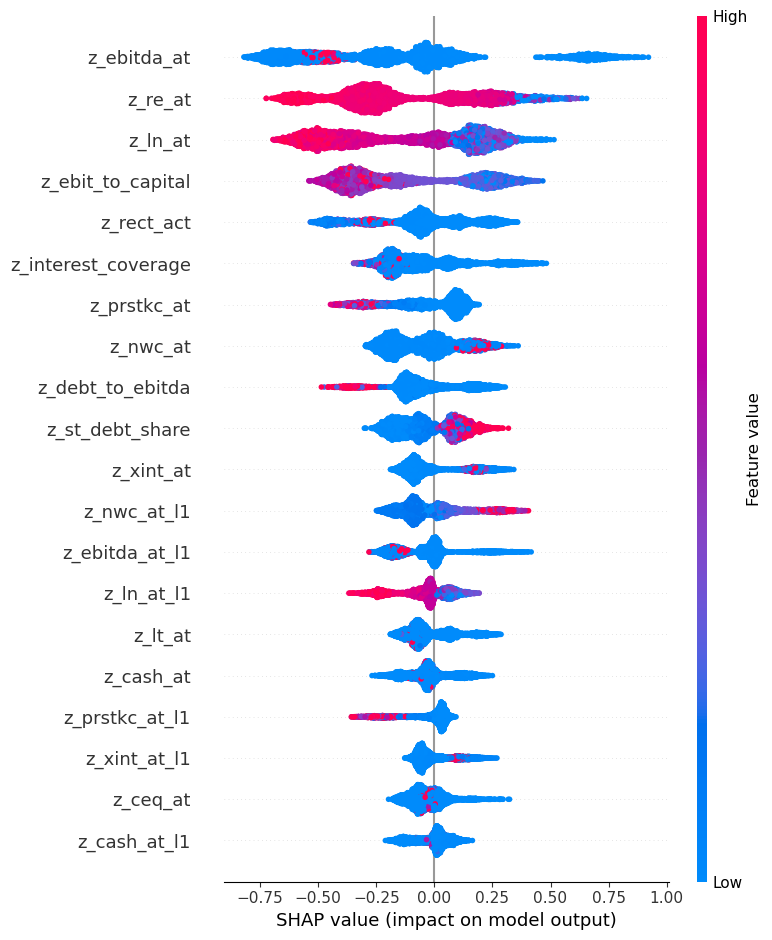

In [43]:
# -----------------------------
# 1) Built-in importance tables
# -----------------------------
# Notes:
# - "gain" / "total_gain": average / total loss reduction attributed to splits on feature.
# - "weight": split count (aka frequency).
# - "cover" / "total_cover": average / total coverage (approx. #samples affected by splits).
importance_types = ["gain", "total_gain", "weight", "cover", "total_cover"]
booster = xgb_model if hasattr(xgb_model, "get_score") else xgb_model.get_booster()

imp_tbl = pd.DataFrame({"feature": TRAIN_FEATURE_LIST})

for it in importance_types:
    score = booster.get_score(importance_type=it)
    df = pd.DataFrame({"feature": list(score.keys()), it: list(score.values())})
    imp_tbl = imp_tbl.merge(df, on="feature", how="left")

imp_tbl[importance_types] = imp_tbl[importance_types].fillna(0.0)

# Shares + concentration diagnostics (how “spiky” is importance?)
for it in importance_types:
    s = float(imp_tbl[it].sum())
    imp_tbl[it + "_share"] = imp_tbl[it] / s if s > 0 else 0.0

imp_tbl = imp_tbl.sort_values("total_gain", ascending=False)

display(imp_tbl[["feature"] + importance_types + [t + "_share" for t in importance_types]].head(30))

# Concentration: share captured by top-k features
for k in [5, 10, 20]:
    topk_share = float(imp_tbl["total_gain_share"].head(k).sum())
    print(f"Top-{k} share of total_gain: {topk_share:.3f}")

# -----------------------------
# 2) Quick plots (top 20)
# -----------------------------
def plot_top20(df: pd.DataFrame, col: str, title: str) -> None:
    top = df.sort_values(col, ascending=True).tail(20)
    plt.figure(figsize=(8, 6))
    plt.barh(top["feature"], top[col])
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_top20(imp_tbl, "total_gain",  "XGBoost feature importance: total_gain (top 20)")
plot_top20(imp_tbl, "gain",        "XGBoost feature importance: gain (top 20)")
plot_top20(imp_tbl, "weight",      "XGBoost feature importance: weight / split count (top 20)")
plot_top20(imp_tbl, "total_cover", "XGBoost feature importance: total_cover (top 20)")

# Optional: save the table
# imp_tbl.to_csv(Path(CONFIG["FIG_DIR"]) / "feature_importance_xgb_builtin.csv", index=False)


# -------------------------------------------------------
# 3) Permutation importance on *population* validation set
#    (model-agnostic; tests marginal predictive contribution)
# -------------------------------------------------------
# Choose the dataset whose distribution your PDs correspond to.
# Typically use your unweighted population calibration set: X_va_cal, y_va_cal
from sklearn.metrics import brier_score_loss, log_loss

def _predict_prob(booster, X_df: pd.DataFrame) -> np.ndarray:
    d = xgb.DMatrix(X_df, feature_names=TRAIN_FEATURE_LIST)
    return booster.predict(d)

def permutation_importance_xgb(
    booster,
    X_df: pd.DataFrame,
    y,
    features: list[str],
    metric: str = "brier",
    n_repeats: int = 5,
    sample_n: int = 20000,
    seed: int = SEED,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    if sample_n is not None and X_df.shape[0] > sample_n:
        idx = rng.choice(X_df.index.values, size=sample_n, replace=False)
        X_use = X_df.loc[idx].copy()
        y_use = y.loc[idx] if hasattr(y, "loc") else y[idx]
    else:
        X_use = X_df.copy()
        y_use = y

    p0 = _predict_prob(booster, X_use)
    p0c = np.clip(p0, 1e-12, 1 - 1e-12)

    if metric == "brier":
        base = float(brier_score_loss(y_use, p0))
    elif metric == "logloss":
        base = float(log_loss(y_use, p0c))
    else:
        raise ValueError("metric must be 'brier' or 'logloss'")

    rows = []
    for f in features:
        deltas = []
        x_orig = X_use[f].to_numpy().copy()

        for _ in range(n_repeats):
            x_perm = x_orig.copy()
            rng.shuffle(x_perm)
            X_use[f] = x_perm

            p1 = _predict_prob(booster, X_use)
            p1c = np.clip(p1, 1e-12, 1 - 1e-12)

            if metric == "brier":
                m1 = float(brier_score_loss(y_use, p1))
            else:
                m1 = float(log_loss(y_use, p1c))

            deltas.append(m1 - base)

        # restore
        X_use[f] = x_orig
        rows.append(
            {"feature": f, "delta_mean": float(np.mean(deltas)), "delta_sd": float(np.std(deltas, ddof=1))}
        )

    out = pd.DataFrame(rows).sort_values("delta_mean", ascending=False)
    out["metric"] = metric
    out["base"] = base
    return out

# Run permutation importance on top-K by total_gain (reduce compute)
TOP_K = 25
top_features = imp_tbl["feature"].head(TOP_K).tolist()

perm_brier = permutation_importance_xgb(
    booster=booster,
    X_df=X_va_cal,          # <-- population calibration set
    y=y_va_cal.astype(int),
    features=top_features,
    metric="brier",
    n_repeats=5,
    sample_n=20000,
)
display(perm_brier.head(25))

plot_top20(perm_brier, "delta_mean", "Permutation importance (ΔBrier; higher = more important)")

# Optional: save
# perm_brier.to_csv(Path(CONFIG["FIG_DIR"]) / "feature_importance_perm_brier.csv", index=False)


# -----------------------------
# 4) SHAP (summary + bar)
# -----------------------------
# Caveat: can be expensive; keep sample small-ish.
try:
    import shap
    shap.initjs()

    sample_n = min(20000, X_tr.shape[0])
    X_sample = X_tr.sample(sample_n, random_state=SEED)

    explainer = shap.TreeExplainer(booster)
    shap_values = explainer.shap_values(X_sample)

    # (a) Standard summary plot
    plt.figure()
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.tight_layout()
    plt.savefig(Path(CONFIG["FIG_DIR"]) / "shap_summary_tree.png", dpi=160)
    plt.show()

    # (b) Bar plot: mean(|SHAP|) ranking
    plt.figure()
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig(Path(CONFIG["FIG_DIR"]) / "shap_bar_tree.png", dpi=160)
    plt.show()

except Exception as e:
    print("SHAP skipped:", e)

#### 7A.5 Walk-forward validation (expanding window)

This section refits preprocessing inside each fold using the raw modeling snapshot (before the global train-fit transforms). That keeps the walk-forward results free of preprocessing leakage.



In [44]:

# =============================================================================
# Walk-forward (expanding window) validation — Logit and XGBoost (leakage-safe)
# =============================================================================
# This implementation refits preprocessing (median fill, winsor bounds, scaler) within each fold.
# That is required for honest temporal validation.

trainpool_df = df_model_raw.loc[df_model_raw["split"].isin(["train", "val"]), :].copy()
years = sorted(trainpool_df["label_year"].dropna().unique().tolist())
years = [int(y) for y in years]


# --- safe metrics helpers ---
def _safe_auc(y, p):
    y = np.asarray(y, int)
    p = np.asarray(p, float)
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, p)


def _safe_pr(y, p):
    y = np.asarray(y, int)
    p = np.asarray(p, float)
    if len(np.unique(y)) < 2:
        return np.nan
    return average_precision_score(y, p)


N_SPLITS = 4
if len(years) < (N_SPLITS + 2):
    print("Not enough years for walk-forward validation; skipping.")
    wf_tbl = pd.DataFrame()
else:
    split_idx = np.linspace(2, len(years) - 1, N_SPLITS, dtype=int)



    # Ensure walk-forward uses the same best XGBoost parameters from Section 7B.1
    wf_best_params = CONFIG.get("XGB_BEST_PARAMS")
    if wf_best_params is None:
        wf_best_params = best_params.copy() if "best_params" in globals() and best_params is not None else None
    if wf_best_params is None:
        raise ValueError("Walk-forward requires best XGB params from Section 7B.1; run that section first.")
    if "best_params" in globals() and best_params is not None and wf_best_params != best_params:
        print("Warning: CONFIG['XGB_BEST_PARAMS'] differs from best_params; using CONFIG version for walk-forward.")

    def prep_fold(df_tr, df_va):
        # continuous: median fill (train), winsor clip (train), scaler (train)
        cont = [c for c in continuous_feats_raw if c in df_tr.columns]
        Xtr = df_tr[cont].apply(pd.to_numeric, errors="coerce")
        Xva = df_va[cont].apply(pd.to_numeric, errors="coerce")

        med = Xtr.median()
        Xtr = Xtr.fillna(med)
        Xva = Xva.fillna(med)

        bounds = {c: winsorize_train_bounds(Xtr[c], CONFIG["WINSOR_LO_Q"], CONFIG["WINSOR_HI_Q"]) for c in cont}
        for c, (lo, hi) in bounds.items():
            Xtr[c] = apply_bounds(Xtr[c], lo, hi)
            Xva[c] = apply_bounds(Xva[c], lo, hi)

        scaler = StandardScaler()
        Ztr = pd.DataFrame(scaler.fit_transform(Xtr), columns=[f"z_{c}" for c in cont], index=df_tr.index)
        Zva = pd.DataFrame(scaler.transform(Xva), columns=[f"z_{c}" for c in cont], index=df_va.index)

        # events: keep as-is; fill missing with 0 (absence of event)
        ev = [c for c in event_feats if c in df_tr.columns]
        if ev:
            Etr = df_tr[ev].fillna(0.0)
            Eva = df_va[ev].fillna(0.0)
            Ztr = pd.concat([Ztr, Etr], axis=1)
            Zva = pd.concat([Zva, Eva], axis=1)

        return Ztr, Zva


    rows = []
    for k in split_idx:
        train_years = years[:k]
        val_year = years[k]

        df_tr = trainpool_df[trainpool_df["label_year"].isin(train_years)].copy()
        df_va = trainpool_df[trainpool_df["label_year"].isin([val_year])].copy()

        # drop missing labels for the fold
        df_tr = df_tr[df_tr[TARGET_NAME].notna()].copy()
        df_va = df_va[df_va[TARGET_NAME].notna()].copy()

        X_tr, X_va = prep_fold(df_tr, df_va)
        y_tr = df_tr[TARGET_NAME].astype(int).values
        y_va = df_va[TARGET_NAME].astype(int).values

        # ---- Logit (match 7A.1/7A.2 best setup) ----
        C_use = float(globals().get("best_C", 1.0))
        log_mdl = LogisticRegression(
            penalty="l2",
            C=C_use,
            solver="lbfgs",
            max_iter=3000,
            random_state=SEED,
        )
        log_mdl.fit(X_tr, y_tr)
        p_va_log = log_mdl.predict_proba(X_va)[:, 1]

        rows.append({
            "model": "logit",
            "train_years_min": min(train_years),
            "train_years_max": max(train_years),
            "val_year": val_year,
            "n_train": int(len(y_tr)),
            "n_val": int(len(y_va)),
            "roc_auc": _safe_auc(y_va, p_va_log),
            "pr_auc": _safe_pr(y_va, p_va_log),
            "brier": float(brier_score_loss(y_va, p_va_log)),
        })

        # ---- XGBoost (policy-aligned, per-fold fit) ----
        # Ensure y are pandas Series (so .values works exactly like your main cell)
        y_tr = df_tr[TARGET_NAME].astype(int)
        y_va = df_va[TARGET_NAME].astype(int)

        # If a fold has only one class, XGBoost AUC/PR are undefined and training can be unstable.
        if (y_tr.nunique() < 2) or (y_va.nunique() < 2):
            rows.append({
                "model": "tree",
                "train_years_min": min(train_years),
                "train_years_max": max(train_years),
                "val_year": val_year,
                "n_train": int(len(y_tr)),
                "n_val": int(len(y_va)),
                "roc_auc": np.nan,
                "pr_auc": np.nan,
                "brier": np.nan,
                "best_iteration": np.nan,
                "note": "Skipped: single-class fold"
            })
        else:
            # --- cost weights only (no scale_pos_weight) ---
            n_pos = int(y_tr.sum())
            n_neg = int((y_tr == 0).sum())
            imbalance = (n_neg / max(n_pos, 1))

            w_pos = CONFIG["COST_FN"]
            w_neg = CONFIG["COST_FP"]

            w_tr = np.where(y_tr.values == 1, w_pos, w_neg).astype(float)
            w_va = np.where(y_va.values == 1, w_pos, w_neg).astype(float)

            # --- DMatrix pattern with early-stopping split ---
            X_va_es, X_va_cal, y_va_es, y_va_cal = train_test_split(
                X_va, y_va, test_size=0.5, random_state=SEED, stratify=y_va
            )
            w_va_es = np.where(y_va_es.values == 1, w_pos, w_neg).astype(float)
            w_va_cal = np.where(y_va_cal.values == 1, w_pos, w_neg).astype(float)

            dtrain = xgb.DMatrix(X_tr, label=y_tr, weight=w_tr, feature_names=X_tr.columns.tolist())
            dval_es = xgb.DMatrix(X_va_es, label=y_va_es, weight=w_va_es, feature_names=X_tr.columns.tolist())
            dval_cal = xgb.DMatrix(X_va_cal, label=y_va_cal, weight=w_va_cal, feature_names=X_tr.columns.tolist())

            def _capacity_policy_cost(y_true, preds):
                y_true = np.asarray(y_true, dtype=int)
                preds = np.asarray(preds, dtype=float)
                n = len(preds)
                k = int(math.ceil(CONFIG["CAPACITY_PCT"] * n))
                if k <= 0 or n == 0:
                    return 0.0
                top_idx = np.argsort(preds)[-k:]
                y_pred = np.zeros_like(y_true)
                y_pred[top_idx] = 1
                fp = np.sum((y_pred == 1) & (y_true == 0))
                fn = np.sum((y_pred == 0) & (y_true == 1))
                cost = CONFIG["COST_FN"] * fn + CONFIG["COST_FP"] * fp
                return float(cost) / float(n)

            xgb_params = wf_best_params.copy()
            xgb_params["scale_pos_weight"] = 1.0
            xgb_params["eval_metric"] = "logloss"

            evals = [(dtrain, "train"), (dval_es, "val_es")]

            xgb_model = xgb.train(
                params=xgb_params,
                dtrain=dtrain,
                num_boost_round=CONFIG["XGB_NUM_BOOST_ROUND"],
                evals=evals,
                early_stopping_rounds=CONFIG["XGB_EARLY_STOPPING"],
                maximize=False,
                verbose_eval=False,
            )

            # Raw probabilities (uncalibrated) — evaluate on val_cal split
            best_iter = int(getattr(xgb_model, "best_iteration", 0)) + 1
            p_val_raw = xgb_model.predict(dval_cal, iteration_range=(0, best_iter))

            rows.append({
                "model": "tree",
                "train_years_min": min(train_years),
                "train_years_max": max(train_years),
                "val_year": val_year,
                "n_train": int(len(y_tr)),
                "n_val": int(len(y_va_cal)),
                "roc_auc": _safe_auc(y_va_cal.values, p_val_raw),
                "pr_auc": _safe_pr(y_va_cal.values, p_val_raw),
                "brier": float(brier_score_loss(y_va_cal.values.astype(int), p_val_raw)),
                "best_iteration": int(getattr(xgb_model, "best_iteration", np.nan)),
            })

    wf_tbl = pd.DataFrame(rows)
    display(wf_tbl)




,model,train_years_min,train_years_max,val_year,n_train,n_val,roc_auc,pr_auc,brier,best_iteration
0,logit,2015,2016,2017,9106,4360,0.755141,0.217890,0.060755,NaN
1,tree,2015,2016,2017,9106,2180,0.889010,0.486510,0.057290,654.0
2,logit,2015,2017,2018,13466,4307,0.752656,0.259877,0.061917,NaN
3,tree,2015,2017,2018,13466,2154,0.883983,0.437876,0.060456,341.0
4,logit,2015,2019,2020,21979,4167,0.710254,0.289168,0.086925,NaN
5,tree,2015,2019,2020,21979,2084,0.801136,0.423439,0.077149,48.0
6,logit,2015,2021,2022,30211,4102,0.723950,0.303110,0.088151,NaN
7,tree,2015,2021,2022,30211,2051,0.881809,0.561006,0.070745,330.0


## 8. Model Evaluation & Diagnostic Monitoring

All evaluation in this section treats the **test split as untouchable**: no tuning based on test results.

**Clean Evaluation Protocol Note:**
- For **Logit**: The validation (`val`) performance reported below is an honest out-of-sample estimate because it uses a model trained on `train` only. The test performance uses a model trained on `train+val`.
- For **Tree (XGBoost)**: Early stopping uses `val_es`, while isotonic calibration uses the full validation year with monotone smoothing to reduce discretization. Reported `val` results reflect this split, but **test** remains the only fully unbiased estimate.
- **Unbiased Performance**: The **test split** results are the only strictly unbiased final performance metrics.

We report:
- ROC-AUC, PR-AUC, Brier score,
- calibration curve and calibration slope (reliability),
- persistence benchmark,
- collinearity and drift diagnostics.

### 8.1 Out-of-sample metrics (val and test) + persistence benchmark

In [45]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

def _assert_prob_vector(y_true: pd.Series, p: np.ndarray, require_prob: bool = True) -> np.ndarray:
    p = np.asarray(p, dtype=float)
    assert len(p) == len(y_true), "Prediction length does not match evaluation labels."
    assert np.isfinite(p).all(), "Non-finite values found in predictions."
    if require_prob:
        assert (p >= 0).all() and (p <= 1).all(), "Predictions must be valid probabilities in [0, 1]."
    return p

def eval_metrics_safe(y_true: pd.Series, p: np.ndarray) -> dict:
    p = _assert_prob_vector(y_true, p, require_prob=True)
    y = y_true.astype(int).values
    out = {
        "roc_auc": np.nan,
        "pr_auc": np.nan,
        "brier": brier_score_loss(y, p),
        "mean_p": float(np.mean(p)),
        "event_rate": float(np.mean(y)),
        "n": int(len(y)),
    }
    # Guard against single-class slices (can occur under transition objective + small test sets)
    if np.unique(y).size < 2:
        # ROC-AUC undefined; PR-AUC equals event rate for a constant predictor
        out["pr_auc"] = float(out["event_rate"])
        return out
    out["roc_auc"] = float(roc_auc_score(y, p))
    out["pr_auc"] = float(average_precision_score(y, p))
    return out

rows = []
for sp in ["val","test"]:
    mask = df_model["split"] == sp
    y_sp = df_model.loc[mask, TARGET_NAME]

    rows.append({"split": sp, "model":"logit", **eval_metrics_safe(y_sp, df_model.loc[mask, "pd_logit"].values)})
    rows.append({"split": sp, "model":"tree_calibrated", **eval_metrics_safe(y_sp, df_model.loc[mask, "pd_tree"].values)})

    obj = str(globals().get("OBJECTIVE", "state")).lower()
    if obj.startswith("trans"):
        # Under early-warning (transition) objective, PROXY_NAME==0 by construction. Use a simple "always-0" baseline.
        base = np.zeros(mask.sum(), dtype=float)
        rows.append({"split": sp, "model":"always_0", **eval_metrics_safe(y_sp, base)})
    else:
        # Surveillance objective baseline: predict next-year distress = current-year state (persistence)
        pers = pd.to_numeric(df_model.loc[mask, PROXY_NAME], errors="coerce").fillna(0).astype(int).values
        rows.append({"split": sp, "model":"persistence_state_t", **eval_metrics_safe(y_sp, pers)})

metrics_tbl = pd.DataFrame(rows).sort_values(["split","model"])
display(metrics_tbl)

,split,model,roc_auc,pr_auc,brier,mean_p,event_rate,n
5,test,always_0,0.500000,0.076914,0.076914,0.000000,0.076914,8035
3,test,logit,0.741941,0.247144,0.065230,0.083250,0.076914,8035
4,test,tree_calibrated,0.880524,0.413180,0.077288,0.181859,0.076914,8035
2,val,always_0,0.500000,0.107021,0.107021,0.000000,0.107021,4102
0,val,logit,0.723950,0.303110,0.088151,0.080925,0.107021,4102
1,val,tree_calibrated,0.874106,0.499599,0.082449,0.191151,0.107021,4102


### 8.1c Classification metrics (test, tree calibrated, capacity policy)


Model Evaluation Results (Tree, Test, Capacity Policy):
---------------------------------
Accuracy: 0.8381
Precision: 0.2875
Recall: 0.7476
F1-Score: 0.4153
ROC AUC Score: 0.8805

Confusion Matrix:
[[6272 1145]
 [ 156  462]]


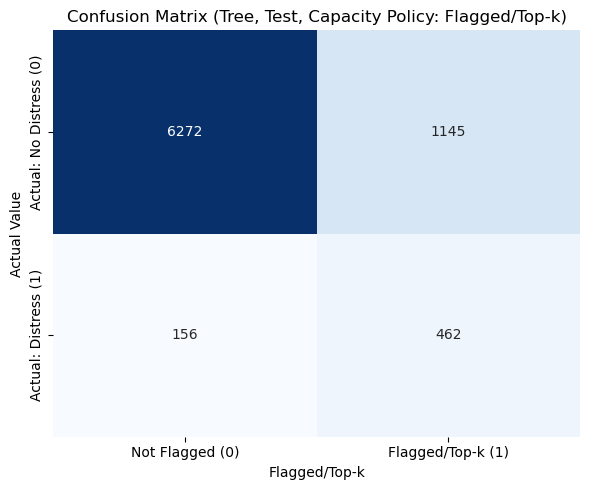


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      7417
           1       0.29      0.75      0.42       618

    accuracy                           0.84      8035
   macro avg       0.63      0.80      0.66      8035
weighted avg       0.92      0.84      0.87      8035



In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
import seaborn as sns
# Use calibrated tree PDs on the TEST split
mask_test = df_model["split"] == "test"
y_test = df_model.loc[mask_test, TARGET_NAME].astype(int).values
y_pred_proba = df_model.loc[mask_test, "pd_tree"].values

# Apply the same capacity policy used elsewhere (top-k by probability)
n_test = len(y_pred_proba)
k = int(math.ceil(CONFIG["CAPACITY_PCT"] * n_test))
order = np.argsort(y_pred_proba)
idx_top = order[-k:]

y_flag = np.zeros_like(y_test)
y_flag[idx_top] = 1

print("Model Evaluation Results (Tree, Test, Capacity Policy):")
print("---------------------------------")

accuracy = accuracy_score(y_test, y_flag)
precision = precision_score(y_test, y_flag, zero_division=0)
recall = recall_score(y_test, y_flag, zero_division=0)
f1 = f1_score(y_test, y_flag, zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

if np.unique(y_test).size > 1:
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC AUC Score: {roc_auc:.4f}")
else:
    print("ROC AUC Score: n/a (single-class test slice)")

conf_matrix = confusion_matrix(y_test, y_flag)
print("\nConfusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Not Flagged (0)", "Flagged/Top-k (1)"],
    yticklabels=["Actual: No Distress (0)", "Actual: Distress (1)"],
)
plt.title("Confusion Matrix (Tree, Test, Capacity Policy: Flagged/Top-k)")
plt.xlabel("Flagged/Top-k")
plt.ylabel("Actual Value")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_flag, zero_division=0))


### 8.1b Early-warning vs Surveillance decomposition (state-conditional evaluation)


In [47]:
# Objective-aware evaluation breakdown.
# - If OBJECTIVE == "transition": df_model already represents the *risk set* (distress_t==0), so we report overall metrics.
# - If OBJECTIVE == "state": we additionally break out performance on distress_t==0 (early-warning slice) vs distress_t==1 (surveillance slice).

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

def safe_eval_metrics(y_true: pd.Series, p: np.ndarray) -> dict:
    y = y_true.astype(int).values
    out = {
        "roc_auc": np.nan,
        "pr_auc": np.nan,
        "brier": brier_score_loss(y, p),
        "mean_p": float(np.mean(p)),
        "event_rate": float(np.mean(y)),
        "n": int(len(y)),
    }
    if np.unique(y).size < 2:
        out["pr_auc"] = float(out["event_rate"])
        return out
    out["roc_auc"] = float(roc_auc_score(y, p))
    out["pr_auc"] = float(average_precision_score(y, p))
    return out

def eval_models(df_seg: pd.DataFrame, split_name: str, segment_name: str) -> list:
    rows = []
    if df_seg.empty:
        return rows
    y = df_seg[TARGET_NAME]

    for col, mdl in [("pd_logit","logit"),
                     ("pd_tree","tree_calibrated")]:
        rows.append({
            "split": split_name,
            "segment": segment_name,
            "model": mdl,
            **safe_eval_metrics(y, df_seg[col].values),
        })

    # Baseline(s)
    obj = str(globals().get("OBJECTIVE", "state")).lower()
    if obj.startswith("trans"):
        base = np.zeros(df_seg.shape[0], dtype=float)
        rows.append({
            "split": split_name,
            "segment": segment_name,
            "model": "always_0",
            **safe_eval_metrics(y, base),
        })
    else:
        state = pd.to_numeric(df_seg[PROXY_NAME], errors="coerce").fillna(0).astype(int).values
        rows.append({
            "split": split_name,
            "segment": segment_name,
            "model": "state_only",
            **safe_eval_metrics(y, state),
        })
    return rows

obj = str(globals().get("OBJECTIVE", "state")).lower()

seg_rows = []
for sp in ["val", "test"]:
    df_sp = df_model.loc[df_model["split"]==sp, :].copy()

    if obj.startswith("trans"):
        seg_rows += eval_models(df_sp, sp, f"transition risk set ({PROXY_NAME}=0 by design)")
    else:
        # Early-warning vs surveillance slices (conditional on current state)
        dcur = pd.to_numeric(df_sp[PROXY_NAME], errors="coerce")
        df_sp = df_sp.loc[dcur.notna(), :].copy()
        df_sp["distress_t_int"] = dcur.loc[dcur.notna()].astype(int)

        seg_rows += eval_models(df_sp.loc[df_sp["distress_t_int"]==0, :], sp, f"early_warning ({PROXY_NAME}=0)")
        seg_rows += eval_models(df_sp.loc[df_sp["distress_t_int"]==1, :], sp, f"surveillance ({PROXY_NAME}=1)")

seg_metrics_tbl = pd.DataFrame(seg_rows)
if not seg_metrics_tbl.empty:
    seg_metrics_tbl = seg_metrics_tbl.sort_values(["split","segment","model"])
    display(seg_metrics_tbl)
else:
    print("No segment metrics computed (empty segments).")

,split,segment,model,roc_auc,pr_auc,brier,mean_p,event_rate,n
5,test,transition risk set (distress_v1_t=0 by design),always_0,0.500000,0.076914,0.076914,0.000000,0.076914,8035
3,test,transition risk set (distress_v1_t=0 by design),logit,0.741941,0.247144,0.065230,0.083250,0.076914,8035
4,test,transition risk set (distress_v1_t=0 by design),tree_calibrated,0.880524,0.413180,0.077288,0.181859,0.076914,8035
2,val,transition risk set (distress_v1_t=0 by design),always_0,0.500000,0.107021,0.107021,0.000000,0.107021,4102
0,val,transition risk set (distress_v1_t=0 by design),logit,0.723950,0.303110,0.088151,0.080925,0.107021,4102
1,val,transition risk set (distress_v1_t=0 by design),tree_calibrated,0.874106,0.499599,0.082449,0.191151,0.107021,4102


### 8.2 Calibration diagnostics (curve + calibration-in-the-large + slope)

val | logit: calibration intercept=0.814, slope=1.213


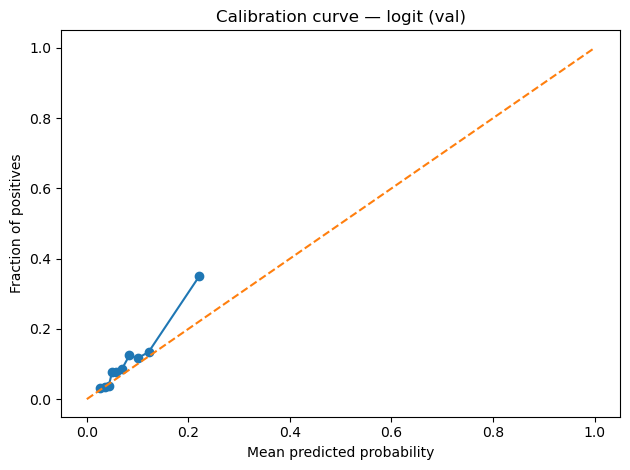

val | tree_calibrated: calibration intercept=-1.099, slope=0.876


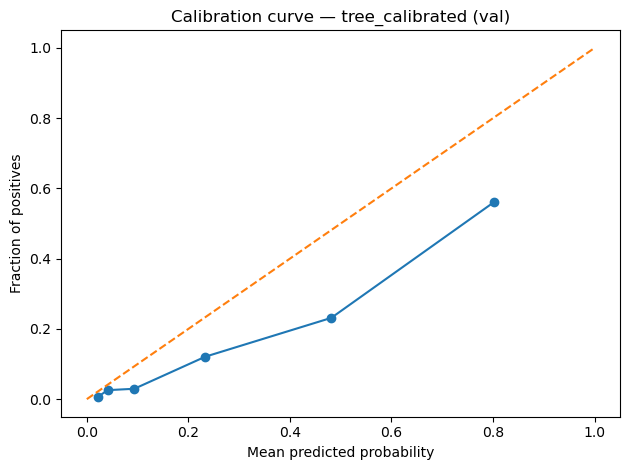

test | logit: calibration intercept=0.504, slope=1.273


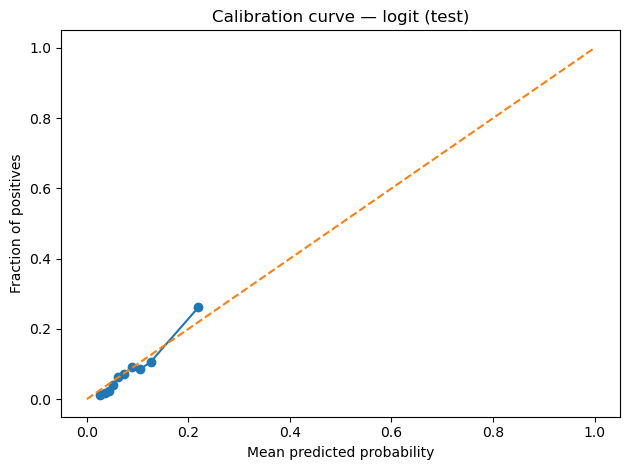

test | tree_calibrated: calibration intercept=-1.557, slope=0.763


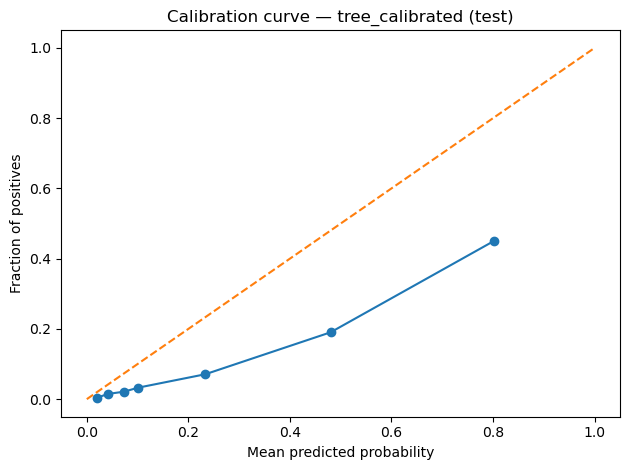


Calibration-in-the-large by year (TEST):

logit


,label_year,mean_pd,realized_rate,intercept_only_adj,n
0,2023,0.082449,0.071823,-0.149487,3982
1,2024,0.084038,0.081915,-0.027903,4053



tree_calibrated


,label_year,mean_pd,realized_rate,intercept_only_adj,n
0,2023,0.174544,0.071823,-1.005256,3982
1,2024,0.189045,0.081915,-0.960384,4053


In [48]:
def calibration_slope_intercept(y_true: np.ndarray, p: np.ndarray) -> tuple[float,float]:
    p = np.asarray(p, dtype=float)
    assert len(p) == len(y_true), "Prediction length does not match evaluation labels."
    assert np.isfinite(p).all(), "Non-finite values found in predictions."
    assert (p >= 0).all() and (p <= 1).all(), "Predictions must be valid probabilities in [0, 1]."
    z = logit(p)
    Xc = sm.add_constant(z, has_constant="add")
    mdl = sm.GLM(y_true, Xc, family=sm.families.Binomial())
    res = mdl.fit()
    intercept, slope = res.params[0], res.params[1]
    return float(intercept), float(slope)

def plot_calibration(y_true: np.ndarray, p: np.ndarray, title: str, fname: str):
    frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=10, strategy="quantile")
    plt.figure()
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(Path(CONFIG["FIG_DIR"]) / fname, dpi=160)
    plt.show()

for sp in ["val","test"]:
    mask = df_model["split"] == sp
    y_sp = df_model.loc[mask, TARGET_NAME].astype(int).values

    for model_name, pcol in [("logit","pd_logit"), ("tree_calibrated","pd_tree")]:
        p = df_model.loc[mask, pcol].values
        icpt, slope = calibration_slope_intercept(y_sp, p)
        print(f"{sp} | {model_name}: calibration intercept={icpt:.3f}, slope={slope:.3f}")
        plot_calibration(y_sp, p, f"Calibration curve — {model_name} ({sp})", f"cal_curve_{model_name}_{sp}.png")
# --- Calibration-in-the-large by year (TEST) ---

def calib_in_large_by_year(df_in: pd.DataFrame, pcol: str) -> pd.DataFrame:
    d = df_in.loc[df_in["split"]=="test", ["label_year", pcol, TARGET_NAME]].copy()
    rows = []
    for y, g in d.groupby("label_year"):
        mean_p = float(g[pcol].mean()) if len(g) else np.nan
        event_rate = float(g[TARGET_NAME].mean()) if len(g) else np.nan
        if np.isfinite(mean_p) and np.isfinite(event_rate):
            adj_intercept = float(logit(event_rate) - logit(mean_p))
        else:
            adj_intercept = np.nan
        rows.append({"label_year": int(y), "mean_pd": mean_p, "realized_rate": event_rate, "intercept_only_adj": adj_intercept, "n": int(len(g))})
    return pd.DataFrame(rows).sort_values("label_year")

print("\nCalibration-in-the-large by year (TEST):")
for model_name, pcol in [("logit","pd_logit"), ("tree_calibrated","pd_tree")]:
    print(f"\n{model_name}")
    display(calib_in_large_by_year(df_model, pcol))


### 8.3 Temporal stability (walk-forward fold metrics)

,model,train_years_min,train_years_max,val_year,n_train,n_val,roc_auc,pr_auc,brier,best_iteration
0,logit,2015,2016,2017,9106,4360,0.755141,0.217890,0.060755,NaN
1,tree,2015,2016,2017,9106,2180,0.889010,0.486510,0.057290,654.0
2,logit,2015,2017,2018,13466,4307,0.752656,0.259877,0.061917,NaN
3,tree,2015,2017,2018,13466,2154,0.883983,0.437876,0.060456,341.0
4,logit,2015,2019,2020,21979,4167,0.710254,0.289168,0.086925,NaN
5,tree,2015,2019,2020,21979,2084,0.801136,0.423439,0.077149,48.0
6,logit,2015,2021,2022,30211,4102,0.723950,0.303110,0.088151,NaN
7,tree,2015,2021,2022,30211,2051,0.881809,0.561006,0.070745,330.0


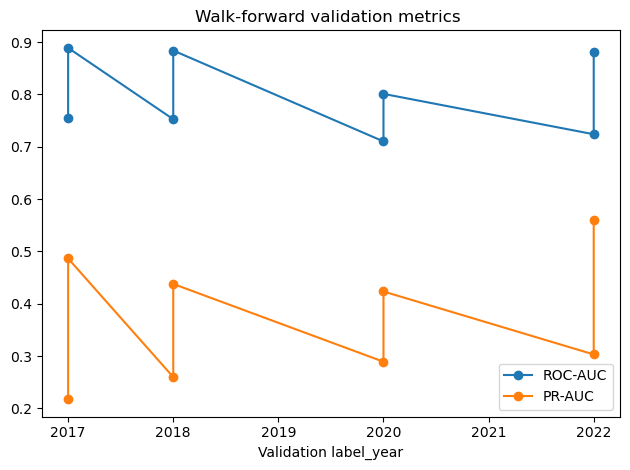

In [49]:
if 'wf_tbl' in globals() and len(wf_tbl) > 0:
    display(wf_tbl)
    plt.figure()
    plt.plot(wf_tbl["val_year"], wf_tbl["roc_auc"], marker="o", label="ROC-AUC")
    plt.plot(wf_tbl["val_year"], wf_tbl["pr_auc"], marker="o", label="PR-AUC")
    plt.title("Walk-forward validation metrics ")
    plt.xlabel("Validation label_year")
    plt.legend()
    plt.tight_layout()
    plt.savefig(Path(CONFIG["FIG_DIR"]) / "walkforward_metrics_logit.png", dpi=160)
    plt.show()

### 8.4 Collinearity checks (VIF + high-correlation pairs)

In [50]:
# VIF on continuous z-features (train only)
X_vif = splits["train"]["X"][[f"z_{c}" for c in continuous_feats_raw]].copy()
X_vif = sm.add_constant(X_vif, has_constant="add")

vif_rows = []
for i, col in enumerate(X_vif.columns):
    if col == "const":
        continue
    vif_rows.append({"feature": col, "VIF": float(variance_inflation_factor(X_vif.values, i))})

vif_tbl = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
display(vif_tbl)

# Correlation screen (continuous only)
corr = splits["train"]["X"][[f"z_{c}" for c in continuous_feats_raw]].corr()
high_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        v = corr.iloc[i,j]
        if abs(v) >= 0.85:
            high_pairs.append((corr.columns[i], corr.columns[j], float(v)))
high_pairs_tbl = pd.DataFrame(high_pairs, columns=["feat1","feat2","corr"]).sort_values("corr", key=np.abs, ascending=False)
display(high_pairs_tbl)

,feature,VIF
11,z_debt_at,27.785292
32,z_debt_at_l1,24.767366
10,z_dltt_at,19.063570
31,z_dltt_at_l1,17.101358
21,z_ln_at_l1,4.658087
0,z_ln_at,4.655186
35,z_xint_at_l1,3.858803
14,z_xint_at,3.672358
9,z_dlc_at,3.363666
30,z_dlc_at_l1,3.087535


,feat1,feat2,corr
0,z_dltt_at,z_debt_at,0.944769
1,z_dltt_at_l1,z_debt_at_l1,0.942843


### 8.5 Drift diagnostics (standardized mean difference: train vs test)

In [51]:
feat_cols = [f"z_{c}" for c in continuous_feats_raw] + event_feats
drift_rows = []
for c in feat_cols:
    smd = compute_smd(df_model.loc[df_model["split"]=="train", c], df_model.loc[df_model["split"]=="test", c])
    drift_rows.append({"feature": c, "SMD_train_vs_test": smd})
drift_tbl = pd.DataFrame(drift_rows).sort_values("SMD_train_vs_test", key=lambda s: s.abs(), ascending=False)
display(drift_tbl.head(25))

,feature,SMD_train_vs_test
33,z_st_debt_share_l1,-0.067977
22,z_cash_at_l1,-0.060888
31,z_dltt_at_l1,-0.058747
32,z_debt_at_l1,-0.052842
41,z_prstkc_at_l1,-0.047867
37,z_debt_to_ebitda_l1,-0.039245
0,z_ln_at,-0.038486
17,z_ebit_to_capital,0.037978
38,z_ebit_to_capital_l1,0.036468
30,z_dlc_at_l1,-0.035614


## 9.a Statistical uncertainty and model comparison on the test set (Stratified cluster bootstrap CIs + fold-based summaries)

This section adds (i) *stratified* cluster bootstrap by firm_id (stratified on distress presence) for 95% CIs on key metrics, and (ii) fold-based CI summaries from walk-forward validation for stability across time.


In [52]:

from itertools import combinations
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

# ============================================================
# Firm-clustered uncertainty quantification (panel-robust)
# ============================================================
# Rationale:
# - Firm-year observations are not i.i.d.; errors are correlated within firm over time.
# - Row-wise (i.i.d.) bootstrap and DeLong tests are therefore overconfident in panels.
# - We use a *cluster bootstrap by firm_id*: resample firms with replacement and keep
#   each sampled firm's full time-series block.
#
# Outputs:
# 1) Model-wise cluster-bootstrap percentile CIs for ROC-AUC, PR-AUC, and Brier score.
# 2) Pairwise *paired* cluster-bootstrap tests for ROC-AUC differences (with Holm/Bonferroni).


N_BOOT = 1000
ALPHA = 0.05
SEED_BOOT = 42

def _cluster_groups(df: pd.DataFrame, cluster_col: str):
    cl = df[cluster_col].astype(str).values
    uniq, inv = np.unique(cl, return_inverse=True)
    groups = [np.where(inv == k)[0] for k in range(len(uniq))]
    return groups

def _metric_safe(y: np.ndarray, p: np.ndarray, metric: str) -> float:
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    if metric == "roc_auc":
        if np.unique(y).size < 2:
            return np.nan
        return float(roc_auc_score(y, p))
    if metric == "pr_auc":
        # Average precision requires positives to be meaningful; return NaN if no positives.
        if y.sum() == 0 or y.sum() == len(y):
            return np.nan
        return float(average_precision_score(y, p))
    if metric == "brier":
        return float(brier_score_loss(y, p))
    raise ValueError(f"Unknown metric: {metric}")

def cluster_bootstrap_ci(
    df: pd.DataFrame,
    y_col: str,
    p_col: str,
    metric: str,
    cluster_col: str = "firm_id",
    n_boot: int = 1000,
    alpha: float = 0.05,
    seed: int = 42,
):
    y = df[y_col].astype(int).values
    p = df[p_col].astype(float).values

    point = _metric_safe(y, p, metric)
    groups = _cluster_groups(df, cluster_col)
    G = len(groups)
    if G == 0:
        return point, np.nan, np.nan, 0

    rng = np.random.default_rng(seed)
    vals = []

    for _ in range(n_boot):
        # sample clusters with replacement (same number of clusters)
        sampled = rng.integers(0, G, size=G)
        idx = np.concatenate([groups[g] for g in sampled])
        v = _metric_safe(y[idx], p[idx], metric)
        if v == v:  # not NaN
            vals.append(v)

    if len(vals) == 0:
        return point, np.nan, np.nan, 0

    lo = float(np.quantile(vals, alpha/2))
    hi = float(np.quantile(vals, 1 - alpha/2))
    return point, lo, hi, len(vals)

def cluster_bootstrap_diff_test(
    df: pd.DataFrame,
    y_col: str,
    p1_col: str,
    p2_col: str,
    metric: str = "roc_auc",
    cluster_col: str = "firm_id",
    n_boot: int = 1000,
    alpha: float = 0.05,
    seed: int = 42,
):
    y = df[y_col].astype(int).values
    p1 = df[p1_col].astype(float).values
    p2 = df[p2_col].astype(float).values

    point = _metric_safe(y, p1, metric) - _metric_safe(y, p2, metric)

    groups = _cluster_groups(df, cluster_col)
    G = len(groups)
    if G == 0:
        return point, np.nan, np.nan, np.nan, 0

    rng = np.random.default_rng(seed)
    diffs = []

    for _ in range(n_boot):
        sampled = rng.integers(0, G, size=G)
        idx = np.concatenate([groups[g] for g in sampled])
        m1 = _metric_safe(y[idx], p1[idx], metric)
        m2 = _metric_safe(y[idx], p2[idx], metric)
        if (m1 == m1) and (m2 == m2):
            diffs.append(m1 - m2)

    if len(diffs) == 0:
        return point, np.nan, np.nan, np.nan, 0

    diffs = np.asarray(diffs, dtype=float)
    lo = float(np.quantile(diffs, alpha/2))
    hi = float(np.quantile(diffs, 1 - alpha/2))

    # Two-sided p-value from the bootstrap sign distribution (paired)
    p_le0 = float(np.mean(diffs <= 0))
    p_ge0 = float(np.mean(diffs >= 0))
    pval = 2 * min(p_le0, p_ge0)
    pval = float(min(max(pval, 0.0), 1.0))

    return point, lo, hi, pval, len(diffs)

# -------------------------
# Multiple-testing adjustment helpers
# -------------------------
def p_adjust_bonferroni(pvals: np.ndarray) -> np.ndarray:
    p = np.asarray(pvals, dtype=float)
    return np.minimum(p * len(p), 1.0)

def p_adjust_holm(pvals: np.ndarray) -> np.ndarray:
    p = np.asarray(pvals, dtype=float)
    m = len(p)
    order = np.argsort(p)
    adj = np.empty(m, dtype=float)
    for i, idx in enumerate(order):
        adj[idx] = (m - i) * p[idx]
    # enforce monotonicity in sorted order
    adj_sorted = np.maximum.accumulate(adj[order])
    adj[order] = np.minimum(adj_sorted, 1.0)
    return adj

# -------------------------
# Stratified cluster bootstrap (by firm distress presence)
# -------------------------
def _firm_strata(df: pd.DataFrame, cluster_col: str, y_col: str):
    firm_flag = df.groupby(cluster_col)[y_col].max().astype(int)
    pos_firms = firm_flag[firm_flag == 1].index.astype(str).tolist()
    neg_firms = firm_flag[firm_flag == 0].index.astype(str).tolist()
    return pos_firms, neg_firms

def cluster_bootstrap_ci_stratified(
    df: pd.DataFrame,
    y_col: str,
    p_col: str,
    metric: str,
    cluster_col: str = "firm_id",
    n_boot: int = 1000,
    alpha: float = 0.05,
    seed: int = 42,
):
    df_local = df.reset_index(drop=True)
    y = df_local[y_col].astype(int).values
    p = df_local[p_col].astype(float).values

    point = _metric_safe(y, p, metric)
    pos_firms, neg_firms = _firm_strata(df_local, cluster_col, y_col)

    if len(pos_firms) + len(neg_firms) == 0:
        return point, np.nan, np.nan, 0

    cluster_vals = df_local[cluster_col].astype(str).values
    firm_to_idx = {
        f: np.flatnonzero(cluster_vals == f)
        for f in (pos_firms + neg_firms)
    }

    rng = np.random.default_rng(seed)
    vals = []

    for _ in range(n_boot):
        sampled_pos = rng.choice(pos_firms, size=len(pos_firms), replace=True) if pos_firms else []
        sampled_neg = rng.choice(neg_firms, size=len(neg_firms), replace=True) if neg_firms else []
        sampled_firms = list(sampled_pos) + list(sampled_neg)
        if not sampled_firms:
            continue
        idx = np.concatenate([firm_to_idx[f] for f in sampled_firms])
        v = _metric_safe(y[idx], p[idx], metric)
        if v == v:
            vals.append(v)

    if len(vals) == 0:
        return point, np.nan, np.nan, 0

    lo = float(np.quantile(vals, alpha / 2))
    hi = float(np.quantile(vals, 1 - alpha / 2))
    return point, lo, hi, len(vals)

# -------------------------
# Fold-based CI summaries (walk-forward validation table)
# -------------------------
def fold_ci_summary(wf_tbl: pd.DataFrame, metric: str, alpha: float = 0.05):
    if wf_tbl.empty:
        return pd.DataFrame()
    rows = []
    for model in wf_tbl["model"].unique():
        vals = wf_tbl.loc[wf_tbl["model"] == model, metric].dropna().astype(float).values
        n = len(vals)
        if n == 0:
            continue
        mean = float(np.mean(vals))
        std = float(np.std(vals, ddof=1)) if n > 1 else 0.0
        if n > 1:
            from scipy import stats
            tcrit = float(stats.t.ppf(1 - alpha / 2, df=n - 1))
            half = tcrit * std / np.sqrt(n)
        else:
            half = np.nan
        rows.append({
            "model": model,
            "metric": metric,
            "fold_mean": mean,
            "fold_ci_lo": mean - half if half == half else np.nan,
            "fold_ci_hi": mean + half if half == half else np.nan,
            "n_folds": n,
        })
    return pd.DataFrame(rows)

# -------------------------
# Run on test set (df_model + TARGET_NAME)
# -------------------------
mask_te = df_model["split"] == "test"
df_te = df_model.loc[mask_te, :].copy()

# Collect probability columns available (extend easily)
candidate_cols = [
    ("logit", "pd_logit"),
    ("tree_calibrated", "pd_tree"),
    ("logit_fe_year", "pd_logit_fe_year"),
    ("logit_fe_firm_year", "pd_logit_fe_firm_year"),
    ("logit_firth", "pd_logit_firth"),
]

models = {name: col for name, col in candidate_cols if col in df_te.columns}

if len(models) == 0:
    print("No model probability columns found in df_model (expected pd_logit / pd_tree).")
else:
    # --- Cluster bootstrap CIs for each model (and baseline if desired)
    rows = []
    for name, col in models.items():
        for metric in ["roc_auc", "pr_auc", "brier"]:
            pt, lo, hi, n_eff = cluster_bootstrap_ci(
                df_te, TARGET_NAME, col, metric=metric, cluster_col="firm_id", n_boot=N_BOOT, alpha=ALPHA, seed=SEED_BOOT
            )
            rows.append({
                "model": name,
                "metric": metric,
                "point": pt,
                "ci_lo": lo,
                "ci_hi": hi,
                "boot_repl_used": n_eff,
            })

    ci_tbl = pd.DataFrame(rows).sort_values(["metric", "model"])
    ci_tbl["ci_method"] = "cluster_bootstrap"
    display(ci_tbl)

    # --- Stratified (by firm distress presence) cluster-bootstrap CIs
    rows_strat = []
    for name, col in models.items():
        for metric in ["roc_auc", "pr_auc", "brier"]:
            pt, lo, hi, n_eff = cluster_bootstrap_ci_stratified(
                df_te, TARGET_NAME, col, metric=metric, cluster_col="firm_id", n_boot=N_BOOT, alpha=ALPHA, seed=SEED_BOOT
            )
            rows_strat.append({
                "model": name,
                "metric": metric,
                "point": pt,
                "ci_lo": lo,
                "ci_hi": hi,
                "boot_repl_used": n_eff,
                "ci_method": "cluster_bootstrap_stratified",
            })
    ci_tbl_strat = pd.DataFrame(rows_strat).sort_values(["metric", "model"])
    display(ci_tbl_strat)

    # --- Fold-based CI summaries from walk-forward validation (if available)
    if 'wf_tbl' in globals() and isinstance(wf_tbl, pd.DataFrame) and not wf_tbl.empty:
        for metric in ["roc_auc", "pr_auc", "brier"]:
            fold_tbl = fold_ci_summary(wf_tbl, metric=metric, alpha=ALPHA)
            if not fold_tbl.empty:
                display(fold_tbl.sort_values(["metric", "model"]))


    # --- Pairwise paired cluster-bootstrap tests (ROC-AUC diff)
    if len(models) < 2:
        print("Skipping pairwise model comparisons: need at least two model probability columns.")
    else:
        comp_rows = []
        for (n1, c1), (n2, c2) in combinations(models.items(), 2):
            diff_pt, diff_lo, diff_hi, pval, n_eff = cluster_bootstrap_diff_test(
                df_te, TARGET_NAME, c1, c2, metric="roc_auc", cluster_col="firm_id", n_boot=N_BOOT, alpha=ALPHA, seed=123
            )
            comp_rows.append({
                "model_1": n1,
                "model_2": n2,
                "roc_auc_diff_(1-2)": diff_pt,
                "diff_ci_lo": diff_lo,
                "diff_ci_hi": diff_hi,
                "p_value": pval,
                "boot_repl_used": n_eff,
            })

        comp_tbl = pd.DataFrame(comp_rows)
        if not comp_tbl.empty:
            comp_tbl["p_bonferroni"] = p_adjust_bonferroni(comp_tbl["p_value"].values)
            comp_tbl["p_holm"] = p_adjust_holm(comp_tbl["p_value"].values)
            display(comp_tbl.sort_values("p_value"))
        else:
            print("No pairwise comparisons computed.")


,model,metric,point,ci_lo,ci_hi,boot_repl_used,ci_method
2,logit,brier,0.065230,0.060770,0.069862,1000,cluster_bootstrap
11,logit_fe_firm_year,brier,0.065223,0.060763,0.069850,1000,cluster_bootstrap
8,logit_fe_year,brier,0.065230,0.060769,0.069857,1000,cluster_bootstrap
14,logit_firth,brier,0.065142,0.060743,0.069842,1000,cluster_bootstrap
5,tree_calibrated,brier,0.077288,0.073067,0.081799,1000,cluster_bootstrap
1,logit,pr_auc,0.247144,0.214139,0.283952,1000,cluster_bootstrap
10,logit_fe_firm_year,pr_auc,0.247236,0.214374,0.283954,1000,cluster_bootstrap
7,logit_fe_year,pr_auc,0.247082,0.214221,0.283787,1000,cluster_bootstrap
13,logit_firth,pr_auc,0.244895,0.212665,0.281085,1000,cluster_bootstrap
4,tree_calibrated,pr_auc,0.413180,0.375085,0.452620,1000,cluster_bootstrap


,model,metric,point,ci_lo,ci_hi,boot_repl_used,ci_method
2,logit,brier,0.065230,0.063910,0.066542,1000,cluster_bootstrap_stratified
11,logit_fe_firm_year,brier,0.065223,0.063905,0.066530,1000,cluster_bootstrap_stratified
8,logit_fe_year,brier,0.065230,0.063912,0.066536,1000,cluster_bootstrap_stratified
14,logit_firth,brier,0.065142,0.063568,0.066732,1000,cluster_bootstrap_stratified
5,tree_calibrated,brier,0.077288,0.073512,0.081097,1000,cluster_bootstrap_stratified
1,logit,pr_auc,0.247144,0.216021,0.283450,1000,cluster_bootstrap_stratified
10,logit_fe_firm_year,pr_auc,0.247236,0.216022,0.283613,1000,cluster_bootstrap_stratified
7,logit_fe_year,pr_auc,0.247082,0.215893,0.283485,1000,cluster_bootstrap_stratified
13,logit_firth,pr_auc,0.244895,0.214090,0.280843,1000,cluster_bootstrap_stratified
4,tree_calibrated,pr_auc,0.413180,0.383623,0.446833,1000,cluster_bootstrap_stratified


,model,metric,fold_mean,fold_ci_lo,fold_ci_hi,n_folds
0,logit,roc_auc,0.735500,0.700508,0.770493,4
1,tree,roc_auc,0.863985,0.797142,0.930828,4


,model,metric,fold_mean,fold_ci_lo,fold_ci_hi,n_folds
0,logit,pr_auc,0.267511,0.207572,0.327451,4
1,tree,pr_auc,0.477208,0.378489,0.575927,4


,model,metric,fold_mean,fold_ci_lo,fold_ci_hi,n_folds
0,logit,brier,0.074437,0.050340,0.098533,4
1,tree,brier,0.066410,0.051804,0.081015,4


,model_1,model_2,roc_auc_diff_(1-2),diff_ci_lo,diff_ci_hi,p_value,boot_repl_used,p_bonferroni,p_holm
0,logit,tree_calibrated,-0.138582,-0.155197,-0.121562,0.000,1000,0.00,0.00
6,tree_calibrated,logit_firth,0.138015,0.120733,0.155241,0.000,1000,0.00,0.00
5,tree_calibrated,logit_fe_firm_year,0.138425,0.121411,0.154965,0.000,1000,0.00,0.00
4,tree_calibrated,logit_fe_year,0.138625,0.121607,0.155126,0.000,1000,0.00,0.00
7,logit_fe_year,logit_fe_firm_year,-0.000200,-0.000239,-0.000160,0.000,1000,0.00,0.00
2,logit,logit_fe_firm_year,-0.000157,-0.000266,-0.000048,0.006,1000,0.06,0.03
1,logit,logit_fe_year,0.000043,-0.000060,0.000148,0.446,1000,1.00,1.00
8,logit_fe_year,logit_firth,-0.000610,-0.003488,0.002597,0.748,1000,1.00,1.00
3,logit,logit_firth,-0.000567,-0.003498,0.002706,0.766,1000,1.00,1.00
9,logit_fe_firm_year,logit_firth,-0.000410,-0.003285,0.002801,0.852,1000,1.00,1.00


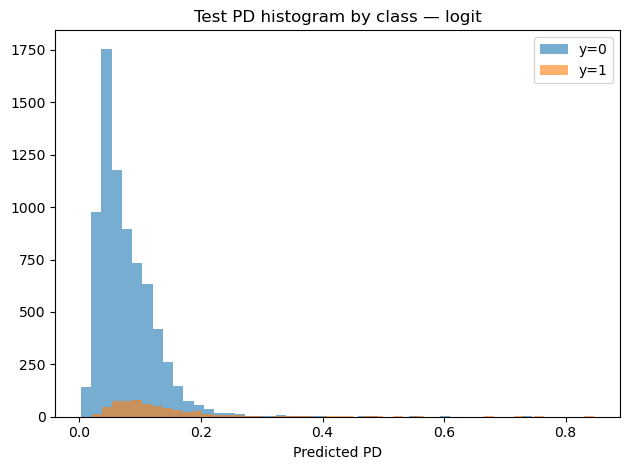

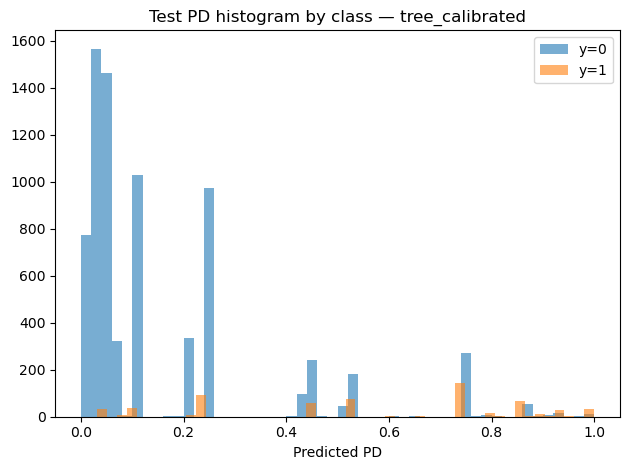

In [53]:
mask = df_model["split"]=="test"
y_true = df_model.loc[mask, TARGET_NAME].astype(int)

for model_name, pcol in [("logit","pd_logit"), ("tree_calibrated","pd_tree")]:
    p = df_model.loc[mask, pcol]
    plt.figure()
    plt.hist(p[y_true==0], bins=50, alpha=0.6, label="y=0")
    plt.hist(p[y_true==1], bins=50, alpha=0.6, label="y=1")
    plt.title(f"Test PD histogram by class — {model_name}")
    plt.xlabel("Predicted PD")
    plt.legend()
    plt.tight_layout()
    plt.savefig(Path(CONFIG["FIG_DIR"]) / f"pd_hist_{model_name}_test.png", dpi=160)
    plt.show()

## 9b. Operational Risk Management Layer (Events + PDs)
This section uses a **two-layer** design:

- **Model layer (prediction):** calibrated probability of next-year distress (**PD**) from accounting ratios and structural predictors.
- **Indicator layer (events):** discrete `evt_*` early-warning indicators **not used as predictors**. They serve governance, monitoring, and decision support.

This structure matches four operational functions commonly discussed in risk-management systems:

1. **Risk awareness:** documented prior knowledge of which indicators flag trouble (event dictionary + empirical lift).
2. **Monitoring and warning:** continuous tracking of event activation/persistence and PD levels over the panel.
3. **Communication:** translating signals into decision-maker-friendly views (risk tiers/deciles, transitions, reason codes).
4. **Response capability:** predefined action rules (screen / monitor / no action) based on PDs and events under explicit costs and capacity constraints.

### 9.1 Risk awareness — event dictionary and conditional risk (lift)

In [55]:
EVT_COLS = event_dict["event"].tolist()
print("Decision-support events:", EVT_COLS)

# Use post-imputation snapshot (pre-scaling) for event diagnostics.
# Dividend events still require adjacent-year observations, so some missingness may remain.
df_events = df_model_raw.copy() if "df_model_raw" in globals() else df_model.copy()

# Optional: enrich the event dictionary with a simple mechanism taxonomy (appendix-ready)
event_dict_enriched = event_dict.copy()
mech_map = {
    "evt_divcut": "Payout policy",
    "evt_divsusp": "Payout policy",
    "evt_divinit": "Payout policy",
    "evt_liq_squeeze": "Liquidity",
    "evt_quick_squeeze": "Liquidity",
    "evt_ebitdadrop": "Operating deterioration",
    "evt_cfdrop": "Operating deterioration",
}
event_dict_enriched["mechanism"] = event_dict_enriched["event"].map(mech_map).fillna("Other/unspecified")
display(event_dict_enriched)

def event_lift_table(df_in: pd.DataFrame, events: list[str], y_col: str) -> pd.DataFrame:
    # Event lift with explicit missingness handling.
    # - prevalence_obs: among observations where the event is observed (not NA)
    # - missing_rate: definitional missingness (insufficient inputs)
    # - cond_distress_rate: P(y=1 | evt=1, evt observed)

    base = df_in[y_col].astype(float).mean()
    rows = []
    for e in events:
        if e not in df_in.columns:
            continue

        s = pd.to_numeric(df_in[e], errors="coerce")  # may contain NA by construction
        miss = float(s.isna().mean())
        obs = s.notna()
        if obs.sum() == 0:
            continue

        s_obs = s[obs].astype(int)
        n_event = int((s_obs == 1).sum())
        if n_event == 0:
            continue

        rate = df_in.loc[obs & (s == 1), y_col].astype(float).mean()
        prev = float((s_obs == 1).mean())

        rows.append({
            "event": e,
            "mechanism": mech_map.get(e, "Other/unspecified"),
            "n_obs_event": int(obs.sum()),
            "n_event": n_event,
            "missing_rate": miss,
            "prevalence_obs": prev,
            "cond_distress_rate": float(rate),
            "base_rate": float(base),
            "lift_vs_base": float(rate/base) if base > 0 else np.nan,
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(["lift_vs_base", "n_event"], ascending=[False, False])
    return out

for sp in ["train", "test"]:
    df_sp = df_events.loc[df_events["split"] == sp, :].copy()
    print(f"\nEvent lift (labels: {TARGET_NAME}) — {sp}")
    display(event_lift_table(df_sp, EVT_COLS, TARGET_NAME).head(25))

Decision-support events: ['evt_divcut', 'evt_divsusp', 'evt_divinit', 'evt_liq_squeeze', 'evt_quick_squeeze', 'evt_ebitdadrop', 'evt_cfdrop']


,event,definition,inputs,calibration,parameter,mechanism
0,evt_divcut,Dividend YoY % change <= training P10 threshol...,dvc,train-only,"{""DIV_CUT_THR_P10_BOUNDED"": -0.5}",Payout policy
1,evt_divsusp,Dividend >0 at t-1 and ~0 at t,dvc,none,,Payout policy
2,evt_divinit,Dividend ~0 at t-1 and >0 at t,dvc,none,,Payout policy
3,evt_liq_squeeze,Current ratio < 1.0,"act,lct",fixed threshold,,Liquidity
4,evt_quick_squeeze,Quick ratio < 0.8,"act,lct,invt (or che+rect)",fixed threshold,,Liquidity
5,evt_ebitdadrop,EBITDA <=0 OR EBITDA/EBITDA_{t-1}<0.5 (require...,oibdp,fixed threshold,,Operating deterioration
6,evt_cfdrop,CFO <=0 OR CFO/CFO_{t-1}<0.5 (requires CFO_{t-...,oancf,fixed threshold,,Operating deterioration



Event lift (labels: target_transition_v1) — train


,event,mechanism,n_obs_event,n_event,missing_rate,prevalence_obs,cond_distress_rate,base_rate,lift_vs_base
5,evt_ebitdadrop,Operating deterioration,24475,3470,0.189865,0.141777,0.120461,0.079971,1.506312
6,evt_cfdrop,Operating deterioration,24475,3918,0.189865,0.160082,0.101072,0.079971,1.263860
3,evt_liq_squeeze,Liquidity,30211,7694,0.000000,0.254675,0.100728,0.079971,1.259557
4,evt_quick_squeeze,Liquidity,30211,8618,0.000000,0.285260,0.093641,0.079971,1.170942
1,evt_divsusp,Payout policy,24475,567,0.189865,0.023166,0.089947,0.079971,1.124748
2,evt_divinit,Payout policy,24475,651,0.189865,0.026599,0.072197,0.079971,0.902786
0,evt_divcut,Payout policy,12799,2090,0.576346,0.163294,0.046411,0.079971,0.580355



Event lift (labels: target_transition_v1) — test


,event,mechanism,n_obs_event,n_event,missing_rate,prevalence_obs,cond_distress_rate,base_rate,lift_vs_base
5,evt_ebitdadrop,Operating deterioration,7688,1077,0.043186,0.140088,0.119777,0.076914,1.557297
1,evt_divsusp,Payout policy,7688,159,0.043186,0.020682,0.106918,0.076914,1.390110
6,evt_cfdrop,Operating deterioration,7688,1390,0.043186,0.180801,0.100719,0.076914,1.309515
3,evt_liq_squeeze,Liquidity,8035,2051,0.000000,0.255258,0.097513,0.076914,1.267832
4,evt_quick_squeeze,Liquidity,8035,2317,0.000000,0.288363,0.088476,0.076914,1.150337
0,evt_divcut,Payout policy,3945,524,0.509023,0.132826,0.053435,0.076914,0.694743
2,evt_divinit,Payout policy,7688,267,0.043186,0.034729,0.044944,0.076914,0.584342


### 9.2 Monitoring and warning — event dynamics, persistence, and PD×event risk grids

Monitoring should reflect (i) **activation** (0→1), (ii) **persistence** (1→1), and (iii) how event regimes interact with PDs.
We treat events as *operational indicators* (not predictors) and monitor them jointly with calibrated PDs.


In [56]:
# --- 9.2A Event activation and persistence (adjacency-safe) ---
def transition_stats(df_in: pd.DataFrame, event: str) -> dict:
    # Robust transition stats that enforce year adjacency and handle NaNs.
    s = pd.to_numeric(df_in[event], errors="coerce")
    s_l1 = lag(df_in, event, 1)

    valid = s.notna() & s_l1.notna()
    if valid.sum() == 0:
        return {"event": event, "activation_01_rate": np.nan, "persistence_11_rate": np.nan, "n_transitions": 0}

    s0 = s_l1[valid].astype(int)
    s1 = s[valid].astype(int)

    act_01 = ((s0 == 0) & (s1 == 1)).mean()
    pers_11 = ((s0 == 1) & (s1 == 1)).mean()
    return {
        "event": event,
        "activation_01_rate": float(act_01),
        "persistence_11_rate": float(pers_11),
        "n_transitions": int(valid.sum()),
    }

rows = [transition_stats(df_model, e) for e in EVT_COLS]
trans_tbl = pd.DataFrame(rows)
if not trans_tbl.empty:
    trans_tbl = trans_tbl.sort_values("activation_01_rate", ascending=False)
display(trans_tbl)

# --- 9.2B Monitoring summary by fiscal year (panel-level tracking) ---
def monitoring_by_year(df_in: pd.DataFrame, p_col: str, y_col: str, evt_cols: list[str]) -> pd.DataFrame:
    d = df_in[["fyear", "split", p_col, y_col] + evt_cols].copy()

    # Event aggregation: triggered count; missingness summarized separately.
    evt_mat = d[evt_cols].apply(pd.to_numeric, errors="coerce")
    d["evt_missing_rate_mean"] = evt_mat.isna().mean(axis=1)
    d["evt_count"] = (evt_mat.fillna(0) == 1).sum(axis=1)
    d["evt_any"] = (d["evt_count"] > 0).astype(int)

    out = (d.groupby(["split", "fyear"])
             .agg(
                 n=("fyear","size"),
                 mean_pd=(p_col,"mean"),
                 realized_rate=(y_col,"mean"),
                 evt_any_rate=("evt_any","mean"),
                 mean_evt_count=("evt_count","mean"),
                 mean_evt_missing=("evt_missing_rate_mean","mean"),
             )
             .reset_index()
             .sort_values(["split","fyear"]))
    return out

print("\nMonitoring by year — calibrated tree PD (pd_tree)")
display(monitoring_by_year(df_model, "pd_tree", TARGET_NAME, EVT_COLS).head(40))

# --- 9.2C PD × Event risk grid (operational triangulation) ---
def pd_event_grid(df_in: pd.DataFrame, p_col: str, y_col: str, evt_cols: list[str], n_bins: int = 10) -> pd.DataFrame:
    d = df_in[[p_col, y_col] + evt_cols].dropna(subset=[p_col, y_col]).copy()
    evt_mat = d[evt_cols].apply(pd.to_numeric, errors="coerce")
    d["evt_count"] = (evt_mat.fillna(0) == 1).sum(axis=1)

    d["evt_bucket"] = pd.cut(d["evt_count"], bins=[-0.1, 0.5, 1.5, 10**6], labels=["0", "1", "2+"])
    d["pd_decile"] = pd.qcut(d[p_col], q=n_bins, labels=False, duplicates="drop") + 1

    g = (d.groupby(["pd_decile","evt_bucket"])
           .agg(
               n=("pd_decile","size"),
               mean_pd=(p_col,"mean"),
               realized_rate=(y_col,"mean"),
           )
           .reset_index())
    return g.sort_values(["pd_decile","evt_bucket"])

print("\nTest split PD × Events grid — calibrated tree")
display(pd_event_grid(df_model.loc[df_model["split"]=="test", :], "pd_tree", TARGET_NAME, EVT_COLS, n_bins=10))

,event,activation_01_rate,persistence_11_rate,n_transitions
6,evt_cfdrop,0.163593,0.018620,27874
5,evt_ebitdadrop,0.129188,0.013382,27874
4,evt_quick_squeeze,0.125805,0.155004,33083
0,evt_divcut,0.118625,0.019570,14921
3,evt_liq_squeeze,0.114591,0.130611,33083
2,evt_divinit,0.028449,0.000000,27874
1,evt_divsusp,0.022099,0.000000,27874



Monitoring by year — calibrated tree PD (pd_tree)


,split,fyear,n,mean_pd,realized_rate,evt_any_rate,mean_evt_count,mean_evt_missing
0,test,2022,3982,0.174544,0.071823,0.553742,0.983928,0.104685
1,test,2023,4053,0.189045,0.081915,0.536886,0.954108,0.090233
2,train,2014,4620,0.183155,0.071212,0.306277,0.521212,0.714286
3,train,2015,4486,0.187801,0.072893,0.549041,0.973919,0.095567
4,train,2016,4360,0.190563,0.069266,0.537385,0.955275,0.092071
5,train,2017,4307,0.187986,0.073137,0.535872,0.937544,0.096653
6,train,2018,4206,0.182202,0.077746,0.519020,0.900618,0.095951
7,train,2019,4167,0.187688,0.103912,0.551956,0.984881,0.100621
8,train,2020,4065,0.212305,0.094219,0.549077,1.017466,0.097382
9,val,2021,4102,0.191151,0.107021,0.547538,0.972452,0.107369



Test split PD × Events grid — calibrated tree


,pd_decile,evt_bucket,n,mean_pd,realized_rate
0,1,0,1253,0.019234,0.001596
1,1,1,515,0.023481,0.007767
2,1,2+,579,0.021381,0.006908
3,2,0,643,0.041184,0.012442
4,2,1,364,0.041192,0.008242
5,2,2+,480,0.041195,0.022917
6,3,0,138,0.073017,0.014493
7,3,1,84,0.072824,0.02381
8,3,2+,108,0.073171,0.027778
9,4,0,439,0.101260,0.022779


### 9.3 Communication — risk tiers, transitions, and reason codes

Communication should translate model outputs and indicator triggers into decision-maker-friendly artifacts:

- **Risk tiers/deciles:** expected vs realized risk by PD bucket.
- **Transitions:** PD movements and event activations/persistence.
- **Reason codes:** simple, interpretable attributions for material PD jumps (based on newly triggered events).


In [57]:
def decile_table(df_in: pd.DataFrame, p_col: str, y_col: str) -> pd.DataFrame:
    d = df_in[[p_col, y_col]].dropna().copy()
    d["decile"] = pd.qcut(d[p_col], 10, labels=False, duplicates="drop") + 1
    out = d.groupby("decile").agg(
        n=("decile","size"),
        mean_pd=(p_col,"mean"),
        realized_rate=(y_col,"mean"),
    ).reset_index()
    out["calibration_gap"] = out["realized_rate"] - out["mean_pd"]
    return out

for model_name, pcol in [("logit","pd_logit"), ("tree_calibrated","pd_tree")]:
    print(f"\nTest deciles — {model_name}")
    dt = decile_table(df_model.loc[df_model["split"]=="test", :], pcol, TARGET_NAME)
    display(dt)
    # --- 9.3A Reason codes for large PD jumps (event-based) ---
# When PD decile increases materially year-over-year, summarize which events newly activated.

def reason_codes_for_pd_jumps(df_in: pd.DataFrame, p_col: str, evt_cols: list[str], min_decile_jump: int = 3, split: str = "test") -> pd.DataFrame:
    d = df_in.loc[df_in["split"] == split, ["firm_id","fyear", p_col] + evt_cols].copy()
    d = d.sort_values(["firm_id","fyear"])

    # PD deciles within the split (communication tiering)
    d["pd_decile"] = pd.qcut(d[p_col], 10, labels=False, duplicates="drop") + 1
    d["pd_decile_l1"] = lag(d, "pd_decile", 1)
    d["decile_jump"] = d["pd_decile"] - d["pd_decile_l1"]

    jump_mask = d["decile_jump"].notna() & (d["decile_jump"] >= min_decile_jump)
    if int(jump_mask.sum()) == 0:
        return pd.DataFrame(columns=["event","n_new_activation_in_jumps","share_of_jumps"])

    n_jumps = int(jump_mask.sum())
    rows = []
    for e in evt_cols:
        s = pd.to_numeric(d[e], errors="coerce")
        s_l1 = lag(d, e, 1)
        valid = jump_mask & s.notna() & s_l1.notna()
        if int(valid.sum()) == 0:
            continue
        new_act = int(((s_l1[valid].astype(int) == 0) & (s[valid].astype(int) == 1)).sum())
        if new_act > 0:
            rows.append({
                "event": e,
                "n_new_activation_in_jumps": new_act,
                "share_of_jumps": float(new_act / n_jumps),
            })

    out = pd.DataFrame(rows).sort_values("n_new_activation_in_jumps", ascending=False)
    return out

print("\nReason codes — events newly activating during large PD jumps (test split)")
display(reason_codes_for_pd_jumps(df_model, "pd_tree", EVT_COLS, min_decile_jump=3, split="test").head(20))



Test deciles — logit


,decile,n,mean_pd,realized_rate,calibration_gap
0,1,804,0.025271,0.011194,-0.014076
1,2,803,0.036795,0.016189,-0.020606
2,3,804,0.044061,0.023632,-0.020429
3,4,803,0.051738,0.039851,-0.011887
4,5,804,0.061328,0.062189,0.000861
5,6,803,0.073719,0.070984,-0.002735
6,7,803,0.088379,0.092154,0.003776
7,8,804,0.105163,0.084577,-0.020586
8,9,803,0.126359,0.107098,-0.019261
9,10,804,0.219643,0.261194,0.041551



Test deciles — tree_calibrated


,decile,n,mean_pd,realized_rate,calibration_gap
0,1,2347,0.020695,0.004261,-0.016435
1,2,1487,0.041189,0.014795,-0.026394
2,3,330,0.073018,0.021212,-0.051806
3,4,1068,0.101282,0.032772,-0.068511
4,5,1410,0.233365,0.070922,-0.162443
5,6,704,0.480133,0.190341,-0.289792
6,7,689,0.801291,0.449927,-0.351363



Reason codes — events newly activating during large PD jumps (test split)


,event,n_new_activation_in_jumps,share_of_jumps
5,evt_ebitdadrop,71,0.606838
6,evt_cfdrop,43,0.367521
4,evt_quick_squeeze,14,0.119658
3,evt_liq_squeeze,14,0.119658
0,evt_divcut,12,0.102564
1,evt_divsusp,5,0.042735
2,evt_divinit,3,0.025641


### 9.4 Response capability — predefined action rules under costs and capacity

We translate PDs and `evt_*` indicators into an operational policy with three actions:

- **Screen / Review** (capacity-limited): highest-risk firms warrant immediate attention.
- **Monitor more closely**: elevated risk, but not high enough for immediate screening.
- **No action**: routine monitoring only.

We compare:
- **PD-only policy** (threshold on PD),
- **Hybrid policy** (PD + event burden) that can prioritize “indicator-led” cases without retraining the model.

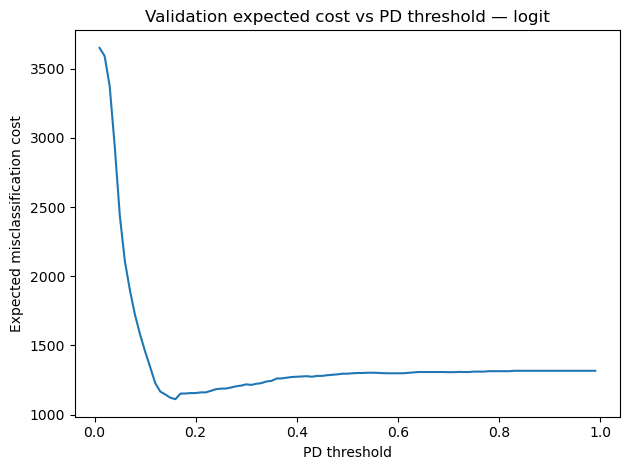

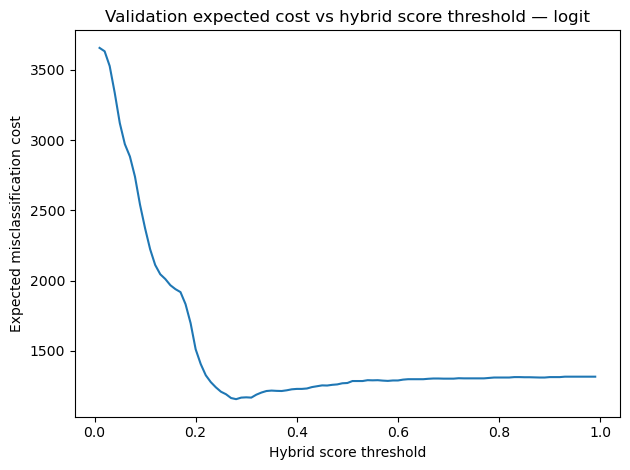

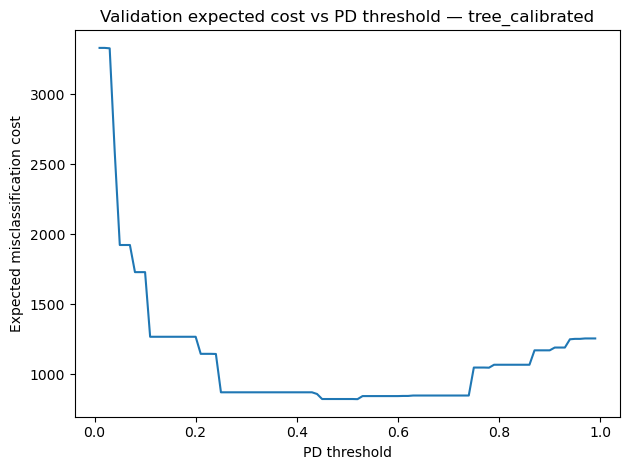

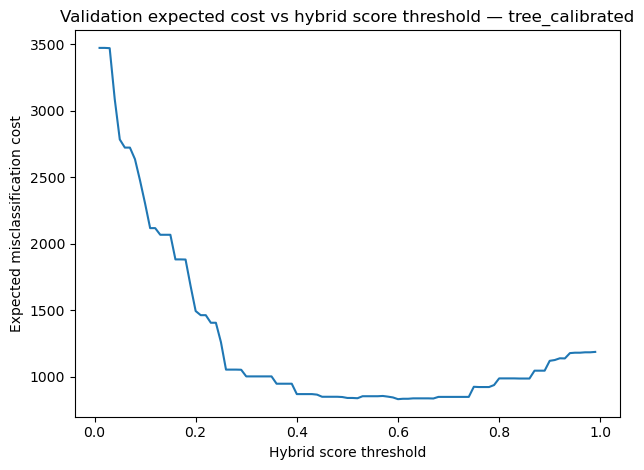

,thr_cost_opt,thr_capacity,thr_monitor,thr_cost_opt_hybrid,thr_capacity_hybrid,thr_monitor_hybrid
logit,0.16,0.110185,0.110185,0.28,0.205734,0.205734
tree_calibrated,0.52,0.241486,0.241486,0.60,0.391486,0.391486



Policy comparison on TEST (screen decision):


,policy_regime,model,policy,screen_rate,monitor_rate,tpr_screen,ppv_screen,tp_screen,fp_screen,expected_cost,thr_screen_pd,thr_monitor_pd,thr_screen_score,thr_monitor_score,alpha_evt_any,beta_evt_2plus,share_screen_pd_only,share_screen_both,share_screen_evt_override
1,capacity_controlled,logit,Hybrid (PD + events),0.206721,0.000000,0.472492,0.175798,292,1369,2347.0,NaN,NaN,0.205734,0.205734,0.05,0.1,0.221655,0.091350,0.115370
0,capacity_controlled,logit,PD-only,0.221655,0.000000,0.496764,0.172375,307,1474,2407.0,0.110185,0.110185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,capacity_controlled,tree_calibrated,Hybrid (PD + events),0.214437,0.000000,0.779935,0.279745,482,1241,1649.0,NaN,NaN,0.391486,0.391486,0.05,0.1,0.306036,0.214437,0.000000
4,capacity_controlled,tree_calibrated,PD-only,0.306036,0.000000,0.867314,0.217975,536,1923,2169.0,0.241486,0.241486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cost_optimal,logit,Hybrid (PD + events),0.053516,0.153205,0.236246,0.339535,146,284,1700.0,NaN,NaN,0.280000,0.205734,0.05,0.1,0.067828,0.036465,0.017050
2,cost_optimal,logit,PD-only,0.067828,0.153827,0.275081,0.311927,170,375,1719.0,0.160000,0.110185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,cost_optimal,tree_calibrated,Hybrid (PD + events),0.100560,0.113877,0.555016,0.424505,343,465,1290.0,NaN,NaN,0.600000,0.391486,0.05,0.1,0.115868,0.097573,0.002987
6,cost_optimal,tree_calibrated,PD-only,0.115868,0.190168,0.597087,0.396348,369,562,1309.0,0.520000,0.241486,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
COST_FN = float(CONFIG["COST_FN"])
COST_FP = float(CONFIG["COST_FP"])
CAPACITY_PCT = float(CONFIG["CAPACITY_PCT"])
MONITOR_PCT = float(CONFIG.get("MONITOR_PCT", min(0.20, 2*CAPACITY_PCT)))  # fallback: monitor top 20% or 2x capacity

ALPHA_EVT = 0.05
BETA_EVT = 0.10


def expected_cost(y_true: np.ndarray, y_hat: np.ndarray) -> float:
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    return COST_FN*fn + COST_FP*fp


def confusion_counts(y_true: np.ndarray, y_hat: np.ndarray) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    return {"tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn)}


def apply_pd_only_policy(p: np.ndarray, thr_screen: float, thr_monitor: float) -> dict:
    screen = (p >= thr_screen).astype(int)
    monitor = ((p >= thr_monitor) & (p < thr_screen)).astype(int)
    return {"screen": screen, "monitor": monitor}


def hybrid_score(p: np.ndarray, evt_count: np.ndarray, alpha: float = ALPHA_EVT, beta: float = BETA_EVT) -> np.ndarray:
    evt_any = (evt_count > 0).astype(int)
    return p + alpha*evt_any + beta*(evt_count >= 2).astype(int)


def apply_hybrid_policy_from_score(score: np.ndarray, thr_screen: float, thr_monitor: float) -> dict:
    screen = (score >= thr_screen).astype(int)
    monitor = ((score >= thr_monitor) & (score < thr_screen)).astype(int)
    return {"screen": screen, "monitor": monitor}


def build_evt_count(df_in: pd.DataFrame, evt_cols: list[str]) -> np.ndarray:
    evt_mat = df_in[evt_cols].apply(pd.to_numeric, errors="coerce")
    return (evt_mat.fillna(0) == 1).sum(axis=1).values

# --- Threshold selection (validation only) for PD-only and hybrid policies ---
grid = np.linspace(0.01, 0.99, 99)
mask_val = df_model["split"] == "val"
y_val = df_model.loc[mask_val, TARGET_NAME].astype(int).values
evt_count_val = build_evt_count(df_model.loc[mask_val, :], EVT_COLS)

thr_tbls = {}
for model_name, pcol in [("logit","pd_logit"), ("tree_calibrated","pd_tree")]:
    p_val = df_model.loc[mask_val, pcol].values

    # Cost-optimal PD-only threshold
    costs = [expected_cost(y_val, (p_val >= thr).astype(int)) for thr in grid]
    thr_cost_opt = float(grid[int(np.argmin(costs))])

    # Capacity and monitoring thresholds (operational)
    thr_capacity = float(np.quantile(p_val, 1-CAPACITY_PCT))
    thr_monitor = float(np.quantile(p_val, 1-MONITOR_PCT))

    # Hybrid score thresholds
    score_val = hybrid_score(p_val, evt_count_val)
    hybrid_costs = [expected_cost(y_val, (score_val >= thr).astype(int)) for thr in grid]
    thr_cost_opt_hybrid = float(grid[int(np.argmin(hybrid_costs))])
    thr_capacity_hybrid = float(np.quantile(score_val, 1-CAPACITY_PCT))
    thr_monitor_hybrid = float(np.quantile(score_val, 1-MONITOR_PCT))

    thr_tbls[model_name] = {
        "thr_cost_opt": thr_cost_opt,
        "thr_capacity": thr_capacity,
        "thr_monitor": thr_monitor,
        "thr_cost_opt_hybrid": thr_cost_opt_hybrid,
        "thr_capacity_hybrid": thr_capacity_hybrid,
        "thr_monitor_hybrid": thr_monitor_hybrid,
    }

    plt.figure()
    plt.plot(grid, costs)
    plt.title(f"Validation expected cost vs PD threshold — {model_name}")
    plt.xlabel("PD threshold")
    plt.ylabel("Expected misclassification cost")
    plt.tight_layout()
    plt.savefig(Path(CONFIG["FIG_DIR"]) / f"cost_curve_{model_name}_val.png", dpi=160)
    plt.show()

    plt.figure()
    plt.plot(grid, hybrid_costs)
    plt.title(f"Validation expected cost vs hybrid score threshold — {model_name}")
    plt.xlabel("Hybrid score threshold")
    plt.ylabel("Expected misclassification cost")
    plt.tight_layout()
    plt.savefig(Path(CONFIG["FIG_DIR"]) / f"cost_curve_hybrid_{model_name}_val.png", dpi=160)
    plt.show()

display(pd.DataFrame(thr_tbls).T)

# --- Policy comparison on TEST: capacity-controlled vs cost-optimal regimes ---
mask_test = df_model["split"] == "test"
y_test = df_model.loc[mask_test, TARGET_NAME].astype(int).values
evt_count_test = build_evt_count(df_model.loc[mask_test, :], EVT_COLS)

rows = []
for model_name, pcol in [("logit","pd_logit"), ("tree_calibrated","pd_tree")]:
    p_test = df_model.loc[mask_test, pcol].values
    score_test = hybrid_score(p_test, evt_count_test)

    for regime in ["capacity_controlled", "cost_optimal"]:
        if regime == "capacity_controlled":
            thr_screen = thr_tbls[model_name]["thr_capacity"]
            thr_monitor = thr_tbls[model_name]["thr_monitor"]
            thr_screen_hybrid = thr_tbls[model_name]["thr_capacity_hybrid"]
            thr_monitor_hybrid = thr_tbls[model_name]["thr_monitor_hybrid"]
        else:
            thr_screen = thr_tbls[model_name]["thr_cost_opt"]
            thr_monitor = thr_tbls[model_name]["thr_monitor"]
            thr_screen_hybrid = thr_tbls[model_name]["thr_cost_opt_hybrid"]
            thr_monitor_hybrid = thr_tbls[model_name]["thr_monitor_hybrid"]

        # PD-only (screen decision)
        polA = apply_pd_only_policy(p_test, thr_screen, thr_monitor)
        costA = expected_cost(y_test, polA["screen"])
        capA = float(polA["screen"].mean())
        tprA = float(((polA["screen"]==1) & (y_test==1)).sum() / max(1, (y_test==1).sum()))
        ppvA = float(((polA["screen"]==1) & (y_test==1)).sum() / max(1, (polA["screen"]==1).sum()))
        countsA = confusion_counts(y_test, polA["screen"])

        rows.append({
            "policy_regime": regime,
            "model": model_name,
            "policy": "PD-only",
            "screen_rate": capA,
            "monitor_rate": float(polA["monitor"].mean()),
            "tpr_screen": tprA,
            "ppv_screen": ppvA,
            "tp_screen": countsA["tp"],
            "fp_screen": countsA["fp"],
            "expected_cost": costA,
            "thr_screen_pd": thr_screen,
            "thr_monitor_pd": thr_monitor,
        })

        # Hybrid (screen decision derived from composite score)
        polB = apply_hybrid_policy_from_score(score_test, thr_screen_hybrid, thr_monitor_hybrid)
        costB = expected_cost(y_test, polB["screen"])
        capB = float(polB["screen"].mean())
        tprB = float(((polB["screen"]==1) & (y_test==1)).sum() / max(1, (y_test==1).sum()))
        ppvB = float(((polB["screen"]==1) & (y_test==1)).sum() / max(1, (polB["screen"]==1).sum()))
        countsB = confusion_counts(y_test, polB["screen"])

        overlap_both = float(((polA["screen"]==1) & (polB["screen"]==1)).mean())
        overlap_pd_only = float((polA["screen"]==1).mean())
        overlap_evt_override = float(((polB["screen"]==1) & (polA["screen"]==0)).mean())

        rows.append({
            "policy_regime": regime,
            "model": model_name,
            "policy": "Hybrid (PD + events)",
            "screen_rate": capB,
            "monitor_rate": float(polB["monitor"].mean()),
            "tpr_screen": tprB,
            "ppv_screen": ppvB,
            "tp_screen": countsB["tp"],
            "fp_screen": countsB["fp"],
            "expected_cost": costB,
            "thr_screen_score": thr_screen_hybrid,
            "thr_monitor_score": thr_monitor_hybrid,
            "alpha_evt_any": ALPHA_EVT,
            "beta_evt_2plus": BETA_EVT,
            "share_screen_pd_only": overlap_pd_only,
            "share_screen_both": overlap_both,
            "share_screen_evt_override": overlap_evt_override,
        })

policy_cmp = pd.DataFrame(rows).sort_values(["policy_regime", "model", "policy"])
print("\nPolicy comparison on TEST (screen decision):")
display(policy_cmp)

### 9.4.1 Decision curve analysis (net benefit)

Decision curves provide an alternative view of “response capability”: the net benefit of acting at different PD thresholds (treat-all vs treat-none baselines).

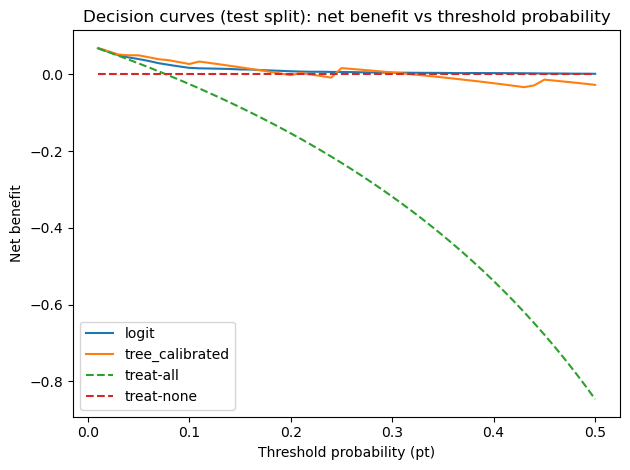

In [59]:
def net_benefit(y_true: np.ndarray, p: np.ndarray, pt: float) -> float:
    y_hat = (p >= pt).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    n = len(y_true)
    w = pt/(1-pt)
    return (tp/n) - (fp/n)*w

mask = df_model["split"]=="test"
y_test_np = df_model.loc[mask, TARGET_NAME].astype(int).values

pts = np.linspace(0.01, 0.50, 50)
plt.figure()
for model_name, pcol in [("logit","pd_logit"), ("tree_calibrated","pd_tree")]:
    p = df_model.loc[mask, pcol].values
    nb = [net_benefit(y_test_np, p, pt) for pt in pts]
    plt.plot(pts, nb, label=model_name)

# Treat-all and treat-none baselines
event_rate = y_test_np.mean()
nb_all = [event_rate - (1-event_rate)*(pt/(1-pt)) for pt in pts]
nb_none = [0 for _ in pts]
plt.plot(pts, nb_all, linestyle="--", label="treat-all")
plt.plot(pts, nb_none, linestyle="--", label="treat-none")

plt.title("Decision curves (test split): net benefit vs threshold probability")
plt.xlabel("Threshold probability (pt)")
plt.ylabel("Net benefit")
plt.legend()
plt.tight_layout()
plt.savefig(Path(CONFIG["FIG_DIR"]) / "decision_curves_test.png", dpi=160)
plt.show()

### 9.6 Audit / Assertions

In [60]:
# Final audit checks to surface defects early

# 1) Decile collapse check (tree calibrated PD)
try:
    dt_tree = decile_table(df_model.loc[df_model["split"]=="test", :], "pd_tree", TARGET_NAME)
    n_deciles = int(dt_tree["decile"].nunique()) if not dt_tree.empty else 0
    assert n_deciles == 10, f"Decile collapse detected: {n_deciles} bins"
except Exception as e:
    warnings.warn(f"Audit: decile collapse check failed: {e}")

# 2) Granularity check (unique values and mass-point)
try:
    gran_tbl = pd_granularity_tbl.copy() if 'pd_granularity_tbl' in globals() else pd.DataFrame()
    if not gran_tbl.empty:
        tree_row = gran_tbl.loc[gran_tbl["series"]=="tree_calibrated"].iloc[0]
        min_unique = max(50, int(0.02 * len(df_model.loc[df_model["split"]=="test", :])))
        assert tree_row["n_unique"] >= min_unique, f"Low unique PDs: {tree_row['n_unique']} < {min_unique}"
        assert tree_row["top_value_share"] <= 0.20, f"Mass point too large: {tree_row['top_value_share']:.2%}"
except Exception as e:
    warnings.warn(f"Audit: granularity check failed: {e}")

# 3) Policy table regime labels
try:
    assert "policy_regime" in policy_cmp.columns, "policy_regime missing"
    assert policy_cmp["policy_regime"].notna().all(), "policy_regime has missing values"
except Exception as e:
    warnings.warn(f"Audit: policy regime labeling failed: {e}")




## 10. Results Summary & Interpretation Guardrails


### 10.7 Replication artifacts

The following tables/exports are written to `outputs/` for downstream paper workflow:
- `config_summary.json`
- `distress_rule.json`
- `event_dictionary.csv`
- `logit_inference_table.csv`
- `metrics_table.csv`
- `predictions.csv`

### 10.8 Export tables, thresholds, and predictions


In [ ]:
out_dir = Path(CONFIG["OUTPUT_DIR"])

# Config + distress rule
(out_dir / "config_summary.json").write_text(json.dumps(CONFIG, indent=2))
(out_dir / "distress_rule.json").write_text(json.dumps(DISTRESS_RULE, indent=2))

# Event dictionary
event_dict.to_csv(out_dir / "event_dictionary.csv", index=False)

# Logit inference table
infer_tbl.reset_index().to_csv(out_dir / "logit_inference_table.csv", index=False)

# Metrics table
metrics_tbl.to_csv(out_dir / "metrics_table.csv", index=False)

# Predictions export (replication-friendly)
export_cols = ["firm_id","gvkey","fyear","label_year","split","target_next_v1","target_next_v2","target_next_v3","pd_logit","pd_tree"]
export_cols = [c for c in export_cols if c in df_model.columns]
export_cols += [c for c in event_feats if c in df_model.columns]
pred_export = df_model[export_cols].copy()
pred_export.to_csv(out_dir / "predictions.csv", index=False)

print("Wrote artifacts to:", out_dir.resolve())
print_df(pred_export, n=10, name="predictions.csv preview")

### 10.4 Deployment and maintenance (future work)

This notebook produces a research-grade replication pipeline. For production use (not required for journal replication), a minimal MLOps extension would include:
- scheduled re-scoring and monitoring for drift in feature distributions and target prevalence,
- retraining triggers and versioned model registry,
- data validation contracts (schema + unit tests) for the upstream Compustat extraction process.

## 11. Feature set coverage summary (v1/v2/v3)

This table mirrors Section 4.1 but summarizes **all unique features** used across v1/v2/v3 and tags each feature with the distress proxy version(s) where it appears.


In [61]:
feature_versions = {
    "v1": set(FEATURES_V1),
    "v2": set(FEATURES_V2),
    "v3": set(FEATURES_V3),
}

all_features = sorted(set().union(*feature_versions.values()))
feature_proxy = {
    feat: ",".join([v for v, feats in feature_versions.items() if feat in feats])
    for feat in all_features
}

feature_cols = [c for c in all_features if c in df.columns]
feature_desc = split_describe(df, feature_cols)
feature_desc.insert(2, "proxy_versions", feature_desc["col"].map(feature_proxy))
display(feature_desc.head(30))


,split,col,proxy_versions,count,mean,std,min,1%,10%,50%,90%,99%,max
0,train,cash_at,"v1,v2,v3",48458.0,17.196765,92.486283,0.000000e+00,0.000000,0.000809,0.102437,0.956005,555.502840,9.991143e+02
1,train,ceq_at,"v1,v3",48458.0,-8.914257,858.628815,-1.088745e+05,-506.545930,-0.339832,0.368430,0.949598,829.289719,4.761003e+03
2,train,current_ratio,"v1,v2,v3",48458.0,242.443404,2135.568444,1.866020e-06,0.000322,0.062464,1.688464,16.127039,5154.971307,1.611936e+05
3,train,debt_at,"v1,v2",48458.0,31.565163,364.644195,0.000000e+00,0.000000,0.000000,0.162621,1.280237,604.962901,2.618967e+04
4,train,debt_to_ebitda,"v1,v2",48391.0,1468.953682,242043.213125,-2.675132e+06,-1162.997410,-1.652120,0.203440,10.289390,5730.799978,5.196675e+07
5,train,dlc_at,v1,48458.0,15.909202,318.303794,0.000000e+00,0.000000,0.000000,0.007154,0.415101,200.541984,2.618487e+04
6,train,dltt_at,v1,48458.0,15.655961,157.801026,0.000000e+00,0.000000,0.000000,0.059018,0.633858,457.659196,2.382368e+04
7,train,ebit_to_capital,"v1,v2,v3",48422.0,25.639396,3501.188099,-3.074242e+04,-107.318583,-0.653844,0.050541,0.384737,54.504589,6.011667e+05
8,train,ebitda_at,"v1,v2",48458.0,-30.657234,985.765667,-1.691785e+05,-612.486157,-1.079692,0.020815,0.204010,144.130585,7.421013e+03
9,train,fcf_to_debt,v2,39624.0,-172.438671,25139.980921,-1.656200e+06,-2299.723322,-4.397147,0.040213,1.438076,761.111032,2.357800e+06
